# Bloque II — Intervenciones territoriales de la política de integración sociourbana

**Análisis de obras y del programa Mi Pieza a partir de bases abiertas oficiales**

Tesis doctoral — Impacto territorial de las políticas de integración socio-urbana (Ley N° 27.453) en barrios populares del NOA
CONICET – FAU UNT

---

### Alcance

Este cuaderno analiza **qué se ejecutó, con qué línea programática, con qué fuente de financiamiento y dónde**, en dos escalas:

1. **Escala nacional** — universo completo de obras y de Mi Pieza.
2. **Escala metropolitana (AMT)** — recorte sobre los barrios del Área Metropolitana de Tucumán ya validados espacialmente en QGIS 3.34.

### Fuentes (todas del repositorio `Camilamop/RENABAP`, rama `master`)

| Archivo | Fuente | Unidad de análisis |
|---|---|---|
| `Datos-abiertos-FISU.csv` | datos.gob.ar | proyecto de obra (financiamiento FISU) |
| `Datos-abiertos-BID.csv` | datos.gob.ar | proyecto de obra (financiamiento BID) |
| `Datos-abiertos-FF.csv` | datos.gob.ar | proyecto de obra (fondos federales) |
| `Obras_monitor_datastudio.csv` | Monitor de obras (DataStudio) | obra agregada por barrio |
| `mi-pieza_datos_gob_ar.csv` | datos.gob.ar | adjudicación individual (microdato) |
| `Obras_mipieza_datastudio.csv` | Monitor Mi Pieza (DataStudio) | barrio (agregado) |
| `RENABAP_AMT_2018/2022/2023.csv` | RENABAP + selección espacial QGIS | barrio popular del AMT |

### Advertencia metodológica

Las dos familias de fuentes **no son sustituibles ni sumables**: datos.gob.ar publica el *proyecto contratado* (con monto de contrato y tipo de proyecto codificado), mientras que el Monitor publica la *obra en ejecución agregada por barrio* (con inversión, familias beneficiarias y avance). Se usan de forma **complementaria y comparada**, nunca concatenada. Lo mismo aplica a las dos fuentes de Mi Pieza (microdato vs. agregado barrial).

---
## 0. Configuración

In [467]:
# Ejecutar en Google Colab. Sin dependencias externas más allá del stack estándar.
import pandas as pd
import numpy as np
import re, unicodedata, warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

# Paleta sobria para gráficos de tesis
PAL = ["#2F4B7C", "#A05195", "#D45087", "#F95D6A", "#FF7C43", "#FFA600", "#665191", "#003F5C"]

# ---------------------------------------------------------------
# Formato numérico argentino: miles con punto, decimales con coma
#   1.234.567  |  3,14  |  45,3 %
# Se aplica a: tablas que se muestran, textos (print), ejes de gráficos.
# NO se aplica a los CSV exportados: ahí los números siguen siendo números.
# ---------------------------------------------------------------
from numbers import Number
from matplotlib.ticker import FuncFormatter, ScalarFormatter

pd.set_option("styler.format.thousands", ".")
pd.set_option("styler.format.decimal", ",")


def fmt_ar(x, dec=0):
    '''1234567.891 -> "1.234.567" (dec=0) | "1.234.567,89" (dec=2). Vacío -> "NaN".'''
    try:
        if pd.isna(x):
            return "NaN"
    except (TypeError, ValueError):
        return str(x)
    s = f"{x:,.{dec}f}"
    return s.replace(",", "\x00").replace(".", ",").replace("\x00", ".")


pd.set_option("display.float_format", lambda x: fmt_ar(x, 2))

# Columnas que NO llevan separador de miles: años e identificadores
# (2023 no debe leerse "2.023", ni el id 1154 como "1.154").
_SIN_MILES = re.compile(r"(^|[_ ])(anio|año|year|decada|década)([_ ]|$)"
                        r"|^(id|id_renabap|id_barrio|.*_id)$", re.I)


def _es_numero(x):
    return isinstance(x, (Number, np.number)) and not isinstance(x, (bool, np.bool_))


def _decimales(valores):
    '''Cantidad de decimales que necesita una columna: 0, 1 o 2.'''
    v = pd.to_numeric(pd.Series(list(valores)), errors="coerce").astype(float)
    v = v[np.isfinite(v)]
    if v.empty:
        return 0
    for d in (0, 1):
        if np.allclose(v, v.round(d), rtol=0, atol=1e-9):
            return d
    return 2


def _formateador(valores, nombre=None, dec=None):
    '''Devuelve una función que formatea cada celda de una columna.'''
    valores = list(valores)
    nums = [x for x in valores if _es_numero(x)]
    sin_miles = bool(_SIN_MILES.search(str(nombre))) if nombre is not None else False
    if dec is None:
        dec = _decimales(nums) if nums else 0

    def f(x):
        if isinstance(x, pd.Timestamp):
            return x.strftime("%Y-%m-%d") if x == x.normalize() else str(x)
        if not _es_numero(x):
            return x if isinstance(x, str) else str(x)
        if pd.isna(x):
            return "NaN"
        if sin_miles:
            return str(int(x)) if float(x).is_integer() else str(x)
        if dec == 2 and float(x).is_integer():
            return fmt_ar(x, 0)   # conteos en columnas mixtas ("valor"): 214, no 214,00
        return fmt_ar(x, dec)
    return f


def _decimales_tabla(df):
    '''Decimales por columna. Una columna decimal sin fracciones (ej. 70 %) toma
    1 decimal si otra columna de la tabla usa 1 (ej. 71,7 %), para que no
    convivan "70" y "71,7" en la misma tabla.'''
    decs = {}
    for j in range(df.shape[1]):
        col = df.iloc[:, j]
        nums = [x for x in col if _es_numero(x)]
        decs[j] = _decimales(nums) if nums else 0
    con_uno = any(d == 1 for d in decs.values())
    for j in range(df.shape[1]):
        if con_uno and decs[j] == 0 and pd.api.types.is_float_dtype(df.iloc[:, j]):
            decs[j] = 1
    return decs


def _df_ar(df):
    '''Copia del DataFrame con todas las celdas ya convertidas a texto con formato AR.'''
    out = pd.DataFrame(index=df.index)
    decs = _decimales_tabla(df)
    for j in range(df.shape[1]):
        col = df.iloc[:, j]
        out[j] = col.map(_formateador(col, df.columns[j], decs[j])).values
    out.columns = df.columns
    idx = df.index
    if idx.nlevels == 1 and idx.name is not None and pd.api.types.is_numeric_dtype(idx):
        out.index = pd.Index(idx.map(_formateador(idx, idx.name)), name=idx.name)
    return out


def texto_ar(obj, pie=False, **kw):
    '''Versión en texto con formato AR (reemplaza a print(df) y a df.to_string()).'''
    if isinstance(obj, pd.DataFrame):
        return _df_ar(obj).to_string(**kw)
    if isinstance(obj, pd.Series):
        s = _df_ar(obj.to_frame()).iloc[:, 0]
        txt = s.to_string(**kw)
        if pie:
            nombre = f"Name: {obj.name}, " if obj.name is not None else ""
            txt += f"\n{nombre}dtype: {obj.dtype}"
        return txt
    if isinstance(obj, tuple) and all(_es_numero(v) for v in obj):
        return "(" + ", ".join(fmt_ar(v) for v in obj) + ")"
    if _es_numero(obj):
        return fmt_ar(obj, _decimales([obj]))
    return str(obj)


# df.ar.to_string(...) / serie.ar.to_string(...) = to_string con formato AR
@pd.api.extensions.register_dataframe_accessor("ar")
@pd.api.extensions.register_series_accessor("ar")
class _AccesorAR:
    def __init__(self, obj):
        self._obj = obj

    def to_string(self, **kw):
        return texto_ar(self._obj, **kw)


def _html_ar(df):
    '''Cómo se muestran los DataFrame en el notebook (display o última línea de la celda).'''
    try:
        max_f = pd.get_option("display.max_rows") or len(df)
        min_f = pd.get_option("display.min_rows") or 10
        max_c = pd.get_option("display.max_columns") or df.shape[1]
        vista, recortada = df, False
        if len(df) > max_f:
            vista = pd.concat([df.head(min_f // 2), df.tail(min_f // 2)])
            recortada = True
        if df.shape[1] > max_c:
            vista = pd.concat([vista.iloc[:, :max_c // 2], vista.iloc[:, -(max_c // 2):]], axis=1)
            recortada = True
        sty = vista.style
        decs = _decimales_tabla(vista)
        for j, c in enumerate(vista.columns):
            sty = sty.format(_formateador(vista.iloc[:, j], c, decs[j]), subset=[c], escape="html")
        idx = vista.index
        if idx.nlevels == 1 and idx.name is not None and pd.api.types.is_numeric_dtype(idx):
            sty = sty.format_index(_formateador(idx, idx.name), axis=0)
        else:
            sty = sty.format_index(escape="html", axis=0)   # "<" en un patrón no es HTML
        sty = sty.format_index(escape="html", axis=1)
        sty = sty.set_table_attributes('class="dataframe"')
        html = sty.to_html()
        if recortada:
            html += (f"<p>Se muestran {fmt_ar(len(vista))} de {fmt_ar(len(df))} filas "
                     f"× {fmt_ar(df.shape[1])} columnas</p>")
        return html
    except Exception:
        return df._repr_html_()   # ante cualquier problema, pandas lo muestra como siempre


try:
    _fmt = get_ipython().display_formatter.formatters
    _fmt["text/html"].for_type(pd.DataFrame, _html_ar)
    _fmt["text/plain"].for_type(pd.Series, lambda s, p, cycle: p.text(texto_ar(s, pie=True)))
except NameError:
    pass   # fuera de un notebook no hay nada que registrar


# --- Gráficos: ejes numéricos con formato AR -----------------------------
def _tick_ar(v, pos=None):
    if v == 0:
        return "0"
    s = fmt_ar(v, 2)
    return s.rstrip("0").rstrip(",") if "," in s else s

EJE_AR = FuncFormatter(_tick_ar)


def formato_ejes_ar(fig=None):
    '''Aplica el formato AR a los ejes numéricos de la figura (no toca categorías ni fechas).'''
    fig = fig or plt.gcf()
    for ax in fig.axes:
        for eje in (ax.xaxis, ax.yaxis):
            if type(eje.get_major_formatter()) is ScalarFormatter:
                eje.set_major_formatter(EJE_AR)


# plt.show aplica el formato antes de mostrar cada figura
if not hasattr(plt, "_show_original"):
    plt._show_original = plt.show

def _show_ar(*args, **kwargs):
    for n in plt.get_fignums():
        formato_ejes_ar(plt.figure(n))
    return plt._show_original(*args, **kwargs)

plt.show = _show_ar


In [468]:
# ---------------------------------------------------------------
# Rutas base al repositorio público (contenido crudo)
# ---------------------------------------------------------------
BASE = "https://raw.githubusercontent.com/Camilamop/RENABAP/master"
RAW  = f"{BASE}/data/raw"
PROC = f"{BASE}/data/processed/qgis"

FUENTES = {
    "obras_fisu":      f"{RAW}/Datos-abiertos-FISU.csv",
    "obras_bid":       f"{RAW}/Datos-abiertos-BID.csv",
    "obras_ff":        f"{RAW}/Datos-abiertos-FF.csv",
    "obras_monitor":   f"{RAW}/Obras_monitor_datastudio.csv",
    "mipieza_micro":   f"{RAW}/mi-pieza_datos_gob_ar.csv",
    "mipieza_monitor": f"{RAW}/Obras_mipieza_datastudio.csv",
    "amt_2018":        f"{PROC}/RENABAP_AMT_2018.csv",
    "amt_2022":        f"{PROC}/RENABAP_AMT_2022.csv",
    "amt_2023":        f"{PROC}/RENABAP_AMT_2023.csv",
}

# Corte de recorte metropolitano: qué relevamiento define el universo de barrios AMT.
# "union" = todos los barrios que aparecen en cualquiera de los tres cortes (recomendado
# para obras, porque una obra puede ejecutarse en un barrio dado de baja o reincorporado).
CORTE_AMT = "union"   # opciones: "union" | "2018" | "2022" | "2023"

EXPORTAR = True       # guarda tablas .csv y figuras .png en ./salidas/
import os
os.makedirs("salidas/tablas", exist_ok=True)
os.makedirs("salidas/figuras", exist_ok=True)

In [754]:
# ---------------------------------------------------------------
# Utilidades de lectura y normalización
# ---------------------------------------------------------------

def leer_csv(url, **kw):
    '''Lector tolerante a codificación: los archivos del portal alternan UTF-8 y Latin-1.'''
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(url, encoding=enc, **kw)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"No se pudo decodificar {url}")


def sin_tildes(s):
    if pd.isna(s):
        return s
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c))


def norm_texto(s):
    '''Minúsculas, sin tildes, sin dobles espacios. Para comparar strings entre fuentes.'''
    if pd.isna(s):
        return np.nan
    return re.sub(r"\s+", " ", sin_tildes(str(s)).lower()).strip()

# Nombres de barrio que contienen palabras de los patrones F3 y distorsionan la
# clasificación (detectados en la auditoría de la Inspección C). Se borran del
# texto ANTES de buscar patrones: el nombre original de la obra no se modifica.
# Para agregar otro, sumarlo a la lista tal como aparece en la base.
BARRIOS_EXCLUIDOS = [
    "Obras Sanitarias",
    "Parque Las Rosas",
    "El Basural",
    "Toma Canal",
]

def norm_patron(s):
    '''norm_texto + guiones normalizados. EXCLUSIVA para el matching de patrones F3.
    Colapsa " - " y " -" a "-" para que "intra - lote", "intra-lote" e "intralote"
    se traten como la misma expresión. Además borra los BARRIOS_EXCLUIDOS, para
    que el nombre de un barrio no active un patrón. No se usa para cruzar strings
    entre fuentes: para eso sigue valiendo norm_texto.'''
    if pd.isna(s):
        return np.nan
    s = norm_texto(s)
    for barrio in BARRIOS_EXCLUIDOS:
        s = re.sub(rf"\b{re.escape(norm_texto(barrio))}\b", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return re.sub(r"\s*-\s*", "-", s)

def a_numero(x):
    ''' '153,571,116.49' -> 153571116.49 ; '97.78%' -> 97.78 ; vacío -> NaN'''
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace("%", "").replace("$", "").replace(" ", "")
    s = s.replace(",", "")
    try:
        return float(s)
    except ValueError:
        return np.nan


def a_fecha(x):
    '''Convive 'dd/mm/aaaa' con 'aaaa-mm-dd'.'''
    if pd.isna(x) or str(x).strip() == "":
        return pd.NaT
    s = str(x).strip()
    fmt = "%Y-%m-%d" if re.match(r"^\d{4}-", s) else "%d/%m/%Y"
    return pd.to_datetime(s, format=fmt, errors="coerce")


def ids_renabap(x):
    ''' '2760/2762' -> ['2760','2762'] ; '1154*' -> ['1154'] ; 'Varios'/'-' -> [] '''
    if pd.isna(x):
        return []
    s = str(x).strip()
    if norm_texto(s) in {"varios", "s/d", "sin dato", "-", "", "nan"}:
        return []
    partes = [p.strip().rstrip("*").strip() for p in re.split(r"[\/;,]", s)]
    return [p for p in partes if p.isdigit()]


def id_provisorio(x):
    '''El asterisco en el identificador marca barrios con registro no vigente
    (dados de baja, fusionados o en revisión). Se conserva como atributo.'''
    return bool(pd.notna(x) and "*" in str(x))


def sin_identificador(x):
    '''Distingue el vacío real del vacío declarado ("-", "Varios").'''
    if pd.isna(x):
        return True
    return norm_texto(str(x)) in {"varios", "s/d", "sin dato", "-", "", "nan"}


def guardar_tabla(df, nombre):
    if EXPORTAR:
        df.to_csv(f"salidas/tablas/{nombre}.csv", index=True, encoding="utf-8-sig")


def guardar_fig(nombre):
    formato_ejes_ar(plt.gcf())   # ejes con formato AR también en el .png
    if EXPORTAR:
        plt.savefig(f"salidas/figuras/{nombre}.png", bbox_inches="tight", dpi=200)

---
## 1. Carga de las fuentes

Se cargan primero las tres bases de obras de datos.gob.ar (que comparten esquema) y luego las fuentes del Monitor y de Mi Pieza.

In [755]:
# --- 1.1 Obras según datos.gob.ar, por fuente de financiamiento -------------
obras_partes = []
for clave, etiqueta in [("obras_fisu", "FISU"), ("obras_bid", "BID"), ("obras_ff", "FF")]:
    d = leer_csv(FUENTES[clave])
    d["archivo_origen"] = etiqueta
    obras_partes.append(d)

obras = pd.concat(obras_partes, ignore_index=True)
print("Obras datos.gob.ar:", texto_ar(obras.shape))
print("\nEsquema:")
print(obras.dtypes)
obras.head(3)

Obras datos.gob.ar: (1.315, 14)

Esquema:
ID RENABAP             object
Provincia              object
Municipio              object
Barrio                 object
Localidad              object
Tipo de UE             object
Tipo de Proyecto       object
Nombre de Proyecto     object
Financiamiento         object
Estado                 object
Monto Total            object
Acta de Inicio Real    object
% Avance físico        object
archivo_origen         object
dtype: object


,ID RENABAP,Provincia,Municipio,Barrio,Localidad,Tipo de UE,Tipo de Proyecto,Nombre de Proyecto,Financiamiento,Estado,Monto Total,Acta de Inicio Real,% Avance físico,archivo_origen
0,4637,Ciudad Autónoma de Buenos Aires,Ciudad Autónoma de Buenos Aires,Barrio Padre Mugica,Ciudad Autónoma de Buenos Aires,OSC,POT,Equipamientos educativo - mejoramiento de jardin,FISU,En ejecución,"269,219,376.83",2024-04-15,40.25%,FISU
1,68,Buenos Aires,La Plata,Sin Nombre (esos locos bajitos),Gonnet,OSC,POT,Equipamientos Comunitario y Espacio Recreativo,FISU,En ejecución,"186,308,259.30",2023-12-01,25.97%,FISU
2,194,Buenos Aires,La Plata,Ruta del Sol,El Peligro,OSC,POT,Equipamiento Productivo,FISU,En ejecución,"181,540,041.99",2023-12-15,20.00%,FISU


In [756]:
# --- 1.2 Verificación de que las tres bases comparten esquema --------------
for d, e in zip(obras_partes, ["FISU", "BID", "FF"]):
    print(f"{e:6s} {fmt_ar(d.shape[0]):>5} filas | columnas: {list(d.columns)[:4]} ...")
esquemas = {tuple(d.columns) for d in obras_partes}
print("\n¿Esquema idéntico en las tres?", len(esquemas) == 1)

FISU   1.216 filas | columnas: ['ID RENABAP', 'Provincia', 'Municipio', 'Barrio'] ...
BID       50 filas | columnas: ['ID RENABAP', 'Provincia', 'Municipio', 'Barrio'] ...
FF        49 filas | columnas: ['ID RENABAP', 'Provincia', 'Municipio', 'Barrio'] ...

¿Esquema idéntico en las tres? True


In [757]:
# --- 1.3 Monitor de obras (DataStudio) -------------------------------------
monitor = leer_csv(FUENTES["obras_monitor"])
print("Monitor de obras:", texto_ar(monitor.shape))
monitor.head(3)

Monitor de obras: (1.322, 10)


,Provincia,Municipio,ID RENABAP,Barrio,Nombre de la obra,Unidad Ejecutora,Estado,Inversión total,Familias beneficiarias,Avance físico
0,Buenos Aires,Necochea,629,Barrio Los Malvones,"Veredas, Cordón cuneta, Pluviales, Alumbrado, Red de agua, Conexiones de agua, Red cloacal en Barrio Los Malvones",Municipio,Terminado,"104.732.597,30",96,1.00002
1,Buenos Aires,Tandil,4282/608,Movediza I y II,"Veredas, Conexiones eléctricas, Conexiones de agua, Conexiones a la cloaca en Movediza I y II",OSC,Terminado,"225.958.394,26",193,1
2,Chaco,Resistencia,2235,Los Aromitos,Centro comunitario en Los Aromitos,Provincia,Terminado,"23.652.933,37",30,1


In [758]:
# --- 1.4 Mi Pieza: microdato nacional (archivo pesado, ~58 MB) -------------
# Se restringe a las columnas efectivamente usadas para no saturar la memoria de Colab.
COLS_MP = ["id", "provincia", "provincia_id", "id_barrio", "cantidad_grupo_familiar",
           "cantidad_grupo_familiar_18", "validacion_discapacidad", "ambientes_vivienda",
           "ambientes_dormir", "piso_vivienda", "pared_vivienda", "techo_vivienda",
           "tipo_obra", "monto", "estado", "sorteo"]

mipieza = leer_csv(FUENTES["mipieza_micro"], usecols=COLS_MP,
                   dtype={"id_barrio": "string", "provincia": "string",
                          "tipo_obra": "string", "estado": "string"})
print("Mi Pieza (microdato):", texto_ar(mipieza.shape))
mipieza.head(3)

Mi Pieza (microdato): (489.429, 16)


,id,provincia,provincia_id,id_barrio,cantidad_grupo_familiar,cantidad_grupo_familiar_18,validacion_discapacidad,ambientes_vivienda,ambientes_dormir,piso_vivienda,pared_vivienda,techo_vivienda,tipo_obra,monto,estado,sorteo
0,1,Buenos Aires,6,462,3,1,no,3,2,Cemento alisado,Ladrillo,Chapa,"Mejoramiento de pared,Mejoramiento de piso",240.000,Activa,2
1,2,Buenos Aires,6,462,3,1,no,2,2,Cemento alisado,Madera,Chapa,Mejoramiento de aberturas,100.000,Activa,1
2,3,Buenos Aires,6,407,10,4,no,3,1,Cemento alisado,Ladrillo,Losa,"Mejoramiento de pared,Refacción menor de plomería y/o electricidad",240.000,Activa,2


In [759]:
# --- 1.5 Mi Pieza agregado por barrio (Monitor) ----------------------------
mipieza_mon = leer_csv(FUENTES["mipieza_monitor"])
print("Mi Pieza (monitor, agregado barrial):", texto_ar(mipieza_mon.shape))
mipieza_mon.head(3)

Mi Pieza (monitor, agregado barrial): (5.051, 9)


,Provincia,Municipio,ID RENABAP,Barrio,Obras no iniciadas,Obras en ejecución,Obras terminadas,Adjudicaciones rechazadas,Inversión total
0,Buenos Aires,Lomas de Zamora,25,Laberinto,0,1,6,2,2.740.000
1,Buenos Aires,La Plata,46,Sin Nombre,0,3,68,7,24.260.000
2,Buenos Aires,Esteban Echeverría,785,El Gauchito Gil,0,6,61,5,26.710.000


In [760]:
# --- 1.6 Barrios del AMT (subconjuntos validados en QGIS) ------------------
amt = {}
for anio, col_id in [("2018", "id_renabap"), ("2022", "ID Renabap"), ("2023", "id_renabap")]:
    d = leer_csv(FUENTES[f"amt_{anio}"], dtype=str)
    d = d.rename(columns={col_id: "id_renabap"})
    d["id_renabap"] = d["id_renabap"].astype(str).str.strip()
    amt[anio] = d
    print(f"AMT {anio}: {fmt_ar(d.shape[0])} barrios")

if CORTE_AMT == "union":
    IDS_AMT = set().union(*[set(d["id_renabap"]) for d in amt.values()])
else:
    IDS_AMT = set(amt[CORTE_AMT]["id_renabap"])

# Diccionario id_renabap -> nombre de barrio (prioridad: 2023 > 2022 > 2018)
NOMBRES_AMT = {}
for anio, col in [("2018", "Nombre del barrio"), ("2022", "Nombre del barrio"), ("2023", "nombre_barrio")]:
    NOMBRES_AMT.update(dict(zip(amt[anio]["id_renabap"], amt[anio][col])))

print(f"\nUniverso AMT ({CORTE_AMT}): {fmt_ar(len(IDS_AMT))} barrios (id_renabap)")

# ¿Qué barrios explican la diferencia entre la unión y cada corte?
for anio in ("2018", "2022", "2023"):
    fuera = IDS_AMT - set(amt[anio]["id_renabap"])
    print(f"  ausentes en {anio}: {fmt_ar(len(fuera))}")
solo_viejos = IDS_AMT - set(amt["2023"]["id_renabap"])
if solo_viejos:
    print(f"\nBarrios que estaban en 2018/2022 y NO figuran en 2023: {sorted(solo_viejos)}")
    for i in sorted(solo_viejos):
        nom = amt["2018"].loc[amt["2018"]["id_renabap"] == i, "Nombre del barrio"]
        print(f"  {i}: {nom.iloc[0] if len(nom) else 'sin nombre en 2018'}")
    print("  -> salida del registro (baja, fusión o revisión), no cierre del barrio.")
print(f"Nombres de barrio disponibles: {fmt_ar(len(NOMBRES_AMT))}")

AMT 2018: 144 barrios
AMT 2022: 170 barrios
AMT 2023: 213 barrios

Universo AMT (union): 214 barrios (id_renabap)
  ausentes en 2018: 70
  ausentes en 2022: 44
  ausentes en 2023: 1

Barrios que estaban en 2018/2022 y NO figuran en 2023: ['2756']
  2756: Barrio Santa Ana
  -> salida del registro (baja, fusión o revisión), no cierre del barrio.
Nombres de barrio disponibles: 214


---
## 2. Auditoría de calidad de los datos

Antes de cualquier cuantificación conviene dejar asentado el estado de las bases: es material de nota metodológica y también condiciona qué se puede afirmar.

Tres problemas ya identificados en la inspección previa:

1. **`ID RENABAP` compuesto.** Una parte de los proyectos declara varios barrios en un mismo campo (`"2760/2762"`, `"397/1174/1251/..."`) y algunos declaran `"Varios"` sin identificar barrio. Esto impide una asignación territorial unívoca y obliga a decidir un criterio de imputación.
2. **Montos como texto** con separador de miles y fechas en dos formatos distintos dentro de la misma columna.
3. **El identificador une barrios, no obras.** `id_renabap` es una clave sólida a nivel de barrio y así se usa en todo el cuaderno. Lo que no existe es una clave de *obra*: si un barrio tiene tres proyectos en datos.gob.ar y dos obras en el Monitor, nada permite saber qué proyecto corresponde a qué obra. Por eso las dos fuentes se cruzan a nivel barrio y se comparan, pero no se emparejan registro a registro.

4. **Identificadores con asterisco.** Algunos registros traen el id marcado (`1154*`, `2756*`). El asterisco señala barrios cuyo registro no está vigente —dados de baja, fusionados o en revisión—. Se limpia el asterisco para poder unir, y se conserva la marca en la columna `id_provisorio`.

In [761]:
def auditar(df, nombre):
    rep = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "%_nulos": (df.isna().mean() * 100).round(1),
        "únicos": df.nunique(dropna=True),
    })
    print(f"===== {nombre} — {fmt_ar(df.shape[0])} filas × {fmt_ar(df.shape[1])} columnas =====")
    return rep

auditar(obras, "Obras datos.gob.ar")

===== Obras datos.gob.ar — 1.315 filas × 14 columnas =====


,tipo,nulos,%_nulos,únicos
ID RENABAP,object,121,"9,2",964
Provincia,object,0,"0,0",31
Municipio,object,0,"0,0",245
Barrio,object,121,"9,2",868
Localidad,object,1,"0,1",425
Tipo de UE,object,0,"0,0",5
Tipo de Proyecto,object,0,"0,0",8
Nombre de Proyecto,object,0,"0,0",942
Financiamiento,object,0,"0,0",3
Estado,object,0,"0,0",4


In [762]:
auditar(monitor, "Monitor de obras")

===== Monitor de obras — 1.322 filas × 10 columnas =====


,tipo,nulos,%_nulos,únicos
Provincia,object,0,0,24
Municipio,object,0,0,238
ID RENABAP,object,0,0,963
Barrio,object,0,0,974
Nombre de la obra,object,0,0,1.267
Unidad Ejecutora,object,0,0,4
Estado,object,0,0,3
Inversión total,float64,0,0,1.320
Familias beneficiarias,object,0,0,418
Avance físico,object,0,0,618


In [763]:
# Diagnóstico específico del identificador territorial
# Nota: la auditoría anterior informa 0% de nulos porque el vacío está DECLARADO
# como texto ("-", "Varios"), no como celda vacía. Acá se separan los casos.

def diagnosticar_id(serie):
    txt = serie.astype(str).str.strip()
    return pd.Series({
        "registros": len(txt),
        "id_simple": txt.str.fullmatch(r"\d+").sum(),
        "id_con_asterisco": txt.str.fullmatch(r"\d+\*").sum(),
        "id_compuesto": txt.str.contains("/").sum(),
        "sin_identificador": serie.map(sin_identificador).sum(),
        "nulos_reales": serie.isna().sum(),
    })

diag = pd.DataFrame({
    "datos.gob.ar":     diagnosticar_id(obras["ID RENABAP"]),
    "Monitor obras":    diagnosticar_id(monitor["ID RENABAP"]),
    "Monitor Mi Pieza": diagnosticar_id(mipieza_mon["ID RENABAP"]),
}).T
diag["%_utilizable"] = ((diag["id_simple"] + diag["id_con_asterisco"] + diag["id_compuesto"])
                        / diag["registros"] * 100).round(1)
guardar_tabla(diag, "02_diagnostico_identificador")

print("Valores no numéricos encontrados en el Monitor de obras:")
print(monitor.loc[monitor["ID RENABAP"].map(sin_identificador), "ID RENABAP"]
      .value_counts().ar.to_string())
diag

Valores no numéricos encontrados en el Monitor de obras:
ID RENABAP
-         113
Varios      4


,registros,id_simple,id_con_asterisco,id_compuesto,sin_identificador,nulos_reales,%_utilizable
datos.gob.ar,1.315,984,0,203,124,121,"90,3"
Monitor obras,1.322,1.012,0,193,117,0,"91,1"
Monitor Mi Pieza,5.051,5.017,34,0,0,0,"100,0"


Los 117 registros del Monitor sin identificador no son celdas vacías: 113 traen un guion y 4 dicen "Varios". Por eso la auditoría de la celda anterior informa 0% de nulos y esta tabla informa 117 sin identificador. Son la misma realidad leída con dos criterios distintos, y conviene reportar el segundo: para el análisis territorial, un guion es tan inutilizable como un vacío.

### Criterio de imputación territorial adoptado

Para los proyectos con `ID RENABAP` compuesto se construyen **dos tablas paralelas**:

- **`obras`** — unidad de análisis = *proyecto*. Un proyecto multibarrial cuenta una vez. Se usa para todo lo que sea **conteo de intervenciones y montos** (no se duplica inversión).
- **`obras_barrio`** — unidad de análisis = *par proyecto–barrio* (`explode`). Se usa exclusivamente para **cobertura territorial**: qué barrios fueron alcanzados por alguna intervención. Los montos de esta tabla **no deben sumarse**, sólo contarse barrios.

Esta separación evita el error habitual de inflar la inversión al desagregar por barrio.

---
## 3. Armonización

In [764]:
# --- 3.1 Obras datos.gob.ar ------------------------------------------------
o = obras.copy()
o.columns = [c.strip() for c in o.columns]

o = o.rename(columns={
    "ID RENABAP": "id_renabap_raw",
    "Provincia": "provincia",
    "Municipio": "municipio",
    "Barrio": "barrio",
    "Localidad": "localidad",
    "Tipo de UE": "tipo_ue",
    "Tipo de Proyecto": "linea_programatica",
    "Nombre de Proyecto": "nombre_proyecto",
    "Financiamiento": "financiamiento",
    "Estado": "estado",
    "Monto Total": "monto_total",
    "Acta de Inicio Real": "acta_inicio",
    "% Avance físico": "avance_fisico",
})

o["monto_total"]   = o["monto_total"].map(a_numero)
o["avance_fisico"] = o["avance_fisico"].map(a_numero)       # en % (0–100)
o["acta_inicio"]   = o["acta_inicio"].map(a_fecha)
o["anio_inicio"]   = o["acta_inicio"].dt.year

for c in ["provincia", "municipio", "barrio", "localidad", "estado",
          "financiamiento", "linea_programatica", "tipo_ue"]:
    o[c] = o[c].astype(str).str.strip()
    o.loc[o[c].isin(["nan", ""]), c] = np.nan

# 'Estado' de BID trae un espacio inicial (' En ejecución'): se unifica
o["estado"] = o["estado"].str.strip().str.capitalize()

# Municipio con capitalización inconsistente ('San Miguel De/de Tucumán')
o["municipio_norm"] = o["municipio"].map(norm_texto)
o["provincia_norm"] = o["provincia"].map(norm_texto)

o["ids_renabap"]   = o["id_renabap_raw"].map(ids_renabap)
o["id_provisorio"] = o["id_renabap_raw"].map(id_provisorio)
o["n_barrios"]     = o["ids_renabap"].str.len()
o["multibarrial"] = o["n_barrios"] > 1
o["sin_id"]       = o["n_barrios"] == 0

o["proyecto_id"] = "P" + o.index.astype(str).str.zfill(5)

obras = o

obras_barrio = (obras
                .explode("ids_renabap")
                .rename(columns={"ids_renabap": "id_renabap"}))
obras_barrio = obras_barrio[obras_barrio["id_renabap"].notna()].copy()
obras_barrio["id_renabap"] = obras_barrio["id_renabap"].astype(str)

print(texto_ar(obras.shape), "| pares obra–barrio:", texto_ar(obras_barrio.shape))
obras[["proyecto_id", "provincia", "municipio", "linea_programatica",
       "financiamiento", "estado", "monto_total", "avance_fisico", "n_barrios"]].head()

(1.315, 23) | pares obra–barrio: (1.734, 23)


,proyecto_id,provincia,municipio,linea_programatica,financiamiento,estado,monto_total,avance_fisico,n_barrios
0,P00000,Ciudad Autónoma de Buenos Aires,Ciudad Autónoma de Buenos Aires,POT,FISU,En ejecución,"269.219.376,83","40,25",1
1,P00001,Buenos Aires,La Plata,POT,FISU,En ejecución,"186.308.259,30","25,97",1
2,P00002,Buenos Aires,La Plata,POT,FISU,En ejecución,"181.540.041,99",20,1
3,P00003,Buenos Aires,Lomas de Zamora,POT,FISU,En ejecución,"1.273.196.907,29","64,36",1
4,P00004,Buenos Aires,General San Martín,POT,FISU,En ejecución,"29.355.856,79",100,4


In [765]:
# --- 3.2 Tabla proyecto–barrio (sólo para cobertura territorial) ----------
obras_barrio = (obras
                .explode("ids_renabap")
                .rename(columns={"ids_renabap": "id_renabap"}))
obras_barrio = obras_barrio[obras_barrio["id_renabap"].notna()].copy()
obras_barrio["id_renabap"] = obras_barrio["id_renabap"].astype(str)

print(f"Pares proyecto–barrio: {fmt_ar(len(obras_barrio))}")
print(f"Barrios únicos alcanzados en el país: {fmt_ar(obras_barrio['id_renabap'].nunique())}")
print(f"Proyectos sin barrio identificable: {fmt_ar(obras['sin_id'].sum())}")

Pares proyecto–barrio: 1.734
Barrios únicos alcanzados en el país: 1.224
Proyectos sin barrio identificable: 128


In [766]:
# --- 3.3 Monitor de obras --------------------------------------------------
m = monitor.copy()
m.columns = [c.strip() for c in m.columns]
m = m.rename(columns={
    "Provincia": "provincia",
    "Municipio": "municipio",
    "ID RENABAP": "id_renabap_raw",
    "Barrio": "barrio",
    "Nombre de la obra": "nombre_obra",
    "Unidad Ejecutora": "tipo_ue",
    "Estado": "estado",
    "Inversión total": "inversion_total",
    "Familias beneficiarias": "familias",
    "Avance físico": "avance_fisico",
})
m["inversion_total"] = m["inversion_total"].map(a_numero)
m["familias"]        = m["familias"].map(a_numero)
m["avance_fisico"]   = m["avance_fisico"].map(a_numero) * 100   # viene en 0–1
m["avance_fisico"]   = m["avance_fisico"].clip(upper=100)
m["provincia_norm"]  = m["provincia"].map(norm_texto)
m["municipio_norm"]  = m["municipio"].map(norm_texto)
m["ids_renabap"]     = m["id_renabap_raw"].map(ids_renabap)
m["id_provisorio"]   = m["id_renabap_raw"].map(id_provisorio)
m["obra_id"]         = "M" + m.index.astype(str).str.zfill(5)
m["n_barrios"]       = m["ids_renabap"].str.len()


monitor = m

monitor_barrio = (monitor.explode("ids_renabap")
                         .rename(columns={"ids_renabap": "id_renabap"}))
monitor_barrio = monitor_barrio[monitor_barrio["id_renabap"].notna()].copy()

print("Monitor:", texto_ar(monitor.shape), "| pares obra–barrio:", texto_ar(monitor_barrio.shape))
monitor[["provincia", "municipio", "barrio", "estado", "inversion_total",
         "familias", "avance_fisico","n_barrios"]].head(3)

Monitor: (1.322, 16) | pares obra–barrio: (1.738, 16)


,provincia,municipio,barrio,estado,inversion_total,familias,avance_fisico,n_barrios
0,Buenos Aires,Necochea,Barrio Los Malvones,Terminado,"104.732.597,30",96,100,1
1,Buenos Aires,Tandil,Movediza I y II,Terminado,"225.958.394,26",193,100,2
2,Chaco,Resistencia,Los Aromitos,Terminado,"23.652.933,37",30,100,1


In [767]:
mp = mipieza.copy()
mp["monto"] = mp["monto"].map(a_numero) if mp["monto"].dtype == object else mp["monto"]
mp["id_barrio"] = mp["id_barrio"].astype(str).str.strip()
mp["provincia_norm"] = mp["provincia"].map(norm_texto)
# --- Estado: normalización y unidad de análisis --------------------------
# La base trae cuatro valores, dos de los cuales son la misma categoría escrita
# con distinta capitalización ("seleccionada" / "Seleccionada"). Se unifican.
MAPEO_ESTADO = {
    "activa":       "Activa",
    "seleccionada": "Seleccionada",
    "inscripta":    "Inscripta",
}
mp["estado_norm"] = mp["estado"].map(norm_texto).map(MAPEO_ESTADO)

# ADVERTENCIA SUSTANTIVA: "Inscripta" no es una adjudicación. Son solicitudes
# registradas que nunca entraron a sorteo (su campo `sorteo` está vacío en el
# 100% de los casos). Contarlas como intervención sobreestima gruesamente la
# cobertura del programa y su monto. Se define una unidad de análisis explícita.
mp["adjudicada"] = mp["estado_norm"] == "Activa"
mp_adj = mp[mp["adjudicada"]]

print("Estados declarados en la base:")
print(mp["estado"].value_counts(dropna=False).ar.to_string())
print("\nDespués de unificar:")
print(mp["estado_norm"].value_counts(dropna=False).ar.to_string())
print(f"\nAdjudicaciones efectivas (sólo Activa): {fmt_ar(mp['adjudicada'].sum())}")
print(f"Seleccionadas (con sorteo, sin activar): {fmt_ar((mp['estado_norm']=='Seleccionada').sum())}")
print(f"Inscriptas (nunca sortearon)           : {fmt_ar((mp['estado_norm']=='Inscripta').sum())}")
print(mp.groupby("estado_norm")["sorteo"].apply(lambda x: f"{fmt_ar(x.notna().mean()*100, 1)} % con sorteo").ar.to_string())

# tipo_obra es multivaluado en una sola celda, separado por comas
mp["tipo_obra_lista"] = (mp["tipo_obra"].fillna("")
                           .str.split(",")
                           .apply(lambda L: [x.strip() for x in L if x.strip()]))
mp["n_tipos_obra"] = mp["tipo_obra_lista"].str.len()

mipieza = mp
print("Adjudicaciones Mi Pieza:", fmt_ar(len(mp_adj)))
print("\nEstados:", {k: fmt_ar(v) for k, v in mipieza["estado"].value_counts(dropna=False).items()})
print("\nTipos de obra declarados (desagregados):")
tipos_mp = mipieza.explode("tipo_obra_lista")["tipo_obra_lista"].value_counts()
tipos_mp

Estados declarados en la base:
estado
Activa          235.783
inscripta       233.833
seleccionada     15.109
Seleccionada      4.704

Después de unificar:
estado_norm
Activa          235.783
Inscripta       233.833
Seleccionada     19.813

Adjudicaciones efectivas (sólo Activa): 235.783
Seleccionadas (con sorteo, sin activar): 19.813
Inscriptas (nunca sortearon)           : 233.833
estado_norm
Activa          100,0 % con sorteo
Inscripta         0,0 % con sorteo
Seleccionada    100,0 % con sorteo
Adjudicaciones Mi Pieza: 235.783

Estados: {'Activa': '235.783', 'inscripta': '233.833', 'seleccionada': '15.109', 'Seleccionada': '4.704'}

Tipos de obra declarados (desagregados):


,count
tipo_obra_lista,
Ampliación,309104
Mejoramiento de pared,97045
Mejoramiento de piso,78723
Mejoramiento de techo,39754
Paredes para división interior,34654
Refacción menor de plomería y/o electricidad,33247
Mejoramiento de aberturas,24301


#### Tipo de obra desagregado por estado

La tabla siguiente cruza las dos aperturas. Es la que conviene reportar: muestra qué se pidió, qué se adjudicó y qué quedó sin adjudicar, en lugar de mezclar los tres universos en un solo total.

In [768]:
# --- Tipo de obra × estado (nacional) ------------------------------------
# reset_index: explode repite etiquetas de índice y crosstab no admite duplicados
mp_largo = mipieza.explode("tipo_obra_lista").reset_index(drop=True)
mp_largo = mp_largo[mp_largo["tipo_obra_lista"].notna()]

tipo_x_estado = pd.crosstab(mp_largo["tipo_obra_lista"], mp_largo["estado_norm"],
                            margins=True, margins_name="Total")
orden = [c for c in ["Activa", "Seleccionada", "Inscripta", "Total"] if c in tipo_x_estado.columns]
tipo_x_estado = tipo_x_estado[orden].sort_values("Total", ascending=False)

# Composición porcentual dentro de cada estado: permite ver si lo adjudicado
# se concentra en tipos de obra distintos de lo simplemente inscripto.
tipo_x_estado_pct = (pd.crosstab(mp_largo["tipo_obra_lista"], mp_largo["estado_norm"],
                                 normalize="columns") * 100).round(1)[
    [c for c in ["Activa", "Seleccionada", "Inscripta"] if c in tipo_x_estado.columns]]

guardar_tabla(tipo_x_estado, "03_mipieza_tipo_x_estado")
guardar_tabla(tipo_x_estado_pct, "03_mipieza_tipo_x_estado_pct")

print("Recuento de menciones (un registro puede declarar varios tipos de obra):")
display(tipo_x_estado)
print("\nComposición porcentual dentro de cada estado:")
tipo_x_estado_pct.sort_values("Activa", ascending=False)

Recuento de menciones (un registro puede declarar varios tipos de obra):


estado_norm,Activa,Seleccionada,Inscripta,Total
tipo_obra_lista,,,,
Total,296.459,24.617,295.752,616.828
Ampliación,144.029,11.894,153.181,309.104
Mejoramiento de pared,48.106,4.219,44.720,97.045
Mejoramiento de piso,38.298,2.984,37.441,78.723
Mejoramiento de techo,19.679,1.419,18.656,39.754
Paredes para división interior,17.811,1.623,15.220,34.654
Refacción menor de plomería y/o electricidad,16.441,1.447,15.359,33.247
Mejoramiento de aberturas,12.095,1.031,11.175,24.301



Composición porcentual dentro de cada estado:


estado_norm,Activa,Seleccionada,Inscripta
tipo_obra_lista,,,
Ampliación,"48,6","48,3","51,8"
Mejoramiento de pared,"16,2","17,1","15,1"
Mejoramiento de piso,"12,9","12,1","12,7"
Mejoramiento de techo,"6,6","5,8","6,3"
Paredes para división interior,"6,0","6,6","5,1"
Refacción menor de plomería y/o electricidad,"5,5","5,9","5,2"
Mejoramiento de aberturas,"4,1","4,2","3,8"


In [769]:
# --- Montos por estado ----------------------------------------------------
montos_estado = (mipieza.groupby("estado_norm")
                 .agg(registros=("id", "count"),
                      monto=("monto", "sum"),
                      monto_promedio=("monto", "mean"),
                      barrios=("id_barrio", "nunique")))
montos_estado["%_registros"] = (montos_estado["registros"] / len(mipieza) * 100).round(1)
montos_estado["%_monto"] = (montos_estado["monto"] / montos_estado["monto"].sum() * 100).round(1)
guardar_tabla(montos_estado, "03_mipieza_montos_por_estado")

print("El monto de las inscriptas es un monto SOLICITADO, no ejecutado.")
print("Sumarlo junto al de las adjudicadas duplica el universo.\n")
montos_estado

El monto de las inscriptas es un monto SOLICITADO, no ejecutado.
Sumarlo junto al de las adjudicadas duplica el universo.



,registros,monto,monto_promedio,barrios,%_registros,%_monto
estado_norm,,,,,,
Activa,235.783,74.466.720.000,"315.827,35",5.076,"48,2","34,0"
Inscripta,233.833,138.075.850.000,"590.489,15",5.251,"47,8","63,0"
Seleccionada,19.813,6.493.820.000,"327.755,51",3.594,"4,0","3,0"


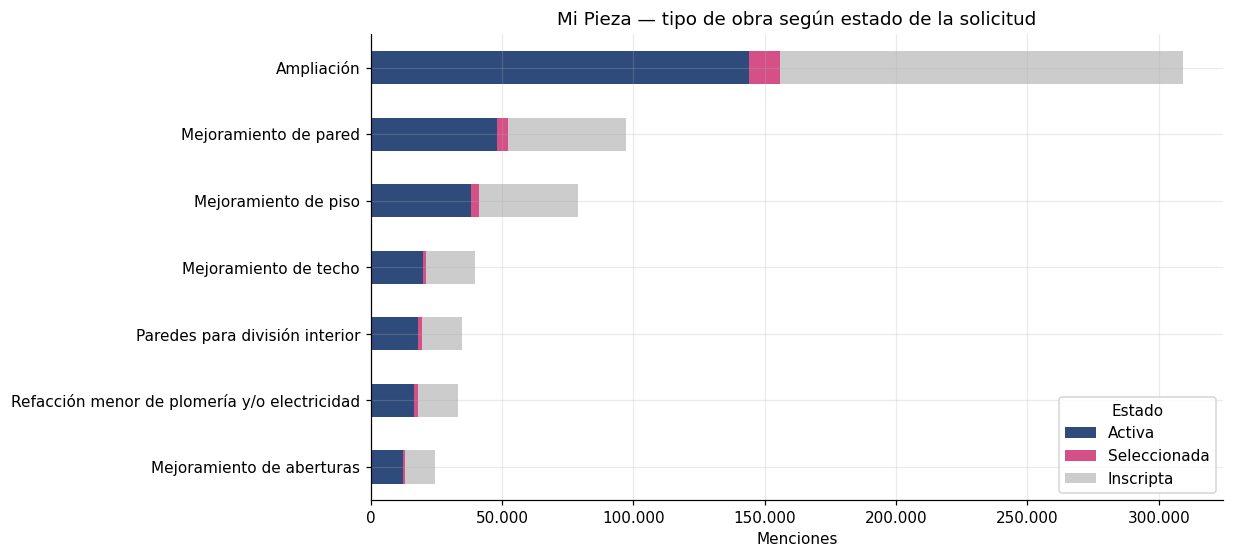

In [770]:
# --- Gráfico: tipo de obra por estado ------------------------------------
top_tipos = tipo_x_estado.drop(index="Total", errors="ignore").head(10)
cols = [c for c in ["Activa", "Seleccionada", "Inscripta"] if c in top_tipos.columns]
ax = top_tipos[cols].iloc[::-1].plot(kind="barh", stacked=True,
                                     color=[PAL[0], PAL[2], "#CCCCCC"])
ax.set_title("Mi Pieza — tipo de obra según estado de la solicitud")
ax.set_xlabel("Menciones"); ax.set_ylabel("")
ax.legend(title="Estado")
guardar_fig("03_mipieza_tipo_estado")
plt.show()

In [771]:
# --- 3.5 Mi Pieza (monitor barrial) ---------------------------------------
mpm = mipieza_mon.copy()
mpm.columns = [c.strip() for c in mpm.columns]
mpm = mpm.rename(columns={
    "Provincia": "provincia", "Municipio": "municipio",
    "ID RENABAP": "id_renabap_raw", "Barrio": "barrio",
    "Obras no iniciadas": "obras_no_iniciadas",
    "Obras en ejecución": "obras_en_ejecucion",
    "Obras terminadas": "obras_terminadas",
    "Adjudicaciones rechazadas": "adjudicaciones_rechazadas",
    "Inversión total": "inversion_total",
})
for c in ["obras_no_iniciadas", "obras_en_ejecucion", "obras_terminadas",
          "adjudicaciones_rechazadas", "inversion_total"]:
    mpm[c] = mpm[c].map(a_numero)

mpm["obras_total"] = mpm[["obras_no_iniciadas", "obras_en_ejecucion", "obras_terminadas"]].sum(axis=1)
mpm["provincia_norm"] = mpm["provincia"].map(norm_texto)
mpm["ids_renabap"]   = mpm["id_renabap_raw"].map(ids_renabap)
mpm["id_provisorio"] = mpm["id_renabap_raw"].map(id_provisorio)
print(f"Registros con identificador provisorio (asterisco): {fmt_ar(mpm['id_provisorio'].sum())}")

mipieza_mon = mpm
mipieza_mon_barrio = (mipieza_mon.explode("ids_renabap")
                                 .rename(columns={"ids_renabap": "id_renabap"}))
mipieza_mon_barrio = mipieza_mon_barrio[mipieza_mon_barrio["id_renabap"].notna()].copy()
print(texto_ar(mipieza_mon.shape), texto_ar(mipieza_mon_barrio.shape))
mipieza_mon.head(3)

Registros con identificador provisorio (asterisco): 34
(5.051, 13) (5.051, 13)


,provincia,municipio,id_renabap_raw,barrio,obras_no_iniciadas,obras_en_ejecucion,obras_terminadas,adjudicaciones_rechazadas,inversion_total,obras_total,provincia_norm,ids_renabap,id_provisorio
0,Buenos Aires,Lomas de Zamora,25,Laberinto,0,1,6,2,2.740.000,7,buenos aires,['25'],False
1,Buenos Aires,La Plata,46,Sin Nombre,0,3,68,7,24.260.000,71,buenos aires,['46'],False
2,Buenos Aires,Esteban Echeverría,785,El Gauchito Gil,0,6,61,5,26.710.000,67,buenos aires,['785'],False


---
### 3.6 Deflación — Índice del Costo de la Construcción (ICC, INDEC)

Los montos se conservan **a precios corrientes** como valor de referencia principal, y se agrega en paralelo una columna a **precios constantes** deflactada por el ICC nivel general del INDEC (Gran Buenos Aires, base 1993 = 100).

La serie se carga desde el propio repositorio (`data/raw/indice_icc.csv`), lo que hace el cuaderno reproducible sin depender de que el portal del INDEC responda.

**El archivo trae variaciones porcentuales mensuales, no niveles de índice.** No se puede deflactar directamente con esa columna: hay que reconstruir el índice encadenando las variaciones. La base de arranque es arbitraria —acá 100 en el primer mes disponible— porque la deflación trabaja con cocientes entre dos meses, y cualquier base se cancela en la división.

El archivo está en formato largo, con cuatro aperturas por mes: nivel general, materiales, mano de obra y gastos generales. Se usa el nivel general para el cálculo principal y las otras tres quedan disponibles para el análisis de sensibilidad de la celda siguiente.

Dos advertencias que conviene declarar en la tesis:

- El ICC mide costos de construcción privada de vivienda en el Gran Buenos Aires. Es el deflactor estándar para obra pública en Argentina, pero **no capta diferenciales regionales de costo**: aplicado a Tucumán es una aproximación.
- La fecha usada para deflactar es el **acta de inicio real**, no la de contratación ni la de certificación. Los proyectos sin acta informada quedan sin monto constante.

In [772]:
# --- Carga de la serie ICC -----------------------------------------------
# Formato del archivo: separador ';', decimal ',', fecha d/m/aaaa,
# estructura larga (una fila por mes y apertura), valores en variación % mensual.
MES_BASE_ICC = "2023-12"   # mes al que se llevan todos los montos

icc_crudo = pd.read_csv(f"{RAW}/indice_icc.csv", sep=";", decimal=",")
icc_crudo["fecha"] = pd.to_datetime(icc_crudo["periodo"], format="%d/%m/%Y", errors="coerce")
icc_crudo["periodo_m"] = icc_crudo["fecha"].dt.to_period("M").astype(str)

print("Aperturas disponibles:", icc_crudo["nivel_general_aperturas"].unique().tolist())
print(f"Cobertura: {icc_crudo['periodo_m'].min()} a {icc_crudo['periodo_m'].max()} "
      f"({fmt_ar(icc_crudo['periodo_m'].nunique())} meses)")
print(f"Nulos en la variación: {fmt_ar(icc_crudo['variacion_indice_icc'].isna().sum())}")
icc_crudo[icc_crudo['periodo'] == '1/1/2023'].head(5)

Aperturas disponibles: ['nivel_general', 'materiales', 'mano_de_obra', 'gastos_generales']
Cobertura: 2015-11 a 2026-07 (129 meses)
Nulos en la variación: 0


,periodo,nivel_general_aperturas,variacion_indice_icc,fecha,periodo_m
344,1/1/2023,nivel_general,"6,68",2023-01-01,2023-01
345,1/1/2023,materiales,"5,63",2023-01-01,2023-01
346,1/1/2023,mano_de_obra,"7,72",2023-01-01,2023-01
347,1/1/2023,gastos_generales,"6,91",2023-01-01,2023-01


In [773]:
# --- Reconstrucción del índice a partir de las variaciones ---------------
def encadenar(variaciones, base=100.0):
    '''Convierte una serie de variaciones % mensuales en un índice encadenado.'''
    return base * (1 + variaciones / 100).cumprod()


ICC = (icc_crudo
       .sort_values("fecha")
       .pivot_table(index="periodo_m", columns="nivel_general_aperturas",
                    values="variacion_indice_icc", aggfunc="first")
       .sort_index())

# Verificación: no puede haber meses faltantes en el medio, porque el
# encadenamiento arrastraría el hueco a toda la serie posterior.
esperados = pd.period_range(ICC.index.min(), ICC.index.max(), freq="M").astype(str)
faltantes = set(esperados) - set(ICC.index)
print(f"Meses faltantes en la serie: {fmt_ar(len(faltantes))}"
      + (f" -> {sorted(faltantes)}" if faltantes else " (serie continua)"))

for col in ICC.columns:
    ICC[f"idx_{col}"] = encadenar(ICC[col])

ICC = ICC.reset_index().rename(columns={"idx_nivel_general": "icc"})
print(f"\nÍndice reconstruido: {fmt_ar(len(ICC))} meses")
ICC[["periodo_m", "nivel_general", "icc", "idx_materiales", "idx_mano_de_obra"]].tail(6)

Meses faltantes en la serie: 0 (serie continua)

Índice reconstruido: 129 meses


nivel_general_aperturas,periodo_m,nivel_general,icc,idx_materiales,idx_mano_de_obra
123,2026-02,"2,01","12.734,59","14.983,26","10.826,88"
124,2026-03,"1,94","12.982,07","15.249,51","11.061,08"
125,2026-04,"3,93","13.491,66","15.699,06","11.603,23"
126,2026-05,"2,75","13.862,33","15.944,63","12.016,53"
127,2026-06,"2,62","14.225,81","16.233,68","12.410,63"
128,2026-07,"2,11","14.525,91","16.490,79","12.715,39"


In [774]:
# --- Aplicación del deflactor --------------------------------------------
obras["periodo_inicio"] = obras["acta_inicio"].dt.to_period("M").astype(str)
obras.loc[obras["acta_inicio"].isna(), "periodo_inicio"] = np.nan

icc_map = dict(zip(ICC["periodo_m"], ICC["icc"]))

if MES_BASE_ICC not in icc_map:
    MES_BASE_ICC = ICC["periodo_m"].max()
    print(f"Mes base fuera de la serie; se usa el último disponible: {MES_BASE_ICC}")
icc_base = icc_map[MES_BASE_ICC]

obras["icc_inicio"] = obras["periodo_inicio"].map(icc_map)
obras["monto_constante"] = obras["monto_total"] * (icc_base / obras["icc_inicio"])

n_ok = obras["monto_constante"].notna().sum()
sin_acta = obras["acta_inicio"].isna().sum()
fuera_rango = ((obras["periodo_inicio"].notna()) & (obras["icc_inicio"].isna())).sum()

print(f"Montos deflactados a precios de {MES_BASE_ICC}: {fmt_ar(n_ok)} de {fmt_ar(len(obras))} "
      f"({fmt_ar(n_ok/len(obras)*100, 1)} %)")
print(f"  sin acta de inicio informada        : {fmt_ar(sin_acta)}")
print(f"  con acta fuera del rango de la serie: {fmt_ar(fuera_rango)}")
print(f"\nTotal corriente : $ {fmt_ar(obras['monto_total'].sum())} (todos los proyectos)")
print(f"Total constante : $ {fmt_ar(obras['monto_constante'].sum())} "
      f"(sólo los {fmt_ar(n_ok)} con acta)")
print(f"Total corriente de esos mismos {fmt_ar(n_ok)}: "
      f"$ {fmt_ar(obras.loc[obras['monto_constante'].notna(), 'monto_total'].sum())}")

obras[["proyecto_id", "acta_inicio", "periodo_inicio", "monto_total",
       "icc_inicio", "monto_constante"]].head()

Montos deflactados a precios de 2023-12: 1.227 de 1.315 (93,3 %)
  sin acta de inicio informada        : 88
  con acta fuera del rango de la serie: 0

Total corriente : $ 570.179.849.167 (todos los proyectos)
Total constante : $ 1.272.254.117.178 (sólo los 1.227 con acta)
Total corriente de esos mismos 1.227: $ 529.524.864.441


,proyecto_id,acta_inicio,periodo_inicio,monto_total,icc_inicio,monto_constante
0,P00000,2024-04-15,2024-04,"269.219.376,83","7.186,06","193.043.693,77"
1,P00001,2023-12-01,2023-12,"186.308.259,30","5.152,76","186.308.259,30"
2,P00002,2023-12-15,2023-12,"181.540.041,99","5.152,76","181.540.041,99"
3,P00003,2023-09-22,2023-09,"1.273.196.907,29","3.300,70","1.987.604.223,71"
4,P00004,2023-09-29,2023-09,"29.355.856,79","3.300,70","45.827.809,20"


La última comparación importa: el total constante debe contrastarse contra el corriente **del mismo subconjunto**, no contra el total general. Comparar 1.315 proyectos corrientes con los que tienen acta informada mezcla el efecto del deflactor con el de la cobertura del dato.

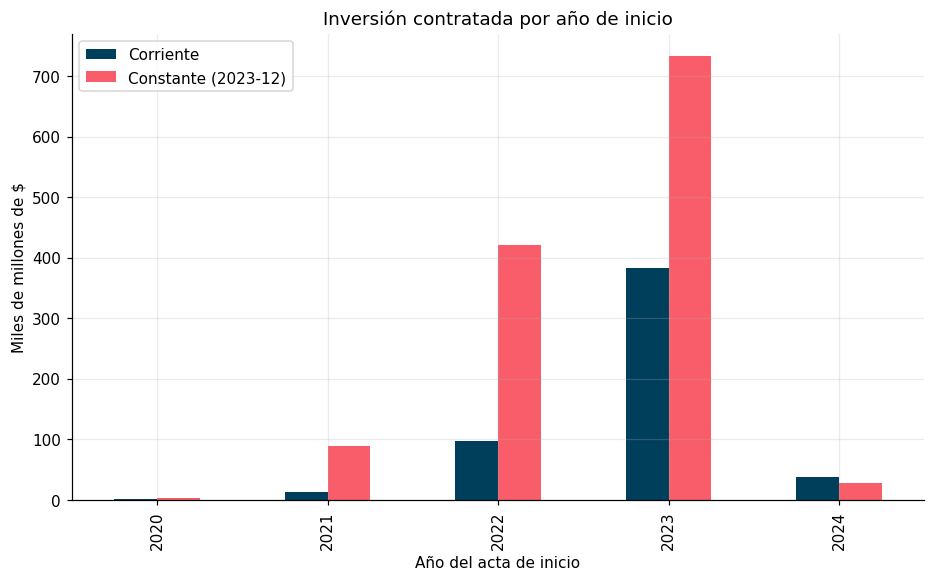

,Corriente,Constante (2023-12)
anio_inicio,,
2020,"230.076.471,29","2.426.469.271,09"
2021,"12.958.032.625,70","87.848.815.061,22"
2022,"96.237.028.553,36","420.811.709.998,04"
2023,"382.760.688.350,89","733.203.466.914,54"
2024,"37.339.038.439,48","27.963.655.933,20"


In [775]:
# Comparación corriente vs. constante por año de inicio
if obras["monto_constante"].notna().any():
    por_anio = (obras.dropna(subset=["anio_inicio"])
                     .groupby("anio_inicio")[["monto_total", "monto_constante"]]
                     .sum())
    por_anio.columns = ["Corriente", f"Constante ({MES_BASE_ICC})"]
    guardar_tabla(por_anio, "03_montos_corriente_vs_constante")

    por_anio.index = por_anio.index.astype(int)   # 2020 en vez de 2020.0
    ax = (por_anio / 1e9).plot(kind="bar", color=[PAL[7], PAL[3]])   # el eje dice "miles de millones"
    ax.set_title("Inversión contratada por año de inicio")
    ax.set_ylabel("Miles de millones de $"); ax.set_xlabel("Año del acta de inicio")
    guardar_fig("03_deflacion")
    plt.show()
    display(por_anio)

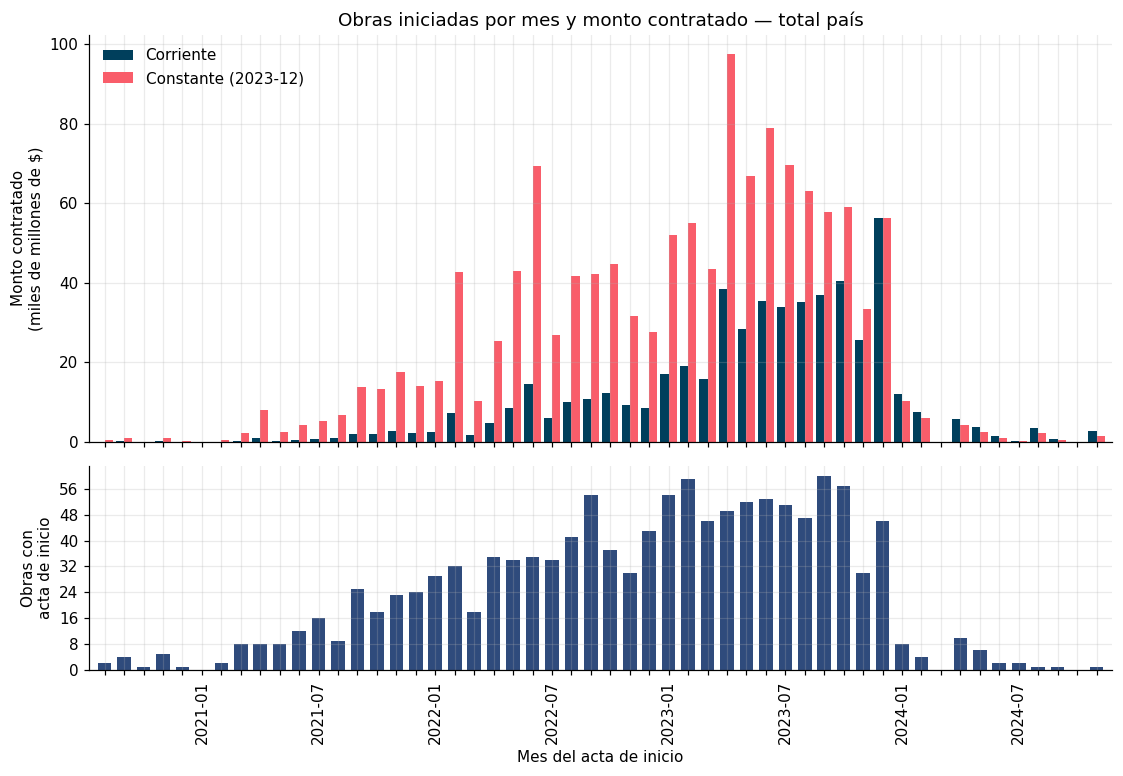

,obras,corriente,constante
periodo,,,
2023-12,46,"56,21","56,21"
2024-01,8,"11,97","10,35"
2024-02,4,"7,52","6,11"
2024-03,0,0,0
2024-04,10,"5,72","4,10"
2024-05,6,"3,62","2,34"
2024-06,2,"1,33","0,84"
2024-07,2,"0,27","0,17"
2024-08,1,"3,53","2,14"


In [776]:
# --- 3.7 Serie mensual: obras iniciadas y montos corriente vs. constante ---
# Sólo entran los proyectos con acta de inicio informada (los que tienen monto
# constante). Así las dos barras del panel superior comparan el MISMO subconjunto.

def serie_mensual(df, titulo, nombre, ancho=12):
    base = df.loc[df["monto_constante"].notna(),
                  ["periodo_inicio", "monto_total", "monto_constante"]].copy()
    base["periodo"] = pd.PeriodIndex(base["periodo_inicio"], freq="M")

    serie = (base.groupby("periodo")
                 .agg(obras=("monto_total", "size"),
                      corriente=("monto_total", "sum"),
                      constante=("monto_constante", "sum")))

    # Los meses sin obras deben aparecer vacíos, no desaparecer: si no, el
    # gráfico comprime los silencios y falsea el ritmo de la política.
    serie = serie.reindex(pd.period_range(serie.index.min(), serie.index.max(),
                                          freq="M"), fill_value=0)
    serie.index.name = "periodo"
    serie[["corriente", "constante"]] = serie[["corriente", "constante"]] / 1e9

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(ancho, 7.5),
                                   gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})
    x = np.arange(len(serie)); w = 0.42
    ax1.bar(x - w/2, serie["corriente"], width=w, color=PAL[7], label="Corriente")
    ax1.bar(x + w/2, serie["constante"], width=w, color=PAL[3],
            label=f"Constante ({MES_BASE_ICC})")
    ax1.set_ylabel("Monto contratado\n(miles de millones de $)")
    ax1.legend(frameon=False, loc="upper left")
    ax1.set_title(titulo)

    ax2.bar(x, serie["obras"], width=0.7, color=PAL[0])
    ax2.set_ylabel("Obras con\nacta de inicio")
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.set_xlabel("Mes del acta de inicio")

    etiquetas = [p.strftime("%Y-%m") if p.month in (1, 7) else "" for p in serie.index]
    ax2.set_xticks(x); ax2.set_xticklabels(etiquetas, rotation=90)
    ax2.set_xlim(-0.8, len(serie) - 0.2)

    guardar_tabla(serie, nombre); guardar_fig(nombre)
    plt.show()
    return serie

serie_nac = serie_mensual(obras,
                          "Obras iniciadas por mes y monto contratado — total país",
                          "03_serie_mensual_pais")
display(serie_nac.tail(12))

---
## 4. Esquema de clasificación F3 — tipo, dimensión y escala

Este es el núcleo del bloque. Cada proyecto se clasifica en tres capas encadenadas:

| Capa | Contenido | Origen |
|---|---|---|
| **Tipo** | Ocho ejes de intervención | construidos sobre el vocabulario efectivo de las bases |
| **Dimensión** | Infraestructuras · Equipamiento · Calidad ambiental · Situación dominial, con sus subdimensiones | matrices del Capítulo II |
| **Escala** | Barrial · Comunitaria | operacionalización del Capítulo II |

Cuatro decisiones metodológicas incorporadas:

1. **Clasificación multietiqueta.** Los nombres de proyecto enumeran componentes (`"Red de agua, Red cloacal y Conexiones domiciliarias"`), de modo que un proyecto puede activar varios tipos y varias dimensiones. Se conservan las columnas booleanas completas y se agrega un `tipo_principal` / `dimension_principal` para los cruces que exigen categoría única.

2. **Categoría "sin especificar".** Los proyectos cuyo nombre es una variante genérica de "Obras de Integración Socio Urbana" se identifican **antes** de la clasificación y quedan fuera de ella. No es una falla del clasificador: es la fuente la que no declara componentes. Son ~15% de los proyectos y su peso debe reportarse como límite de la base.

3. **Tipo y dimensión se clasifican por separado** y después se contrastan. Si fueran una simple traducción del tipo, la dimensión no aportaría información; corriéndolos en paralelo, la tabla de coherencia muestra dónde el vocabulario de la fuente y las matrices del Capítulo II no se superponen.

4. **La escala es la capa más frágil.** El nombre de un proyecto casi nunca dice si la obra es intrabarrial o de conexión con el entorno: `"Red de agua"` puede ser una red interna o un nexo. Se asigna una escala por defecto según subdimensión, se corrige con un diccionario de expresiones que sí son diagnósticas (`nexo`, `extensión de red`, `intralote`, `conexiones domiciliarias`), y **todo proyecto cuya escala no haya sido confirmada por una de esas expresiones queda marcado en `escala_verificar = True`**. Esa columna es la lista de trabajo para el cotejo con expedientes, entrevistas o imagen satelital.

---

**Una tensión que conviene resolver antes de escribir.** Las cuatro dimensiones del Capítulo II no incluyen *vivienda*, pero una parte sustantiva de lo ejecutado son núcleos húmedos, mejoramientos y —sobre todo— Mi Pieza, que es íntegramente mejoramiento habitacional. En el esquema quedan bajo la etiqueta provisoria `Vivienda (fuera de matriz)` para que sean visibles en las tablas en lugar de desaparecer. Hay dos salidas posibles: incorporarlas a "Entorno y vivienda" recuperando la formulación de la dimensión secundaria, o declarar explícitamente que las matrices operacionalizan el entorno y no la unidad habitacional. La segunda opción es defendible, pero deja a Mi Pieza sin lugar en la matriz siendo la línea de mayor cobertura territorial.

In [ ]:
# =============================================================
#  CAPA 1 — TIPO DE INTERVENCIÓN (diez ejes)
# =============================================================
EJES = {
    "infraestructura_servicios": [
        r"red de agua", r"agua potable", r"\bcloac", r"red cloacal", r"desagu", r"pluvial",
        r"electric", r"energia electrica", r"red de distribucion", r"hidraulicas",
        r"\bgas\b", r"tendido", r"agua", r"estacion de bombeo", r"electrificacion", r"infraestructura", r"servicios", r"infrastructura",
    ],
    "conexiones_intradomiciliarias": [
        r"intra[- ]?lote", r"intra[- ]?slote", r"intra[- ]?domiciliar",
        r"intra[- ]?domciliar", r"intra[- ]?conexion",
        r"conexiones domiciliar", r"conexiones e instalaciones",
        r"instalaciones intra",
        r"intras? (?:de )?(?:electric|agua|cloaca|sanitari)", r"nexo",
    ],
    "movilidad_accesibilidad": [
        r"vereda", r"cordon cuneta", r"red peatonal", r"peatonal", r"red vial", r"vial",
        r"pavimen", r"calzada", r"puente", r"escalera", r"senda", r"alumbrado",  r"via publica", r"pasillos", r"pasaje", r"iluminacion", r"calles", r"luminarias", r"pavimento",
    ],
    "ambiente": [
        r"residuos", r"ambiental",
        r"centro verde", r"ecopunto", r"punto verde", r"defensa", r"encauzamiento",
        r"canal", r"mitigacion", r"saneamiento ambiental", r"planta de separacion", r"basural", r"basurales", r"centro de acopio", r"cauce", r"saneamiento hidraulico", r"accesibilidad",
    ],
    "espacio_publico": [
        r"plaza", r"playon", r"espacio publico", r"espacio recreativo", r"recreativ", r"recreacion",
        r"deportiv", r"arbolado", r"forestac", r"parquizac",
      ],
    "equipamiento_comunitario": [
        r"equipamiento", r"centro comunitario", r"centro barrial", r"\bsum\b", r"espacio productivo",
        r"salon de usos", r"salud", r"cepla", r"jardin", r"educativ", r"comedor",
        r"posta", r"casa convivencial", r"espacio comunitario",  r"memorial", r"deporte", r"deportivo", r"polideportivo", r"espacio verde",
    ],
    "vivienda": [
        r"vivienda", r"nucleo(s)? humedo", r"mejora(miento)? de vivienda",
        r"refaccion", r"relocalizacion", r"modulo habitacional", r"\bmv\b",
    ],
    "suelo_regularizacion": [
        r"(?<!intra )(?<!intra-)(?<!intra)\blote", r"adquisicion de tierra", r"tierra privada", r"mensura",
        r"loteo", r"dominial", r"redimensionamiento",
    ],
    "planificacion_proyecto": [
        r"proyecto ejecutivo", r"\bpre ?peg\b", r"diseno de un proyecto",
        r"diseno de proyecto", r"proyecto integral", r"plan de", r"estudio", r"anteproyecto", r"plan integral", r"asistencia tecnica", r"formulacion de proyecto",
    ],
}

EJES_ETIQUETA = {
    "infraestructura_servicios":     "Infraestructura de servicios",
    "conexiones_intradomiciliarias": "Conexiones intradomiciliarias",
    "movilidad_accesibilidad":       "Movilidad y accesibilidad",
    "ambiente":                      "Ambiente",
    "espacio_publico":               "Espacio público",
    "equipamiento_comunitario":      "Equipamiento comunitario",
    "vivienda":                      "Vivienda",
    "suelo_regularizacion":          "Suelo y regularización",
    "planificacion_proyecto":        "Planificación / proyecto",
}

# Nombres genéricos que no declaran componentes -> categoría propia
PATRONES_GENERICOS = [
    r"^obras? de integracion socio ?-? ?urbanas?\.?$",
    r"^obras? de integracion sociourbanas?\.?$",
    r"^proyecto de integracion socio ?-? ?urbana$",
    r"^obras? de integracion urbana$",
    r"^obras? de interacion socio urbana$",
    r"^obras? de integracion socio urbanas? \(?etapa \d\)?$",
    r"^obras? de integracion socio urbana -?$",
]

In [ ]:
# =============================================================
#  CAPA 2 — DIMENSIÓN Y SUBDIMENSIÓN (matrices del Capítulo II)
# =============================================================
SUBDIMENSIONES = {
        "servicios_basicos_energia": {
        "dimension": "Infraestructuras",
        "etiqueta": "Servicios básicos y energía",
        "escala_defecto": "barrial",
        "patrones": [r"red de agua", r"agua potable", r"\bcloac", r"desagu", r"pluvial", r"nexo", r"red cloacal", r"energia electrica" , r"agua",
                    r"sanitari",r"\bgas\b",r"electric", r"red de distribucion", r"intra[- ]?lote", r"intra[- ]?slote", r"intra[- ]?domiciliar",
        r"intra[- ]?domciliar", r"intra[- ]?conexion", r"conexiones domiciliar", r"conexiones e instalaciones", r"hidraulicas",
        r"instalaciones intra",r"intras? (?:de )?(?:electric|agua|cloaca|sanitari)", r"nexo", r"infraestructura", r"infrastructura",
                    r"tendido electric", r"estacion de bombeo", r"agua", r"electrificacion",r"tendido", ]
    },
    "movilidad_conectividad": {
        "dimension": "Infraestructuras",
        "etiqueta": "Movilidad y conectividad",
        "escala_defecto": "barrial",
        "patrones": [r"vereda", r"cordon cuneta", r"red peatonal", r"peatonal", r"vial",
                     r"red vial", r"pavimen", r"calzada", r"puente", r"escalera", r"pavimento",  r"servicios",
                     r"senda", r"apertura de calle", r"alumbrado", r"luminaria", r"via publica", r"pasillos", r"pasaje",r"iluminacion", r"calles", r"luminarias", r"accesibilidad",],
    },

    "espacio_publico_deporte_cultura": {
        "dimension": "Equipamiento",
        "etiqueta": "Espacio público, deporte y cultura",
        "escala_defecto": "comunitaria",
        "patrones": [r"plaza", r"playon", r"espacio publico", r"espacio recreativo", r"arbolado", r"forestac", r"parquizac", r"parque",r"plazoleta",
                     r"recreativ", r"deportiv", r"cultural",  r"memorial", r"recreacion", r"deporte", r"deportivo", r"polideportivo", r"espacio verde",],
    },
    "salud_educacion": {
        "dimension": "Equipamiento",
        "etiqueta": "Salud y educación",
        "escala_defecto": "comunitaria",
        "patrones": [r"salud", r"cepla", r"jardin", r"educativ", r"escuela", r"posta",
                     r"centro de atencion primaria", r"\bcaps\b",],
    },
    "administracion_bienestar": {
        "dimension": "Equipamiento",
        "etiqueta": "Administración y bienestar",
        "escala_defecto": "comunitaria",
        "patrones": [r"centro comunitario", r"centro barrial", r"comedor",
                     r"casa convivencial", r"bienestar", r"desarrollo social", r"\bsum\b", r"salon de usos", r"espacio comunitario", r"equipamiento",],
    },
    "servicios_consumo": {
        "dimension": "Equipamiento",
        "etiqueta": "Servicios y consumo",
        "escala_defecto": "comunitaria",
        "patrones": [r"mercado", r"\bferia\b", r"comercial", r"productiv", r"espacio productivo",
                     r"polo\b", r"vivero", r"planta", ],
    },

    "ambiental": {
        "dimension": "Calidad ambiental",
        "etiqueta": "Condiciones ambientales",
        "escala_defecto": "comunitaria",
        "patrones": [ r"residuos", r"ambiental", r"defensa", r"encauzamiento", r"canal", r"mitigacion",
                     r"saneamiento ambiental", r"planta de separacion", r"basural", r"basurales",
                     r"ecopunto", r"punto verde", r"centro verde", r"centro de acopio", r"cauce", r"saneamiento",],
    },

    "regularizacion_tenencia": {
        "dimension": "Situación dominial",
        "etiqueta": "Regularización y seguridad en la tenencia",
        "escala_defecto": "barrial",
        "patrones": [r"mensura", r"dominial", r"regularizacion",
                     r"redimensionamiento", r"loteo"],
    },
    "produccion_suelo": {
        "dimension": "Situación dominial",
        "etiqueta": "Producción de suelo urbanizado",
        "escala_defecto": "comunitaria",
        "patrones": [r"lotes? con servicios", r"adquisicion de predio",
                     r"adquisicion de tierra", r"tierra privada",
                     r"(?<!intra )(?<!intra-)(?<!intra)\blote"],
    },
    "mejoramiento_vivienda": {
        "dimension": "Vivienda",
        "etiqueta": "Mejoramiento y provisión de vivienda",
        "escala_defecto": "barrial",
        "patrones": [r"vivienda", r"mejora(miento)? de vivienda", r"refaccion", r"modulo habitacional",
                     r"\bmv\b", r"nucleo(s)? humedo",
                     r"refaccion", r"modulo habitacional", r"\bmv\b", r"relocalizacion" ],
    },
    "instrumento_planificacion": {
        "dimension": "Planificación",
        "etiqueta": "Planificación y proyecto",
        "escala_defecto": "comunitaria",
        "patrones": [r"proyecto ejecutivo", r"\bpre ?peg\b", r"diseno de un proyecto",
                     r"diseno de proyecto", r"proyecto integral", r"anteproyecto", r"plan integral", r"asistencia tecnica", r"formulacion de proyecto",
                     r"plan de", r"estudio", ],
    },
}

DIMENSIONES = ["Infraestructuras", "Equipamiento", "Calidad ambiental",
               "Situación dominial", "Vivienda"]


# =============================================================
#  CAPA 3 — ESCALA: expresiones diagnósticas
# =============================================================
ESCALA_COMUNITARIA = [
    r"extension de red", r"conexion a la red troncal", r"troncal",
    r"colectora", r"planta de", r"centro verde", r"adquisicion de tierra",
    r"tierra", r"defensa", r"canal", r"puente", r"red vial",
    r"cepla", r"centro de atencion primaria", r"acceso al barrio",
]
ESCALA_BARRIAL = [
    r"intra ?lote", r"intra ?domiciliar", r"conexiones domiciliar", r"intra[- ]?conexion", r"instalaciones intra", r"intras? (?:de )?(?:electric|agua|cloaca|sanitari)", r"nucleo(s)? humedo",
    r"vivienda", r"vereda", r"mejora(miento)? de vivienda", r"refaccion",
    r"cordon cuneta", r"red peatonal interna",
]

In [ ]:
def clasificar_f3(serie_texto):
    '''Clasifica en tipo, dimensión/subdimensión y escala. Devuelve un DataFrame.'''
    txt = serie_texto.map(norm_patron).fillna("")
    out = pd.DataFrame(index=serie_texto.index)

    # --- genéricos ---
    generico = txt.str.match("|".join(PATRONES_GENERICOS), na=False)
    out["sin_especificar"] = generico

    # --- capa 1: tipo ---
    for eje, patrones in EJES.items():
        out[f"eje_{eje}"] = txt.str.contains("|".join(patrones), regex=True, na=False) & ~generico
    cols_eje = [f"eje_{e}" for e in EJES]
    out["n_ejes"] = out[cols_eje].sum(axis=1)

    def _principal(fila, claves, prefijo, etiqueta_generica):
        if fila["sin_especificar"]:
            return etiqueta_generica
        for k in claves:
            if fila[f"{prefijo}{k}"]:
                return k
        return "sin_clasificar"

    out["eje_principal"] = out.apply(
        lambda f: _principal(f, list(EJES), "eje_", "sin_especificar"), axis=1)

    # --- capa 2: subdimensión y dimensión ---
    for sub, cfg in SUBDIMENSIONES.items():
        out[f"sub_{sub}"] = txt.str.contains("|".join(cfg["patrones"]), regex=True, na=False) & ~generico
    cols_sub = [f"sub_{s}" for s in SUBDIMENSIONES]
    out["n_subdimensiones"] = out[cols_sub].sum(axis=1)

    for dim in DIMENSIONES:
        subs = [s for s, c in SUBDIMENSIONES.items() if c["dimension"] == dim]
        out[f"dim_{dim}"] = out[[f"sub_{s}" for s in subs]].any(axis=1)
    cols_dim = [f"dim_{d}" for d in DIMENSIONES]
    out["n_dimensiones"] = out[cols_dim].sum(axis=1)

    out["subdimension_principal"] = out.apply(
        lambda f: _principal(f, list(SUBDIMENSIONES), "sub_", "sin_especificar"), axis=1)
    out["dimension_principal"] = out["subdimension_principal"].map(
        lambda s: SUBDIMENSIONES[s]["dimension"] if s in SUBDIMENSIONES
        else ("Sin especificar" if s == "sin_especificar" else "Sin clasificar"))

    # --- capa 3: escala ---
    fuerza_com = txt.str.contains("|".join(ESCALA_COMUNITARIA), regex=True, na=False)
    fuerza_bar = txt.str.contains("|".join(ESCALA_BARRIAL), regex=True, na=False)

    def _escala(i):
        if out.at[i, "sin_especificar"]:
            return "sin determinar", True
        if fuerza_com[i] and fuerza_bar[i]:
            return "ambas", False
        if fuerza_com[i]:
            return "comunitaria", False
        if fuerza_bar[i]:
            return "barrial", False
        # sin expresión diagnóstica: se usa el valor por defecto de las subdimensiones
        defectos = {SUBDIMENSIONES[s]["escala_defecto"]
                    for s in SUBDIMENSIONES if out.at[i, f"sub_{s}"]}
        defectos.discard("sin determinar")
        if not defectos:
            return "sin determinar", True
        if len(defectos) > 1:
            return "ambas", True
        return defectos.pop(), True

    res = [_escala(i) for i in out.index]
    out["escala"] = [r[0] for r in res]
    out["escala_verificar"] = [r[1] for r in res]
    return out


def aplicar_f3(df, col_texto):
    nuevas = clasificar_f3(df[col_texto])
    viejas = [c for c in df.columns if c.startswith(("eje_", "sub_", "dim_"))
              or c in ("n_ejes", "n_subdimensiones", "n_dimensiones", "eje_principal",
                       "subdimension_principal", "dimension_principal", "escala",
                       "escala_verificar", "sin_especificar")]
    return pd.concat([df.drop(columns=viejas, errors="ignore"), nuevas], axis=1)


obras   = aplicar_f3(obras, "nombre_proyecto")
monitor = aplicar_f3(monitor, "nombre_obra")


# =============================================================
#  ACCIONES FUERA DE MATRIZ
# =============================================================
# Acciones registradas como "obra" que no producen transformación territorial
# y que no corresponden a ninguna dimensión de las matrices del Capítulo II.
# Quedan SIN CLASIFICAR (no se fuerzan a ninguna dimensión) y se marcan en la
# columna `fuera_de_matriz` para cuantificarlas aparte en la nota metodológica.
# El patrón es específico a propósito: las obras BID "...de las familias
# afectadas por el COVID 19" SÍ son obras físicas (mejora de viviendas) y no
# se tocan.
FUERA_DE_MATRIZ = {
    "Fortalecimiento comunitario COVID-19": r"fortalecimiento comunitario.*covid",
}


def marcar_fuera_de_matriz(df, col_texto):
    d = df.copy()
    txt = d[col_texto].map(norm_patron).fillna("")
    d["fuera_de_matriz"] = pd.Series(np.nan, index=d.index, dtype=object)
    for etiqueta, patron in FUERA_DE_MATRIZ.items():
        m = txt.str.contains(patron, regex=True, na=False)
        d.loc[m, "fuera_de_matriz"] = etiqueta
        # se garantiza que queden sin tipo y sin dimensión
        cols_bool = [c for c in d.columns if c.startswith(("eje_", "sub_", "dim_"))
                     and c not in ("eje_principal",)]
        d.loc[m, cols_bool] = False
        d.loc[m, ["eje_principal", "subdimension_principal"]] = "sin_clasificar"
        d.loc[m, "dimension_principal"] = "Sin clasificar"
        d.loc[m, "escala"] = "sin determinar"
        d.loc[m, ["n_ejes", "n_subdimensiones", "n_dimensiones"]] = 0
    return d


obras   = marcar_fuera_de_matriz(obras, "nombre_proyecto")
monitor = marcar_fuera_de_matriz(monitor, "nombre_obra")


# =============================================================
#  PASADAS COMPLEMENTARIAS
# =============================================================
# El nombre del proyecto no siempre alcanza. Se agregan dos pasadas y se deja
# registro de cómo se clasificó cada proyecto en la columna `origen_clasificacion`.

# Pasada 2 — genéricos no anclados: el nombre invoca la política sin declarar
# componentes ("Obras de Integración Socio Urbana - Barrio San Jacinto").
GENERICO_AMPLIO = r"integracion soci|integracion urbana|obras de infraestructura$|infraestructura urbana"

# Pasada 3 — imputación por línea programática. Cuando el nombre no dice nada
# pero la línea sí: MV es mejoramiento de vivienda, LOTES es suelo, PEG/PrePEG
# son instrumentos de planificación. POT no informa contenido y no se imputa.
LINEA_A_CLASIFICACION = {
    "MV":             ("vivienda", "mejoramiento_vivienda"),
    "VIVIENDA":       ("vivienda", "mejoramiento_vivienda"),
    "LOTES":          ("suelo_regularizacion", "regularizacion_tenencia"),
    "LOTES (Adq.)":   ("suelo_regularizacion", "regularizacion_tenencia"),
    "PEG":            ("planificacion_proyecto", "instrumento_planificacion"),
    "PrePEG":         ("planificacion_proyecto", "instrumento_planificacion"),
    "INTEGRAR SALUD": ("equipamiento_comunitario", "salud_educacion"),
}


def completar_clasificacion(df, col_linea="linea_programatica"):
    d = df.copy()
    d["origen_clasificacion"] = np.where(
        d["sin_especificar"], "genérico",
        np.where(d["eje_principal"] == "sin_clasificar", "sin clasificar", "nombre"))

    txt = d["nombre_proyecto"].map(norm_patron).fillna("") if "nombre_proyecto" in d \
          else d["nombre_obra"].map(norm_patron).fillna("")

    # Pasada 2
    m2 = (d["eje_principal"] == "sin_clasificar") & txt.str.contains(GENERICO_AMPLIO, na=False)
    d.loc[m2, "sin_especificar"] = True
    d.loc[m2, "eje_principal"] = "sin_especificar"
    d.loc[m2, "subdimension_principal"] = "sin_especificar"
    d.loc[m2, "dimension_principal"] = "Sin especificar"
    d.loc[m2, "escala"] = "sin determinar"
    d.loc[m2, "escala_verificar"] = True
    d.loc[m2, "origen_clasificacion"] = "genérico"

    # Pasada 3
    if col_linea in d.columns:
        sin_info = d["eje_principal"].isin(["sin_clasificar", "sin_especificar"])
        for linea, (eje, sub) in LINEA_A_CLASIFICACION.items():
            m3 = sin_info & (d[col_linea] == linea)
            if not m3.any():
                continue
            d.loc[m3, f"eje_{eje}"] = True
            d.loc[m3, f"sub_{sub}"] = True
            d.loc[m3, f"dim_{SUBDIMENSIONES[sub]['dimension']}"] = True
            d.loc[m3, "eje_principal"] = eje
            d.loc[m3, "subdimension_principal"] = sub
            d.loc[m3, "dimension_principal"] = SUBDIMENSIONES[sub]["dimension"]
            d.loc[m3, "escala"] = SUBDIMENSIONES[sub]["escala_defecto"]
            d.loc[m3, "escala_verificar"] = True
            d.loc[m3, "sin_especificar"] = False
            d.loc[m3, "origen_clasificacion"] = "línea programática"

    d["n_ejes"] = d[[f"eje_{e}" for e in EJES]].sum(axis=1)
    d["n_subdimensiones"] = d[[f"sub_{x}" for x in SUBDIMENSIONES]].sum(axis=1)
    d["n_dimensiones"] = d[[f"dim_{x}" for x in DIMENSIONES]].sum(axis=1)
    return d


obras = completar_clasificacion(obras)

print("Origen de la clasificación de cada proyecto:")
print(obras["origen_clasificacion"].value_counts().ar.to_string())

# --- Nombres de municipio que designan la misma jurisdicción -------------
# "Lules" y "San Isidro de Lules" son la misma Municipalidad de San Isidro de
# Lules; las bases nacionales alternan ambas formas.
EQUIVALENCIAS_MUNICIPIO = {
    "lules": "san isidro de lules",
    "san isidro de lules": "san isidro de lules",
}

def unificar_municipio(m):
    return EQUIVALENCIAS_MUNICIPIO.get(m, m)

obras["municipio_amt"]   = obras["municipio_norm"].map(unificar_municipio)
monitor["municipio_amt"] = monitor["municipio_norm"].map(unificar_municipio)

# --- Reconstrucción de las tablas por barrio con la clasificación F3 -----
def explotar(df, col_id="ids_renabap"):
    d = df.explode(col_id).rename(columns={col_id: "id_renabap"})
    d = d[d["id_renabap"].notna()].copy()
    d["id_renabap"] = d["id_renabap"].astype(str)
    return d

obras_barrio       = explotar(obras)
monitor_barrio     = explotar(monitor)
mipieza_mon_barrio = explotar(mipieza_mon)

print(f"Proyectos totales          : {fmt_ar(len(obras))}")
print(f"Genéricos (sin especificar): {fmt_ar(obras['sin_especificar'].sum())} "
      f"({fmt_ar(obras['sin_especificar'].mean()*100, 1)} %)")
print(f"Sin clasificar por tipo    : {fmt_ar((obras['eje_principal'] == 'sin_clasificar').sum())}")
print(f"Sin clasificar por dimensión: {fmt_ar((obras['dimension_principal'] == 'Sin clasificar').sum())}")

In [ ]:
# --- Acciones fuera de matriz: cuantificación para la nota metodológica ---
def resumen_fuera_de_matriz(df, fuente, col_monto):
    f = df[df["fuera_de_matriz"].notna()]
    if f.empty:
        return None
    barrios = set().union(*f["ids_renabap"].map(set))
    return pd.Series({
        "registros": len(f),
        "% de los registros de la fuente": round(len(f) / len(df) * 100, 1),
        "monto ($ corrientes)": f[col_monto].sum(),
        "% del monto de la fuente": round(f[col_monto].sum() / df[col_monto].sum() * 100, 1),
        "barrios alcanzados (id RENABAP)": len(barrios),
        "de ellos en el AMT": len(barrios & IDS_AMT),
        "registros multibarriales": int((f["n_barrios"] > 1).sum()),
    }, name=fuente)

res_fm = [r for r in [resumen_fuera_de_matriz(obras, "datos.gob.ar", "monto_total"),
                      resumen_fuera_de_matriz(monitor, "Monitor", "inversion_total")]
          if r is not None]

for etiqueta in FUERA_DE_MATRIZ:
    print(f"ACCIÓN FUERA DE MATRIZ: {etiqueta}\n")
    tabla_fm = pd.DataFrame(res_fm).T
    guardar_tabla(tabla_fm, "04_fuera_de_matriz_resumen")      # CSV con números
    # Vista con formato por fila: conteos enteros, porcentajes con un decimal
    display(tabla_fm.apply(lambda fila: fila.map(
        lambda v: fmt_ar(v, 1) if str(fila.name).startswith("%") else fmt_ar(v)), axis=1))

    det_fm = monitor[monitor["fuera_de_matriz"] == etiqueta]
    if len(det_fm):
        print("\nEstado de las acciones (Monitor):")
        display(det_fm["estado"].value_counts().to_frame("registros"))
        print("\nDetalle (Monitor):")
        tabla_det_fm = det_fm[["obra_id", "nombre_obra", "provincia", "n_barrios",
                               "id_renabap_raw", "estado", "inversion_total"]]
        guardar_tabla(tabla_det_fm.set_index("obra_id"), "04_fuera_de_matriz_detalle")
        display(tabla_det_fm)


In [ ]:
# --- Carácter de la intervención (atributo, no dimensión) ---------------
# Planificación no es una dimensión territorial: no produce transformación,
# produce un documento. Se registra como atributo del proyecto, ortogonal a
# la dimensión, para poder separar obra de proyecto sin inflar la cobertura.
EJES_OBRA = [e for e in EJES if e != "planificacion_proyecto"]

obras["caracter_intervencion"] = np.where(
    obras["eje_planificacion_proyecto"] & ~obras[[f"eje_{e}" for e in EJES_OBRA]].any(axis=1),
    "proyecto / estudio", "obra")

print(obras["caracter_intervencion"].value_counts().ar.to_string())
print()
print(texto_ar(pd.crosstab(obras["linea_programatica"], obras["caracter_intervencion"])))

In [ ]:
# --- 4.bis Diagnóstico: por qué quedan proyectos sin clasificar ----------
# Tres chequeos encadenados. El primero es estructural y se corre antes de
# mirar los datos: si un patrón vive en EJES pero en ninguna subdimensión,
# el proyecto va a tener tipo y no va a tener dimensión, por construcción.

patrones_sub = set()
for cfg in SUBDIMENSIONES.values():
    patrones_sub |= set(cfg["patrones"])

huerfanos = {e: [p for p in ps if p not in patrones_sub] for e, ps in EJES.items()}
huerfanos = {e: ps for e, ps in huerfanos.items() if ps}

print("CHEQUEO 1 — patrones presentes en EJES y ausentes de toda subdimensión:")
if huerfanos:
    for e, ps in huerfanos.items():
        print(f"  {EJES_ETIQUETA.get(e, e):32s} -> {ps}")
else:
    print("  ninguno: las dos capas cubren el mismo vocabulario.")

# Chequeo 2 — coherencia entre la lista DIMENSIONES y lo declarado en las
# subdimensiones. Un desajuste de string acá no da error: da columnas vacías.
dims_declaradas = {c["dimension"] for c in SUBDIMENSIONES.values()}
print("\nCHEQUEO 2 — coherencia de nombres de dimensión:")
sobran = [d for d in DIMENSIONES if d not in dims_declaradas]
faltan = [d for d in dims_declaradas if d not in DIMENSIONES]
DIMENSIONES_EXCLUIDAS = ["Planificación"]   # deliberadamente fuera de las matrices
faltan = [d for d in dims_declaradas if d not in DIMENSIONES and d not in DIMENSIONES_EXCLUIDAS]
print(f"  en DIMENSIONES sin ninguna subdimensión: {sobran if sobran else 'ninguna'}")
print(f"  usadas en SUBDIMENSIONES y no listadas : {faltan if faltan else 'ninguna'}")
if sobran or faltan:
    print("  ATENCIÓN: los nombres deben coincidir carácter por carácter.")


In [ ]:
# --- 4.bis (cont.) Tabla de proyectos sin clasificar --------------------
sin_dim = obras[obras["dimension_principal"] == "Sin clasificar"]
sin_tipo = obras[(obras["eje_principal"] == "sin_clasificar") & (~obras["sin_especificar"])]

print(f"Sin clasificar por TIPO      : {fmt_ar(len(sin_tipo))} ({fmt_ar(len(sin_tipo)/len(obras)*100, 1)} %)")
print(f"Sin clasificar por DIMENSIÓN : {fmt_ar(len(sin_dim))} ({fmt_ar(len(sin_dim)/len(obras)*100, 1)} %)")
print(f"Con tipo asignado pero SIN dimensión: "
      f"{fmt_ar(len(sin_dim[sin_dim['eje_principal'] != 'sin_clasificar']))}\n")

print("CHEQUEO 3 — qué tipo tenían los proyectos que se quedaron sin dimensión:")
display(sin_dim["eje_principal"].map(lambda e: EJES_ETIQUETA.get(e, e)).value_counts())

tabla_sin_clasificar = (obras.loc[
        (obras["dimension_principal"] == "Sin clasificar") |
        ((obras["eje_principal"] == "sin_clasificar") & (~obras["sin_especificar"])),
        ["proyecto_id", "provincia", "municipio", "linea_programatica", "financiamiento",
         "nombre_proyecto", "eje_principal", "dimension_principal", "origen_clasificacion"]]
    .sort_values(["eje_principal", "linea_programatica"]))
guardar_tabla(tabla_sin_clasificar.set_index("proyecto_id"), "04_sin_clasificar_detalle")

print(f"\nTabla de trabajo: {fmt_ar(len(tabla_sin_clasificar))} proyectos a revisar a mano.")
print("Agrupados por nombre repetido:\n")
display(tabla_sin_clasificar["nombre_proyecto"].value_counts().head(25).to_frame("proyectos"))
tabla_sin_clasificar.head(30)

In [ ]:
# --- Capa 1 y 2: tabla conjunta de tipos y dimensiones ------------------
# Ambas capas son multietiqueta: los porcentajes NO suman 100 porque un
# proyecto puede declarar varias componentes.

tabla_tipos = pd.DataFrame({
    "proyectos": [obras[f"eje_{e}"].sum() for e in EJES],
    "% de proyectos": [(obras[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
    "monto corriente": [obras.loc[obras[f"eje_{e}"], "monto_total"].sum() for e in EJES],
}, index=[EJES_ETIQUETA[e] for e in EJES])
tabla_tipos.loc["Sin especificar (genéricos)"] = [
    obras["sin_especificar"].sum(),
    round(obras["sin_especificar"].mean() * 100, 1),
    obras.loc[obras["sin_especificar"], "monto_total"].sum()]
tabla_tipos.index.name = "TIPO de intervención"
tabla_tipos = tabla_tipos.sort_values("proyectos", ascending=False)
guardar_tabla(tabla_tipos, "04_tipos_nacional")

tabla_dims = pd.DataFrame({
    "proyectos": [obras[f"dim_{d}"].sum() for d in DIMENSIONES],
    "% de proyectos": [(obras[f"dim_{d}"].mean() * 100).round(1) for d in DIMENSIONES],
    "monto corriente": [obras.loc[obras[f"dim_{d}"], "monto_total"].sum() for d in DIMENSIONES],
}, index=DIMENSIONES)
tabla_dims.index.name = "DIMENSIÓN (matrices Cap. II)"
guardar_tabla(tabla_dims, "04_dimensiones_nacional")

tabla_subs = pd.DataFrame({
    "dimensión": [SUBDIMENSIONES[x]["dimension"] for x in SUBDIMENSIONES],
    "proyectos": [obras[f"sub_{x}"].sum() for x in SUBDIMENSIONES],
    "% de proyectos": [(obras[f"sub_{x}"].mean() * 100).round(1) for x in SUBDIMENSIONES],
}, index=[SUBDIMENSIONES[x]["etiqueta"] for x in SUBDIMENSIONES])
tabla_subs.index.name = "SUBDIMENSIÓN"
guardar_tabla(tabla_subs, "04_subdimensiones_nacional")

print("CAPA 1 — TIPO de intervención")
display(tabla_tipos)
print("\nCAPA 2 — DIMENSIÓN")
display(tabla_dims)
print("\nCAPA 2 — SUBDIMENSIÓN")
display(tabla_subs.sort_values("proyectos", ascending=False))

In [875]:
# --- Inspección: qué patrón concreto disparó cada clasificación ---------
# Herramienta general. Dado un conjunto de patrones, devuelve para cada
# proyecto cuáles coincidieron. Sirve para auditar cualquier eje o
# subdimensión que dé un resultado sospechoso.

def patrones_disparados(serie_texto, patrones):
    txt = serie_texto.map(norm_patron).fillna("")
    return txt.map(lambda s: ", ".join(p for p in patrones if re.search(p, s)))


def resumen_patrones(serie_texto, patrones, etiqueta=""):
    txt = serie_texto.map(norm_patron).fillna("")
    r = pd.DataFrame({
        "patrón": patrones,
        "proyectos": [int(txt.str.contains(p, regex=True, na=False).sum()) for p in patrones],
    }).sort_values("proyectos", ascending=False).set_index("patrón")
    r["% del grupo"] = (r["proyectos"] / max(r["proyectos"].max(), 1) * 100).round(1)
    if etiqueta:
        r.index.name = f"patrón ({etiqueta})"
    return r

In [876]:
# --- Inspección A: TIPO "Suelo y regularización" ------------------------
CLAVE = "suelo_regularizacion"

sel_tipo = obras[obras[f"eje_{CLAVE}"]].copy()
sel_tipo["patrones_que_dispararon"] = patrones_disparados(
    sel_tipo["nombre_proyecto"], EJES[CLAVE])

print(f"TIPO: {EJES_ETIQUETA[CLAVE]}")
print(f"Proyectos seleccionados: {fmt_ar(len(sel_tipo))} de {fmt_ar(len(obras))} "
      f"({fmt_ar(len(sel_tipo)/len(obras)*100, 1)} %)\n")

print("Cuántos proyectos activa cada patrón (un proyecto puede activar varios):")
display(resumen_patrones(obras["nombre_proyecto"], EJES[CLAVE], EJES_ETIQUETA[CLAVE]))

print("\nLínea programática de los proyectos seleccionados:")
display(sel_tipo["linea_programatica"].value_counts().to_frame("proyectos"))

tabla_tipo = sel_tipo[["proyecto_id", "provincia", "municipio", "linea_programatica",
                       "financiamiento", "nombre_proyecto", "patrones_que_dispararon",
                       "eje_principal", "dimension_principal", "escala"]]
guardar_tabla(tabla_tipo.set_index("proyecto_id"), f"04_inspeccion_tipo_{CLAVE}")
print("\nDetalle completo exportado. Primeras filas:")
tabla_tipo.head(40)

TIPO: Suelo y regularización
Proyectos seleccionados: 136 de 1.315 (10,3 %)

Cuántos proyectos activa cada patrón (un proyecto puede activar varios):


,proyectos,% del grupo
patrón (Suelo y regularización),,
(?<!intra )(?<!intra-)(?<!intra)\blote,115,"100,0"
adquisicion de tierra,26,"22,6"
tierra privada,26,"22,6"
loteo,6,"5,2"
mensura,3,"2,6"
dominial,1,"0,9"
redimensionamiento,0,"0,0"



Línea programática de los proyectos seleccionados:


,proyectos
linea_programatica,
LOTES,102
LOTES (Adq.),15
POT,8
PEG,7
VIVIENDA,4



Detalle completo exportado. Primeras filas:


,proyecto_id,provincia,municipio,linea_programatica,financiamiento,nombre_proyecto,patrones_que_dispararon,eje_principal,dimension_principal,escala
90,P00090,Río Negro,El Bolsón,PEG,FISU,"ABASTECIMIENTO DE AGUA Y CONEXIONES DOMICILIARIAS, RED MT Y BT ELECTRICA, CONEXIONES DOMICILIARIAS DE RED ELECTRICA, AGRIMENSURA Y DESBOQUE (etapa 01)",mensura,infraestructura_servicios,Infraestructuras,barrial
152,P00152,Buenos Aires,Olavarría,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria
154,P00154,Buenos Aires,Florencio Varela,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria
162,P00162,Buenos Aires,Tandil,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria
174,P00174,San Juan,Ullum,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria
175,P00175,Buenos Aires,General Pueyrredón,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria
176,P00176,Buenos Aires,Mercedes,LOTES,FISU,Adquisición de predio y ejecución de infraestructura para 190 lotes con servicios,(?<!intra )(?<!intra-)(?<!intra)\blote,infraestructura_servicios,Infraestructuras,ambas
177,P00177,Córdoba,Santa María,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria
178,P00178,Buenos Aires,25 de Mayo,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria
184,P00184,Córdoba,Capital,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,Situación dominial,comunitaria


In [877]:
# --- Inspección B: DIMENSIÓN "Situación dominial" -----------------------
DIM = "Situación dominial"

subs_dim = [s for s, c in SUBDIMENSIONES.items() if c["dimension"] == DIM]
patrones_dim = [p for s in subs_dim for p in SUBDIMENSIONES[s]["patrones"]]

sel_dim = obras[obras[f"dim_{DIM}"]].copy()
sel_dim["patrones_que_dispararon"] = patrones_disparados(
    sel_dim["nombre_proyecto"], patrones_dim)

print(f"DIMENSIÓN: {DIM}")
print(f"Subdimensiones que la componen: {[SUBDIMENSIONES[s]['etiqueta'] for s in subs_dim]}")
print(f"Proyectos seleccionados: {fmt_ar(len(sel_dim))} de {fmt_ar(len(obras))} "
      f"({fmt_ar(len(sel_dim)/len(obras)*100, 1)} %)\n")

display(resumen_patrones(obras["nombre_proyecto"], patrones_dim, DIM))

print("\n¿Es la dimensión principal o una etiqueta secundaria?")
display(sel_dim["dimension_principal"].value_counts().to_frame("proyectos"))

print("\nOtras dimensiones que activan los mismos proyectos:")
otras = pd.Series({d: int(sel_dim[f"dim_{d}"].sum()) for d in DIMENSIONES if d != DIM})
display(otras.sort_values(ascending=False).to_frame("proyectos"))

tabla_dim = sel_dim[["proyecto_id", "provincia", "municipio", "linea_programatica",
                     "financiamiento", "nombre_proyecto", "patrones_que_dispararon",
                     "eje_principal", "subdimension_principal", "dimension_principal",
                     "escala"]]
guardar_tabla(tabla_dim.set_index("proyecto_id"), "04_inspeccion_dim_situacion_dominial")
tabla_dim.head(40)

DIMENSIÓN: Situación dominial
Subdimensiones que la componen: ['Regularización y seguridad en la tenencia', 'Producción de suelo urbanizado']
Proyectos seleccionados: 136 de 1.315 (10,3 %)



,proyectos,% del grupo
patrón (Situación dominial),,
(?<!intra )(?<!intra-)(?<!intra)\blote,115,"100,0"
lotes? con servicios,108,"93,9"
adquisicion de predio,62,"53,9"
adquisicion de tierra,26,"22,6"
tierra privada,26,"22,6"
loteo,6,"5,2"
mensura,3,"2,6"
dominial,1,"0,9"
regularizacion,1,"0,9"



¿Es la dimensión principal o una etiqueta secundaria?


,proyectos
dimension_principal,
Infraestructuras,116
Situación dominial,20



Otras dimensiones que activan los mismos proyectos:


,proyectos
Infraestructuras,116
Equipamiento,6
Vivienda,5
Calidad ambiental,1


,proyecto_id,provincia,municipio,linea_programatica,financiamiento,nombre_proyecto,patrones_que_dispararon,eje_principal,subdimension_principal,dimension_principal,escala
90,P00090,Río Negro,El Bolsón,PEG,FISU,"ABASTECIMIENTO DE AGUA Y CONEXIONES DOMICILIARIAS, RED MT Y BT ELECTRICA, CONEXIONES DOMICILIARIAS DE RED ELECTRICA, AGRIMENSURA Y DESBOQUE (etapa 01)",mensura,infraestructura_servicios,servicios_basicos_energia,Infraestructuras,barrial
152,P00152,Buenos Aires,Olavarría,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria
154,P00154,Buenos Aires,Florencio Varela,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria
162,P00162,Buenos Aires,Tandil,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria
174,P00174,San Juan,Ullum,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria
175,P00175,Buenos Aires,General Pueyrredón,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria
176,P00176,Buenos Aires,Mercedes,LOTES,FISU,Adquisición de predio y ejecución de infraestructura para 190 lotes con servicios,"lotes? con servicios, adquisicion de predio, (?<!intra )(?<!intra-)(?<!intra)\blote",infraestructura_servicios,servicios_basicos_energia,Infraestructuras,ambas
177,P00177,Córdoba,Santa María,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria
178,P00178,Buenos Aires,25 de Mayo,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria
184,P00184,Córdoba,Capital,LOTES,FISU,Adquisición de tierra privada,"adquisicion de tierra, tierra privada",suelo_regularizacion,produccion_suelo,Situación dominial,comunitaria


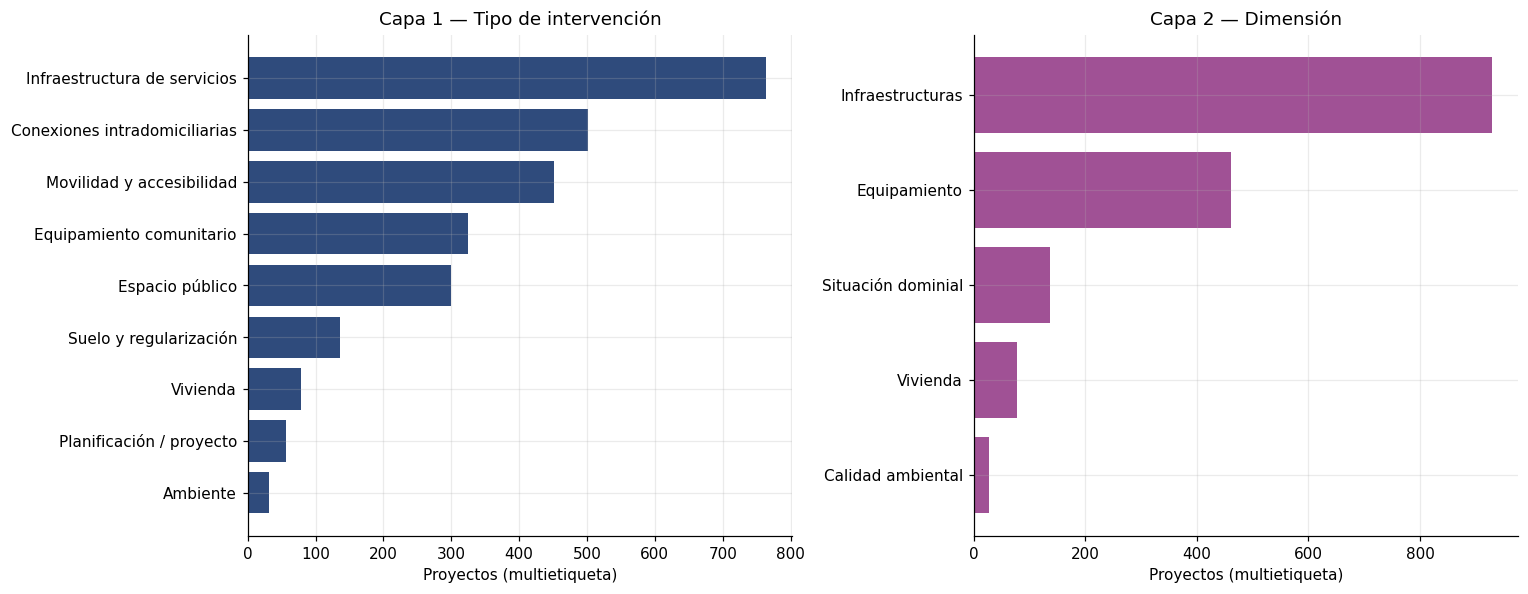

In [878]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
t = tabla_tipos.drop(index="Sin especificar (genéricos)", errors="ignore").sort_values("proyectos")
axes[0].barh(t.index, t["proyectos"], color=PAL[0])
axes[0].set_title("Capa 1 — Tipo de intervención")
axes[0].set_xlabel("Proyectos (multietiqueta)")
d = tabla_dims.sort_values("proyectos")
axes[1].barh(d.index, d["proyectos"], color=PAL[1])
axes[1].set_title("Capa 2 — Dimensión")
axes[1].set_xlabel("Proyectos (multietiqueta)")
plt.tight_layout()
guardar_fig("04_tipos_y_dimensiones")
plt.show()

In [879]:
# --- Coherencia entre capas: tipo x dimensión principal -------------------
coherencia = pd.crosstab(
    obras["eje_principal"].map(lambda e: EJES_ETIQUETA.get(e, e)),
    obras["dimension_principal"])
guardar_tabla(coherencia, "04_coherencia_tipo_dimension")
coherencia

dimension_principal,Calidad ambiental,Equipamiento,Infraestructuras,Planificación,Sin clasificar,Sin especificar,Situación dominial,Vivienda
eje_principal,,,,,,,,
Ambiente,16,7,0,0,0,0,0,0
COVID,0,0,0,20,0,0,0,0
Conexiones intradomiciliarias,0,0,9,0,0,0,0,0
Equipamiento comunitario,0,96,0,0,0,0,0,0
Espacio público,0,67,0,0,0,0,0,0
Infraestructura de servicios,0,0,764,0,0,0,0,0
Movilidad y accesibilidad,0,0,156,0,0,0,0,0
Planificación / proyecto,0,0,0,55,0,0,0,0
Suelo y regularización,0,0,0,0,0,0,20,0


In [880]:
# --- Inspección C: control de cada DIMENSIÓN ------------------------------
# Generaliza la Inspección B a cualquier dimensión y a las dos fuentes de obras,
# y agrega el cruce con la capa de TIPO para ubicar de dónde sale cada
# incoherencia de la tabla "Coherencia entre capas".

# Dimensión que corresponde, en principio, a cada tipo. Es el supuesto que se
# pone a prueba: si tipo y dimensión no coinciden, uno de los dos vocabularios
# está captando algo que el otro no.
TIPO_A_DIM = {
    "infraestructura_servicios":     "Infraestructuras",
    "conexiones_intradomiciliarias": "Infraestructuras",
    "movilidad_accesibilidad":       "Infraestructuras",
    "ambiente":                      "Calidad ambiental",
    "espacio_publico":               "Equipamiento",
    "equipamiento_comunitario":      "Equipamiento",
    "vivienda":                      "Vivienda",
    "suelo_regularizacion":          "Situación dominial",
    "planificacion_proyecto":        "Planificación",
}


def inspeccionar_dimension(DIM, df=None, fuente="datos.gob.ar",
                           col_nombre="nombre_proyecto", col_id="proyecto_id", filas=40):
    '''Control de una dimensión en cualquiera de las dos fuentes de obras.
    datos.gob.ar -> inspeccionar_dimension("Equipamiento")
    Monitor      -> inspeccionar_dimension("Equipamiento", **MONITOR)'''
    df = obras if df is None else df
    subs_dim = [s for s, c in SUBDIMENSIONES.items() if c["dimension"] == DIM]
    patrones_dim = list(dict.fromkeys(p for s in subs_dim for p in SUBDIMENSIONES[s]["patrones"]))  # sin repetidos
    tipos_dim = [t for t, d in TIPO_A_DIM.items() if d == DIM]
    patrones_tipo = list(dict.fromkeys(p for t in tipos_dim for p in EJES[t]))
    slug = norm_texto(DIM).replace(" ", "_") + ("" if fuente == "datos.gob.ar" else "_" + norm_texto(fuente).replace(" ", "_"))

    sel = df[df[f"dim_{DIM}"]].copy()
    sel["patrones_dimension"] = patrones_disparados(sel[col_nombre], patrones_dim)

    print(f"DIMENSIÓN: {DIM}   |   FUENTE: {fuente}")
    print(f"Subdimensiones: {[SUBDIMENSIONES[s]['etiqueta'] for s in subs_dim]}")
    print(f"Tipos que le corresponden: {[EJES_ETIQUETA[t] for t in tipos_dim]}")
    print(f"Obras con la dimensión (multietiqueta): {fmt_ar(len(sel))} de {fmt_ar(len(df))} "
          f"({fmt_ar(len(sel)/len(df)*100, 1)} %)")
    print(f"  como dimensión principal: {fmt_ar((df['dimension_principal'] == DIM).sum())}\n")

    # 1. Qué patrón dispara la dimensión
    print("1. Patrones de la dimensión y cuántas obras activa cada uno:")
    display(resumen_patrones(df[col_nombre], patrones_dim, DIM))

    # 2. Principal o secundaria; y si es secundaria, qué la desplaza
    print("\n2. Dimensión principal de las obras que tienen esta dimensión:")
    display(sel["dimension_principal"].value_counts().to_frame("obras"))

    # 3. Vocabulario: patrones que están en una capa y no en la otra
    solo_tipo = [p for p in patrones_tipo if p not in patrones_dim]
    solo_dim = [p for p in patrones_dim if p not in patrones_tipo]
    print("\n3. Asimetrías de vocabulario entre capas:")
    print(f"   en el TIPO y no en la DIMENSIÓN: {solo_tipo if solo_tipo else 'ninguno'}")
    print(f"   en la DIMENSIÓN y no en el TIPO: {solo_dim if solo_dim else 'ninguno'}")

    # 4. Discordancias tipo principal <-> dimensión principal
    dim_esperada = df["eje_principal"].map(TIPO_A_DIM)
    tipo_sin_dim = df[(dim_esperada == DIM) & (df["dimension_principal"] != DIM)]
    dim_sin_tipo = df[(df["dimension_principal"] == DIM) & (dim_esperada != DIM)
                      & (df["eje_principal"].isin(TIPO_A_DIM))]
    print(f"\n4. Discordancias entre capas (principal vs. principal):")
    print(f"   tipo de {DIM} pero otra dimensión principal: {fmt_ar(len(tipo_sin_dim))}")
    print(f"   dimensión {DIM} pero otro tipo principal   : {fmt_ar(len(dim_sin_tipo))}")

    disc = pd.concat([tipo_sin_dim.assign(discordancia="tipo sí, dimensión no"),
                      dim_sin_tipo.assign(discordancia="dimensión sí, tipo no")])
    if len(disc):
        disc["patrones_tipo"] = patrones_disparados(disc[col_nombre], patrones_tipo)
        disc["patrones_dimension"] = patrones_disparados(disc[col_nombre], patrones_dim)
        disc["eje_principal"] = disc["eje_principal"].map(lambda e: EJES_ETIQUETA.get(e, e))
        print("\n   Resumen de las discordancias:")
        display(pd.crosstab([disc["discordancia"], disc["eje_principal"]],
                            disc["dimension_principal"]))

    # 5. Tabla de trabajo exportable
    # (las columnas que una fuente no tiene, como la línea programática en el Monitor, se omiten)
    cols = [c for c in [col_id, "provincia", "municipio", "linea_programatica", col_nombre,
                        "patrones_dimension", "eje_principal", "subdimension_principal",
                        "dimension_principal", "escala"] if c in sel.columns]
    guardar_tabla(sel[cols].set_index(col_id), f"04_inspeccion_dim_{slug}")
    if len(disc):
        cols_d = [c for c in [col_id, "discordancia", "linea_programatica", col_nombre,
                              "eje_principal", "patrones_tipo", "dimension_principal",
                              "subdimension_principal", "patrones_dimension"] if c in disc.columns]
        tabla_disc = disc[cols_d]
        guardar_tabla(tabla_disc.set_index(col_id), f"04_discordancias_dim_{slug}")
        print(f"\n5. Discordancias a revisar (exportadas en 04_discordancias_dim_{slug}.csv):")
        display(tabla_disc.head(filas))
    return sel, disc

In [881]:
# --- C.1 Infraestructuras (datos.gob.ar)
insp_infra, disc_infra = inspeccionar_dimension("Infraestructuras")

DIMENSIÓN: Infraestructuras   |   FUENTE: datos.gob.ar
Subdimensiones: ['Servicios básicos y energía', 'Movilidad y conectividad']
Tipos que le corresponden: ['Infraestructura de servicios', 'Conexiones intradomiciliarias', 'Movilidad y accesibilidad']
Obras con la dimensión (multietiqueta): 929 de 1.315 (70,6 %)
  como dimensión principal: 929

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Infraestructuras),,
electric,357,"100,0"
intra[- ]?lote,354,"99,2"
instalaciones intra,314,"88,0"
peatonal,291,"81,5"
red peatonal,285,"79,8"
agua,279,"78,2"
conexiones e instalaciones,227,"63,6"
infraestructura,170,"47,6"
conexiones domiciliar,146,"40,9"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Infraestructuras,929



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ninguno
   en la DIMENSIÓN y no en el TIPO: ['sanitari', 'tendido electric', 'apertura de calle', 'luminaria', 'accesibilidad']

4. Discordancias entre capas (principal vs. principal):
   tipo de Infraestructuras pero otra dimensión principal: 0
   dimensión Infraestructuras pero otro tipo principal   : 0


In [882]:
# --- C.2 Equipamiento (datos.gob.ar)
insp_equip, disc_equip = inspeccionar_dimension("Equipamiento")

DIMENSIÓN: Equipamiento   |   FUENTE: datos.gob.ar
Subdimensiones: ['Espacio público, deporte y cultura', 'Salud y educación', 'Administración y bienestar', 'Servicios y consumo']
Tipos que le corresponden: ['Espacio público', 'Equipamiento comunitario']
Obras con la dimensión (multietiqueta): 442 de 1.315 (33,6 %)
  como dimensión principal: 171

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Equipamiento),,
equipamiento,266,"100,0"
arbolado,169,"63,5"
deportiv,62,"23,3"
deportivo,62,"23,3"
playon,56,"21,1"
recreativ,51,"19,2"
espacio recreativo,37,"13,9"
plaza,32,"12,0"
\bsum\b,22,"8,3"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Infraestructuras,271
Equipamiento,171



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ['espacio productivosalon de usos']
   en la DIMENSIÓN y no en el TIPO: ['parque', 'plazoleta', 'deportiv', 'cultural', 'recreacion', 'escuela', 'centro de atencion primaria', '\\bcaps\\b', 'bienestar', 'desarrollo social', 'salon de usos', 'mercado', '\\bferia\\b', 'comercial', 'productiv', 'espacio productivo', 'polo\\b', 'vivero', 'planta']

4. Discordancias entre capas (principal vs. principal):
   tipo de Equipamiento pero otra dimensión principal: 0
   dimensión Equipamiento pero otro tipo principal   : 7

   Resumen de las discordancias:


,dimension_principal,Equipamiento
discordancia,eje_principal,
"dimensión sí, tipo no",Ambiente,7



5. Discordancias a revisar (exportadas en 04_discordancias_dim_equipamiento.csv):


,proyecto_id,discordancia,linea_programatica,nombre_proyecto,eje_principal,patrones_tipo,dimension_principal,subdimension_principal,patrones_dimension
27,P00027,"dimensión sí, tipo no",POT,Obras de Equipamiento Productivo: Nuevo Centro Verde de Reciclado,Ambiente,equipamiento,Equipamiento,administracion_bienestar,"equipamiento, productiv"
86,P00086,"dimensión sí, tipo no",POT,Equipamiento Productivo (centro verde),Ambiente,equipamiento,Equipamiento,administracion_bienestar,"equipamiento, productiv"
120,P00120,"dimensión sí, tipo no",POT,Obras de Equipamiento Productivo: Nuevo Centro Verde de Reciclado,Ambiente,equipamiento,Equipamiento,administracion_bienestar,"equipamiento, productiv"
212,P00212,"dimensión sí, tipo no",POT,Obras de Equipamiento Productivo: Nuevo Centro Verde de Reciclado,Ambiente,equipamiento,Equipamiento,administracion_bienestar,"equipamiento, productiv"
279,P00279,"dimensión sí, tipo no",POT,"Obras para la gestión de residuos sólidos urbanos en barrios populares: módulo de transferencia, cicatrización, espacios recreativos, y equipamiento urbano.",Ambiente,"recreativ, equipamiento",Equipamiento,espacio_publico_deporte_cultura,"recreativ, equipamiento"
449,P00449,"dimensión sí, tipo no",POT,"Obra de Módulo de transferencia, erradicación de basurales, cicatrización y espacios recreativos, y equipamiento urbano.",Ambiente,"recreativ, equipamiento",Equipamiento,espacio_publico_deporte_cultura,"recreativ, equipamiento"
1265,P01265,"dimensión sí, tipo no",POT,Planta de Separación de Residuos Sólidos Urbanos,Ambiente,,Equipamiento,servicios_consumo,planta


In [883]:
# --- C.3 Calidad ambiental (datos.gob.ar)
insp_amb, disc_amb = inspeccionar_dimension("Calidad ambiental")

DIMENSIÓN: Calidad ambiental   |   FUENTE: datos.gob.ar
Subdimensiones: ['Condiciones ambientales']
Tipos que le corresponden: ['Ambiente']
Obras con la dimensión (multietiqueta): 28 de 1.315 (2,1 %)
  como dimensión principal: 16

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Calidad ambiental),,
centro verde,14,"100,0"
residuos,3,"21,4"
mitigacion,2,"14,3"
canal,2,"14,3"
saneamiento,2,"14,3"
encauzamiento,1,"7,1"
planta de separacion,1,"7,1"
defensa,1,"7,1"
centro de acopio,1,"7,1"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Calidad ambiental,16
Equipamiento,7
Infraestructuras,5



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ['saneamiento hidraulico', 'accesibilidad']
   en la DIMENSIÓN y no en el TIPO: ['saneamiento']

4. Discordancias entre capas (principal vs. principal):
   tipo de Calidad ambiental pero otra dimensión principal: 7
   dimensión Calidad ambiental pero otro tipo principal   : 0

   Resumen de las discordancias:


,dimension_principal,Equipamiento
discordancia,eje_principal,
"tipo sí, dimensión no",Ambiente,7



5. Discordancias a revisar (exportadas en 04_discordancias_dim_calidad_ambiental.csv):


,proyecto_id,discordancia,linea_programatica,nombre_proyecto,eje_principal,patrones_tipo,dimension_principal,subdimension_principal,patrones_dimension
27,P00027,"tipo sí, dimensión no",POT,Obras de Equipamiento Productivo: Nuevo Centro Verde de Reciclado,Ambiente,centro verde,Equipamiento,administracion_bienestar,centro verde
86,P00086,"tipo sí, dimensión no",POT,Equipamiento Productivo (centro verde),Ambiente,centro verde,Equipamiento,administracion_bienestar,centro verde
120,P00120,"tipo sí, dimensión no",POT,Obras de Equipamiento Productivo: Nuevo Centro Verde de Reciclado,Ambiente,centro verde,Equipamiento,administracion_bienestar,centro verde
212,P00212,"tipo sí, dimensión no",POT,Obras de Equipamiento Productivo: Nuevo Centro Verde de Reciclado,Ambiente,centro verde,Equipamiento,administracion_bienestar,centro verde
279,P00279,"tipo sí, dimensión no",POT,"Obras para la gestión de residuos sólidos urbanos en barrios populares: módulo de transferencia, cicatrización, espacios recreativos, y equipamiento urbano.",Ambiente,residuos,Equipamiento,espacio_publico_deporte_cultura,residuos
449,P00449,"tipo sí, dimensión no",POT,"Obra de Módulo de transferencia, erradicación de basurales, cicatrización y espacios recreativos, y equipamiento urbano.",Ambiente,"basural, basurales",Equipamiento,espacio_publico_deporte_cultura,"basural, basurales"
1265,P01265,"tipo sí, dimensión no",POT,Planta de Separación de Residuos Sólidos Urbanos,Ambiente,"residuos, planta de separacion",Equipamiento,servicios_consumo,"residuos, planta de separacion"


In [884]:
# --- C.4 Situación dominial (datos.gob.ar)
insp_dom, disc_dom = inspeccionar_dimension("Situación dominial")

DIMENSIÓN: Situación dominial   |   FUENTE: datos.gob.ar
Subdimensiones: ['Regularización y seguridad en la tenencia', 'Producción de suelo urbanizado']
Tipos que le corresponden: ['Suelo y regularización']
Obras con la dimensión (multietiqueta): 136 de 1.315 (10,3 %)
  como dimensión principal: 20

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Situación dominial),,
(?<!intra )(?<!intra-)(?<!intra)\blote,115,"100,0"
lotes? con servicios,108,"93,9"
adquisicion de predio,62,"53,9"
adquisicion de tierra,26,"22,6"
tierra privada,26,"22,6"
loteo,6,"5,2"
mensura,3,"2,6"
dominial,1,"0,9"
regularizacion,1,"0,9"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Infraestructuras,116
Situación dominial,20



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ninguno
   en la DIMENSIÓN y no en el TIPO: ['regularizacion', 'lotes? con servicios', 'adquisicion de predio']

4. Discordancias entre capas (principal vs. principal):
   tipo de Situación dominial pero otra dimensión principal: 0
   dimensión Situación dominial pero otro tipo principal   : 0


In [885]:
# --- C.5 Vivienda (datos.gob.ar)
insp_viv, disc_viv = inspeccionar_dimension("Vivienda")

DIMENSIÓN: Vivienda   |   FUENTE: datos.gob.ar
Subdimensiones: ['Mejoramiento y provisión de vivienda']
Tipos que le corresponden: ['Vivienda']
Obras con la dimensión (multietiqueta): 78 de 1.315 (5,9 %)
  como dimensión principal: 26

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Vivienda),,
vivienda,43,"100,0"
nucleo(s)? humedo,34,"79,1"
relocalizacion,23,"53,5"
mejora(miento)? de vivienda,20,"46,5"
refaccion,1,"2,3"
\bmv\b,0,"0,0"
modulo habitacional,0,"0,0"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Infraestructuras,49
Vivienda,26
Equipamiento,3



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ninguno
   en la DIMENSIÓN y no en el TIPO: ninguno

4. Discordancias entre capas (principal vs. principal):
   tipo de Vivienda pero otra dimensión principal: 0
   dimensión Vivienda pero otro tipo principal   : 0


In [886]:
# --- C.6 Monitor — Infraestructuras
MONITOR = dict(df=monitor, fuente="Monitor", col_nombre="nombre_obra", col_id="obra_id")
insp_infra_m, disc_infra_m = inspeccionar_dimension("Infraestructuras", **MONITOR)

DIMENSIÓN: Infraestructuras   |   FUENTE: Monitor
Subdimensiones: ['Servicios básicos y energía', 'Movilidad y conectividad']
Tipos que le corresponden: ['Infraestructura de servicios', 'Conexiones intradomiciliarias', 'Movilidad y accesibilidad']
Obras con la dimensión (multietiqueta): 1.020 de 1.322 (77,2 %)
  como dimensión principal: 1.020

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Infraestructuras),,
vereda,537,"100,0"
electric,491,"91,4"
agua,442,"82,3"
\bcloac,259,"48,2"
calles,218,"40,6"
alumbrado,212,"39,5"
red de agua,207,"38,5"
cordon cuneta,185,"34,5"
pluvial,167,"31,1"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Infraestructuras,1.020



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ninguno
   en la DIMENSIÓN y no en el TIPO: ['sanitari', 'tendido electric', 'apertura de calle', 'luminaria', 'accesibilidad']

4. Discordancias entre capas (principal vs. principal):
   tipo de Infraestructuras pero otra dimensión principal: 0
   dimensión Infraestructuras pero otro tipo principal   : 0


In [887]:
# --- C.7 Monitor — Equipamiento
insp_equip_m, disc_equip_m = inspeccionar_dimension("Equipamiento", **MONITOR)

DIMENSIÓN: Equipamiento   |   FUENTE: Monitor
Subdimensiones: ['Espacio público, deporte y cultura', 'Salud y educación', 'Administración y bienestar', 'Servicios y consumo']
Tipos que le corresponden: ['Espacio público', 'Equipamiento comunitario']
Obras con la dimensión (multietiqueta): 375 de 1.322 (28,4 %)
  como dimensión principal: 121

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Equipamiento),,
espacio verde,174,"100,0"
centro comunitario,163,"93,7"
deporte,137,"78,7"
recreacion,137,"78,7"
parque,21,"12,1"
educativ,20,"11,5"
espacio productivo,10,"5,7"
productiv,10,"5,7"
salud,9,"5,2"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Infraestructuras,254
Equipamiento,121



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ['espacio productivosalon de usos']
   en la DIMENSIÓN y no en el TIPO: ['parque', 'plazoleta', 'deportiv', 'cultural', 'recreacion', 'escuela', 'centro de atencion primaria', '\\bcaps\\b', 'bienestar', 'desarrollo social', 'salon de usos', 'mercado', '\\bferia\\b', 'comercial', 'productiv', 'espacio productivo', 'polo\\b', 'vivero', 'planta']

4. Discordancias entre capas (principal vs. principal):
   tipo de Equipamiento pero otra dimensión principal: 0
   dimensión Equipamiento pero otro tipo principal   : 2

   Resumen de las discordancias:


,dimension_principal,Equipamiento
discordancia,eje_principal,
"dimensión sí, tipo no",Ambiente,2



5. Discordancias a revisar (exportadas en 04_discordancias_dim_equipamiento_monitor.csv):


,obra_id,discordancia,nombre_obra,eje_principal,patrones_tipo,dimension_principal,subdimension_principal,patrones_dimension
767,M00767,"dimensión sí, tipo no",Centro comunitario + Centro Verde + Centro Verde en Ocho de diciembre,Ambiente,centro comunitario,Equipamiento,administracion_bienestar,centro comunitario
1057,M01057,"dimensión sí, tipo no",Centro Verde + Centro comunitario en Juan Pedro Rolón,Ambiente,centro comunitario,Equipamiento,administracion_bienestar,centro comunitario


In [888]:
# --- C.8 Monitor — Calidad ambiental
insp_amb_m, disc_amb_m = inspeccionar_dimension("Calidad ambiental", **MONITOR)

DIMENSIÓN: Calidad ambiental   |   FUENTE: Monitor
Subdimensiones: ['Condiciones ambientales']
Tipos que le corresponden: ['Ambiente']
Obras con la dimensión (multietiqueta): 20 de 1.322 (1,5 %)
  como dimensión principal: 11

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Calidad ambiental),,
centro verde,19,"100,0"
canal,1,"5,3"
defensa,0,"0,0"
residuos,0,"0,0"
encauzamiento,0,"0,0"
mitigacion,0,"0,0"
saneamiento ambiental,0,"0,0"
ambiental,0,"0,0"
planta de separacion,0,"0,0"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Calidad ambiental,11
Infraestructuras,7
Equipamiento,2



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ['saneamiento hidraulico', 'accesibilidad']
   en la DIMENSIÓN y no en el TIPO: ['saneamiento']

4. Discordancias entre capas (principal vs. principal):
   tipo de Calidad ambiental pero otra dimensión principal: 2
   dimensión Calidad ambiental pero otro tipo principal   : 0

   Resumen de las discordancias:


,dimension_principal,Equipamiento
discordancia,eje_principal,
"tipo sí, dimensión no",Ambiente,2



5. Discordancias a revisar (exportadas en 04_discordancias_dim_calidad_ambiental_monitor.csv):


,obra_id,discordancia,nombre_obra,eje_principal,patrones_tipo,dimension_principal,subdimension_principal,patrones_dimension
767,M00767,"tipo sí, dimensión no",Centro comunitario + Centro Verde + Centro Verde en Ocho de diciembre,Ambiente,centro verde,Equipamiento,administracion_bienestar,centro verde
1057,M01057,"tipo sí, dimensión no",Centro Verde + Centro comunitario en Juan Pedro Rolón,Ambiente,centro verde,Equipamiento,administracion_bienestar,centro verde


In [889]:
# --- C.9 Monitor — Situación dominial
insp_dom_m, disc_dom_m = inspeccionar_dimension("Situación dominial", **MONITOR)

DIMENSIÓN: Situación dominial   |   FUENTE: Monitor
Subdimensiones: ['Regularización y seguridad en la tenencia', 'Producción de suelo urbanizado']
Tipos que le corresponden: ['Suelo y regularización']
Obras con la dimensión (multietiqueta): 153 de 1.322 (11,6 %)
  como dimensión principal: 78

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Situación dominial),,
(?<!intra )(?<!intra-)(?<!intra)\blote,153,"100,0"
loteo,17,"11,1"
lotes? con servicios,1,"0,7"
mensura,0,"0,0"
dominial,0,"0,0"
redimensionamiento,0,"0,0"
regularizacion,0,"0,0"
adquisicion de predio,0,"0,0"
adquisicion de tierra,0,"0,0"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Situación dominial,78
Infraestructuras,72
Equipamiento,3



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ninguno
   en la DIMENSIÓN y no en el TIPO: ['regularizacion', 'lotes? con servicios', 'adquisicion de predio']

4. Discordancias entre capas (principal vs. principal):
   tipo de Situación dominial pero otra dimensión principal: 0
   dimensión Situación dominial pero otro tipo principal   : 3

   Resumen de las discordancias:


,dimension_principal,Situación dominial
discordancia,eje_principal,
"dimensión sí, tipo no",Vivienda,3



5. Discordancias a revisar (exportadas en 04_discordancias_dim_situacion_dominial_monitor.csv):


,obra_id,discordancia,nombre_obra,eje_principal,patrones_tipo,dimension_principal,subdimension_principal,patrones_dimension
106,M00106,"dimensión sí, tipo no","Viviendas, Lotes en Dr. Montaña",Vivienda,(?<!intra )(?<!intra-)(?<!intra)\blote,Situación dominial,produccion_suelo,(?<!intra )(?<!intra-)(?<!intra)\blote
977,M00977,"dimensión sí, tipo no","Viviendas, Lotes en Loteo Rural 3 Bis",Vivienda,"(?<!intra )(?<!intra-)(?<!intra)\blote, loteo",Situación dominial,regularizacion_tenencia,"loteo, (?<!intra )(?<!intra-)(?<!intra)\blote"
1159,M01159,"dimensión sí, tipo no","Viviendas, Lotes en Barrio Itambe Iguazú",Vivienda,(?<!intra )(?<!intra-)(?<!intra)\blote,Situación dominial,produccion_suelo,(?<!intra )(?<!intra-)(?<!intra)\blote


In [890]:
# --- C.10 Monitor — Vivienda
insp_viv_m, disc_viv_m = inspeccionar_dimension("Vivienda", **MONITOR)

DIMENSIÓN: Vivienda   |   FUENTE: Monitor
Subdimensiones: ['Mejoramiento y provisión de vivienda']
Tipos que le corresponden: ['Vivienda']
Obras con la dimensión (multietiqueta): 128 de 1.322 (9,7 %)
  como dimensión principal: 42

1. Patrones de la dimensión y cuántas obras activa cada uno:


,proyectos,% del grupo
patrón (Vivienda),,
vivienda,81,"100,0"
nucleo(s)? humedo,53,"65,4"
mejora(miento)? de vivienda,0,"0,0"
refaccion,0,"0,0"
modulo habitacional,0,"0,0"
\bmv\b,0,"0,0"
relocalizacion,0,"0,0"



2. Dimensión principal de las obras que tienen esta dimensión:


,obras
dimension_principal,
Infraestructuras,80
Vivienda,42
Situación dominial,3
Equipamiento,3



3. Asimetrías de vocabulario entre capas:
   en el TIPO y no en la DIMENSIÓN: ninguno
   en la DIMENSIÓN y no en el TIPO: ninguno

4. Discordancias entre capas (principal vs. principal):
   tipo de Vivienda pero otra dimensión principal: 3
   dimensión Vivienda pero otro tipo principal   : 0

   Resumen de las discordancias:


,dimension_principal,Situación dominial
discordancia,eje_principal,
"tipo sí, dimensión no",Vivienda,3



5. Discordancias a revisar (exportadas en 04_discordancias_dim_vivienda_monitor.csv):


,obra_id,discordancia,nombre_obra,eje_principal,patrones_tipo,dimension_principal,subdimension_principal,patrones_dimension
106,M00106,"tipo sí, dimensión no","Viviendas, Lotes en Dr. Montaña",Vivienda,vivienda,Situación dominial,produccion_suelo,vivienda
977,M00977,"tipo sí, dimensión no","Viviendas, Lotes en Loteo Rural 3 Bis",Vivienda,vivienda,Situación dominial,regularizacion_tenencia,vivienda
1159,M01159,"tipo sí, dimensión no","Viviendas, Lotes en Barrio Itambe Iguazú",Vivienda,vivienda,Situación dominial,produccion_suelo,vivienda


In [ ]:
# --- Monitor: obras sin tipo y/o sin dimensión, para auditoría manual -----
# Tres situaciones posibles, que conviene distinguir porque tienen causas distintas:
#   sin tipo y sin dimensión -> ningún patrón reconoce la obra (falta vocabulario)
#   sin tipo, con dimensión  -> el patrón existe en SUBDIMENSIONES pero no en EJES
#   con tipo, sin dimensión  -> el patrón existe en EJES pero no en SUBDIMENSIONES
sin_tipo_m = monitor["eje_principal"] == "sin_clasificar"
sin_dim_m  = monitor["dimension_principal"] == "Sin clasificar"

rev_m = monitor[sin_tipo_m | sin_dim_m].copy()
rev_m["situacion"] = np.select(
    [sin_tipo_m[rev_m.index] & sin_dim_m[rev_m.index], sin_tipo_m[rev_m.index]],
    ["sin tipo y sin dimensión", "sin tipo, con dimensión"],
    default="con tipo, sin dimensión")
# Las acciones fuera de matriz ya están identificadas: se muestran aparte
rev_m.loc[rev_m["fuera_de_matriz"].notna(), "situacion"] = \
    "fuera de matriz: " + rev_m["fuera_de_matriz"]
rev_m["texto_clasificado"] = rev_m["nombre_obra"].map(norm_patron)   # lo que "leyó" el clasificador
rev_m["eje_principal"] = rev_m["eje_principal"].map(lambda e: EJES_ETIQUETA.get(e, e))

# Columnas vacías para completar a mano durante la revisión
for c in ["tipo_correcto", "dimension_correcta", "patron_a_agregar", "observaciones"]:
    rev_m[c] = ""

print(f"Obras del Monitor a revisar: {fmt_ar(len(rev_m))} de {fmt_ar(len(monitor))} "
      f"({fmt_ar(len(rev_m)/len(monitor)*100, 1)} %)\n")
display(rev_m["situacion"].value_counts().to_frame("obras"))

# Nombres repetidos: resolver uno resuelve todos los iguales
print("\nNombres de obra repetidos (sin el nombre del barrio):")
_sin_barrio = rev_m["nombre_obra"].str.replace(r"\s+en\s+[^+]*$", "", regex=True).str.strip()
display(_sin_barrio.value_counts().to_frame("obras").query("obras > 1"))

tabla_rev_m = rev_m[["obra_id", "situacion", "provincia", "municipio", "barrio",
                     "id_renabap_raw", "nombre_obra", "texto_clasificado",
                     "eje_principal", "dimension_principal", "estado", "inversion_total",
                     "tipo_correcto", "dimension_correcta", "patron_a_agregar",
                     "observaciones"]].sort_values(["situacion", "nombre_obra"])

guardar_tabla(tabla_rev_m.set_index("obra_id"), "04_monitor_sin_clasificar_revision")
print("\nExportada en salidas/tablas/04_monitor_sin_clasificar_revision.csv")
tabla_rev_m

In [892]:
# --- Capa 3: escala -------------------------------------------------------
escala_tab = pd.DataFrame({
    "proyectos": obras["escala"].value_counts(),
    "%": (obras["escala"].value_counts(normalize=True) * 100).round(1),
})
escala_tab["confirmados por expresión"] = obras[~obras["escala_verificar"]]["escala"].value_counts()
escala_tab["a verificar"] = obras[obras["escala_verificar"]]["escala"].value_counts()
guardar_tabla(escala_tab, "04_escala_nacional")

print(f"Proyectos con escala a verificar: {fmt_ar(obras['escala_verificar'].sum())} "
      f"({fmt_ar(obras['escala_verificar'].mean()*100, 1)} %)\n")
escala_tab

Proyectos con escala a verificar: 635 (48,3 %)



,proyectos,%,confirmados por expresión,a verificar
escala,,,,
barrial,715,"54,4","581,0",134
comunitaria,312,"23,7","71,0",241
ambas,211,"16,0","28,0",183
sin determinar,77,"5,9",NaN,77


In [893]:
# --- Auditoría: qué quedó sin clasificar ---------------------------------
sin_clas = obras[(obras["eje_principal"] == "sin_clasificar") & (~obras["sin_especificar"])]
print(f"Proyectos sin clasificar por tipo (excluidos los genéricos): {fmt_ar(len(sin_clas))}\n")
for nombre, n in sin_clas["nombre_proyecto"].dropna().value_counts().head(25).items():
    print(f"  [{fmt_ar(n):>3}] {nombre[:110]}")

print("\n--- Genéricos detectados (muestra) ---")
for nombre, n in obras[obras["sin_especificar"]]["nombre_proyecto"].value_counts().head(10).items():
    print(f"  [{fmt_ar(n):>3}] {nombre[:110]}")

Proyectos sin clasificar por tipo (excluidos los genéricos): 7

  [  1] POT B° Veintiocho de octubre - Gauchito Gil 
  [  1] INTERVENCIÓN INTEGRAL BARRIO EVITA
  [  1] Proyecto de integración y activación barrial
  [  1] OBRAS DE CONSOLIDACIÓN SOCIO-URBANA, Bº TIERRAS NUEVAS PARA NEUQUÉN
  [  1] Urbanización Barrio Pedro Rolón, Nuevo Parque Quirno y Parque Quirno II
  [  1] "Intervención integral urbana en B° Belgrano– Lavalle, Mendoza"
  [  1] “ Inclusión Socio Urbana Barrio Matadero”

--- Genéricos detectados (muestra) ---
  [ 17] Obras de integración socio urbana
  [ 14] Obras de Integración Socio Urbana
  [  5] Obras de Integracion Socio Urbana
  [  4] Obras de integracion socio urbana
  [  3] Obras de integración socio-urbana
  [  3] Obras de integración Socio Urbana
  [  2] Obras de Integracion Socio urbana
  [  2] Obras de integración socio urbanas
  [  2] Obras de integración urbana
  [  1] Obras de Interación Socio Urbana


In [894]:
# =============================================================
#  TABLA MAESTRA barrio–obra  (formato largo: una fila por par)
# =============================================================
REF_COLS = {
    "2018": {"nombre_barrio": "Nombre del barrio", "localidad": "Localidad"},
    "2022": {"nombre_barrio": "Nombre del barrio", "localidad": "Localidad",
             "provincia": "Nombre de provincia"},
    "2023": {"nombre_barrio": "nombre_barrio", "localidad": "localidad",
             "provincia": "provincia"},
}

ids_todos = sorted(set(obras_barrio["id_renabap"]) |
                   set(monitor_barrio["id_renabap"].astype(str)) | set(IDS_AMT))

ref_barrios = pd.DataFrame(index=pd.Index(ids_todos, name="id_renabap"),
                           columns=["nombre_barrio", "provincia", "localidad"], dtype=object)

for anio in ("2023", "2022", "2018"):           # el primero tiene prioridad
    d = amt[anio].drop_duplicates("id_renabap").set_index("id_renabap")
    for destino, origen in REF_COLS[anio].items():
        if origen in d.columns:
            ref_barrios[destino] = ref_barrios[destino].combine_first(d[origen])
ref_barrios.loc[ref_barrios.index.isin(IDS_AMT), "provincia"] = \
    ref_barrios.loc[ref_barrios.index.isin(IDS_AMT), "provincia"].fillna("Tucumán")

def _primer_valor(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan

fb_obras = (obras_barrio.groupby("id_renabap")[["barrio", "provincia", "localidad"]]
            .agg(_primer_valor).rename(columns={"barrio": "nombre_barrio"}))
fb_mon = (monitor_barrio.assign(id_renabap=monitor_barrio["id_renabap"].astype(str))
          .groupby("id_renabap")[["barrio", "provincia"]]
          .agg(_primer_valor).rename(columns={"barrio": "nombre_barrio"}))

ref_barrios = ref_barrios.combine_first(fb_obras).combine_first(fb_mon)
ref_barrios["origen_ref"] = np.where(ref_barrios.index.isin(IDS_AMT),
                                     "RENABAP (recorte AMT)", "declarado por la fuente de obra")

def _secundarios(d, prefijo, col_principal):
    '''Ejes/dimensiones marcados en True, menos el principal, como texto separado por ";".'''
    cols = [c for c in d.columns
            if c.startswith(prefijo) and c != f"{prefijo}principal" and d[c].dtype == bool]
    etiq = {c: c[len(prefijo):] for c in cols}
    def fila(r):
        act = [etiq[c] for c in cols if r[c]]
        return "; ".join(sorted(a for a in act if a != r[col_principal]))
    return d.apply(fila, axis=1) if len(d) else pd.Series(dtype=object)

COLS = ["par_id", "id_renabap", "nombre_barrio", "provincia", "localidad", "en_amt",
        "fuente", "obra_id", "nombre_obra", "linea_programatica", "tipo_ue", "estado",
        "avance_fisico", "monto_declarado",
        "tipo_principal", "tipos_secundarios",
        "dimension_principal", "dimensiones_secundarias",
        "escala", "escala_verificar", "sin_especificar",
        "n_barrios", "multibarrial", "id_provisorio", "origen_clasificacion"]

def _a_largo(d, fuente, col_nombre, col_obra_id, col_monto, col_linea=None):
    d = d.copy()
    d["id_renabap"] = d["id_renabap"].astype(str)
    d["fuente"] = fuente
    d["obra_id"] = d[col_obra_id]
    d["nombre_obra"] = d[col_nombre]
    d["monto_declarado"] = d[col_monto]
    d["linea_programatica"] = d[col_linea] if col_linea else np.nan
    d["tipos_secundarios"] = _secundarios(d, "eje_", "eje_principal")
    d["dimensiones_secundarias"] = _secundarios(d, "dim_", "dimension_principal")
    d = d.rename(columns={"eje_principal": "tipo_principal"})
    d["par_id"] = d["obra_id"].astype(str) + "-" + d["id_renabap"]
    d["en_amt"] = d["id_renabap"].isin(IDS_AMT)
    if "multibarrial" not in d:
        d["multibarrial"] = d["n_barrios"] > 1
    for c in ("id_provisorio", "origen_clasificacion", "linea_programatica"):
        if c not in d:
            d[c] = np.nan
    d = d.drop(columns=["nombre_barrio", "provincia", "localidad"], errors="ignore")
    d = d.merge(ref_barrios[["nombre_barrio", "provincia", "localidad"]],
                left_on="id_renabap", right_index=True, how="left")
    return d[COLS]

maestra = pd.concat([
    _a_largo(obras_barrio,   "datos.gob.ar", "nombre_proyecto", "proyecto_id",
             "monto_total", col_linea="linea_programatica"),
    _a_largo(monitor_barrio, "Monitor",      "nombre_obra",     "obra_id",
             "inversion_total"),
], ignore_index=True).sort_values(["id_renabap", "fuente", "obra_id"]).reset_index(drop=True)

# --- control ---
print(f"Tabla maestra barrio–obra: {fmt_ar(len(maestra))} filas")
print(f"  barrios distintos: {fmt_ar(maestra['id_renabap'].nunique())}  |  en el AMT: "
      f"{fmt_ar(maestra.loc[maestra['en_amt'], 'id_renabap'].nunique())}")
print(maestra.groupby("fuente").size().ar.to_string())
print(f"  par_id duplicados: {fmt_ar(maestra['par_id'].duplicated().sum())}  (esperado 0)")
print(f"  sin nombre de barrio: {fmt_ar(maestra['nombre_barrio'].isna().sum())}"
      f"  |  sin localidad: {fmt_ar(maestra['localidad'].isna().sum())}")

# --- exportación ---
guardar_tabla(maestra.set_index("par_id"), "08_maestra_barrio_obra")
guardar_tabla(maestra[maestra["en_amt"]].set_index("par_id"), "08_maestra_barrio_obra_AMT")

sin_barrio = obras.loc[obras["sin_id"],
    ["proyecto_id", "provincia", "municipio", "localidad", "nombre_proyecto",
     "linea_programatica", "tipo_ue", "estado", "avance_fisico", "monto_total",
     "eje_principal", "dimension_principal", "escala"]]
guardar_tabla(sin_barrio.set_index("proyecto_id"), "08_proyectos_sin_barrio")
print(f"  proyectos sin ID RENABAP exportados aparte: {fmt_ar(len(sin_barrio))}")

maestra.head(8)

Tabla maestra barrio–obra: 3.472 filas
  barrios distintos: 1.225  |  en el AMT: 41
fuente
Monitor         1.738
datos.gob.ar    1.734
  par_id duplicados: 0  (esperado 0)
  sin nombre de barrio: 0  |  sin localidad: 5
  proyectos sin ID RENABAP exportados aparte: 128


,par_id,id_renabap,nombre_barrio,provincia,localidad,en_amt,fuente,obra_id,nombre_obra,linea_programatica,tipo_ue,estado,avance_fisico,monto_declarado,tipo_principal,tipos_secundarios,dimension_principal,dimensiones_secundarias,escala,escala_verificar,sin_especificar,n_barrios,multibarrial,id_provisorio,origen_clasificacion
0,M01125-1001,1001,Villa Nueva,Buenos Aires,Berisso,False,Monitor,M01125,Veredas en Villa Nueva/Villa Arguello,NaN,OSC,En ejecución,"20,25","209.253.307,70",movilidad_accesibilidad,,Infraestructuras,,barrial,False,False,2,True,False,NaN
1,M01227-1001,1001,Villa Nueva,Buenos Aires,Berisso,False,Monitor,M01227,Centro comunitario + Centro de recreación y deporte en Villa Nueva,NaN,Municipio,En ejecución,"6,09","339.533.741,64",equipamiento_comunitario,,Equipamiento,,comunitaria,True,False,1,False,False,NaN
2,P00159-1001,1001,Villa Nueva,Buenos Aires,Berisso,False,datos.gob.ar,P00159,Construcción de Equipamiento Comunitario,POT,Municipio,En ejecución,"6,09","339.533.741,64",equipamiento_comunitario,,Equipamiento,,comunitaria,True,False,1,False,False,nombre
3,P00701-1001,1001,Villa Nueva,Buenos Aires,Berisso,False,datos.gob.ar,P00701,Obras de red peatonal y equipamiento urbano,POT,OSC,En ejecución,"20,25","209.253.307,70",movilidad_accesibilidad,equipamiento_comunitario,Infraestructuras,Equipamiento,ambas,True,False,2,True,False,nombre
4,M00691-1003,1003,Parque Peña,Buenos Aires,Mar Del Plata,False,Monitor,M00691,"Veredas, Conexiones eléctricas en Parque Peña",NaN,OSC,En ejecución,"78,91","101.669.282,47",infraestructura_servicios,movilidad_accesibilidad,Infraestructuras,Equipamiento,barrial,False,False,4,True,False,NaN
5,P00230-1003,1003,Parque Peña,Buenos Aires,Mar Del Plata,False,datos.gob.ar,P00230,"Obras de conexiones e instalaciones intra lote eléctricas, red peatonal, arbolado público y equipamiento urbano",POT,OSC,En ejecución,"78,91","101.669.282,47",infraestructura_servicios,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; movilidad_accesibilidad,Infraestructuras,Equipamiento,barrial,False,False,4,True,False,nombre
6,M00259-101,101,Libertad/Ciudad Jardin Santa Catalina/Malvinas,Buenos Aires,Villa Albertina,False,Monitor,M00259,Conexiones de agua en Libertad/Ciudad Jardin Santa Catalina/Malvinas,NaN,OSC,Terminado,100,"46.294.597,76",infraestructura_servicios,equipamiento_comunitario,Infraestructuras,Equipamiento,ambas,True,False,3,True,False,NaN
7,P00996-101,101,Libertad/Ciudad Jardin Santa Catalina/Malvinas,Buenos Aires,Villa Albertina,False,datos.gob.ar,P00996,Obras de instalaciones intra-lote de Agua,POT,OSC,Terminado,100,"46.294.597,76",infraestructura_servicios,conexiones_intradomiciliarias,Infraestructuras,,barrial,False,False,3,True,False,nombre


In [895]:
vista_gob = maestra[maestra["fuente"] == "datos.gob.ar"].reset_index(drop=True)
vista_mon = maestra[maestra["fuente"] == "Monitor"].reset_index(drop=True)
print(f"datos.gob.ar: {fmt_ar(len(vista_gob))} pares  |  Monitor: {fmt_ar(len(vista_mon))} pares")
guardar_tabla(vista_gob.set_index("par_id"), "08_maestra_datosgobar")
guardar_tabla(vista_mon.set_index("par_id"), "08_maestra_monitor")
vista_gob.head(10)

datos.gob.ar: 1.734 pares  |  Monitor: 1.738 pares


,par_id,id_renabap,nombre_barrio,provincia,localidad,en_amt,fuente,obra_id,nombre_obra,linea_programatica,tipo_ue,estado,avance_fisico,monto_declarado,tipo_principal,tipos_secundarios,dimension_principal,dimensiones_secundarias,escala,escala_verificar,sin_especificar,n_barrios,multibarrial,id_provisorio,origen_clasificacion
0,P00159-1001,1001,Villa Nueva,Buenos Aires,Berisso,False,datos.gob.ar,P00159,Construcción de Equipamiento Comunitario,POT,Municipio,En ejecución,"6,09","339.533.741,64",equipamiento_comunitario,,Equipamiento,,comunitaria,True,False,1,False,False,nombre
1,P00701-1001,1001,Villa Nueva,Buenos Aires,Berisso,False,datos.gob.ar,P00701,Obras de red peatonal y equipamiento urbano,POT,OSC,En ejecución,"20,25","209.253.307,70",movilidad_accesibilidad,equipamiento_comunitario,Infraestructuras,Equipamiento,ambas,True,False,2,True,False,nombre
2,P00230-1003,1003,Parque Peña,Buenos Aires,Mar Del Plata,False,datos.gob.ar,P00230,"Obras de conexiones e instalaciones intra lote eléctricas, red peatonal, arbolado público y equipamiento urbano",POT,OSC,En ejecución,"78,91","101.669.282,47",infraestructura_servicios,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; movilidad_accesibilidad,Infraestructuras,Equipamiento,barrial,False,False,4,True,False,nombre
3,P00996-101,101,Libertad/Ciudad Jardin Santa Catalina/Malvinas,Buenos Aires,Villa Albertina,False,datos.gob.ar,P00996,Obras de instalaciones intra-lote de Agua,POT,OSC,Terminado,100,"46.294.597,76",infraestructura_servicios,conexiones_intradomiciliarias,Infraestructuras,,barrial,False,False,3,True,False,nombre
4,P00957-1011,1011,DAM,Buenos Aires,Villa Fiorito,False,datos.gob.ar,P00957,Conexiones domiciliarias de agua e infraestructura,POT,OSC,Terminado,100,"44.063.438,94",infraestructura_servicios,conexiones_intradomiciliarias,Infraestructuras,,barrial,False,False,1,False,False,nombre
5,P01232-1011,1011,DAM,Buenos Aires,Villa Fiorito,False,datos.gob.ar,P01232,Contratación de obra y adquisición de bienes para la mejora de viviendas y las infraestructuras de relocalización temporal de las familias afectadas por el COVID 19,MV,OSC,Terminado,100,"41.698.882,54",infraestructura_servicios,COVID; vivienda,Infraestructuras,Vivienda,barrial,False,False,2,True,False,nombre
6,P00212-1014,1014,Diez de Enero / Gaia,Buenos Aires,Lanús Oeste,False,datos.gob.ar,P00212,Obras de Equipamiento Productivo: Nuevo Centro Verde de Reciclado,POT,OSC,En ejecución,"36,62","1.439.890.332,58",ambiente,equipamiento_comunitario,Equipamiento,Calidad ambiental,comunitaria,False,False,2,True,False,nombre
7,P00230-1017,1017,Parque Peña,Buenos Aires,Mar Del Plata,False,datos.gob.ar,P00230,"Obras de conexiones e instalaciones intra lote eléctricas, red peatonal, arbolado público y equipamiento urbano",POT,OSC,En ejecución,"78,91","101.669.282,47",infraestructura_servicios,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; movilidad_accesibilidad,Infraestructuras,Equipamiento,barrial,False,False,4,True,False,nombre
8,P01237-1021,1021,Varios,Varios,Varios,False,datos.gob.ar,P01237,Acciones de emergencia y/o de recuperación de barrios en el marco del COVID-19,INTEGRAR SALUD,OSC,Terminado,NaN,36.540.000,COVID,,Planificación,,comunitaria,True,False,14,True,False,nombre
9,P00538-1025,1025,Once de Septiembre/Puerta 8,Buenos Aires,Churruca,False,datos.gob.ar,P00538,"Obras de conexiones e instalaciones intra lote de electricidad, red peatonal, arbolado público y equipamiento urbano",POT,Municipio,En ejecución,"50,25","118.974.513,69",infraestructura_servicios,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; movilidad_accesibilidad,Infraestructuras,Equipamiento,barrial,False,False,2,True,False,nombre


In [896]:
def _conjunto(principal, secundarios):
    s = set()
    if pd.notna(principal) and str(principal).strip():
        s.add(str(principal))
    if isinstance(secundarios, str) and secundarios.strip():
        s |= {x.strip() for x in secundarios.split(";") if x.strip()}
    return s

mm = maestra.copy()
mm["set_tipos"] = [_conjunto(p, s) for p, s in zip(mm["tipo_principal"], mm["tipos_secundarios"])]
mm["set_dims"]  = [_conjunto(p, s) for p, s in zip(mm["dimension_principal"], mm["dimensiones_secundarias"])]
mm["set_esc"]   = [{e} if pd.notna(e) else set() for e in mm["escala"]]

agg = (mm.groupby(["id_renabap", "fuente"])
         .agg(n_obras=("par_id", "size"),
              tipos=("set_tipos", lambda s: set().union(*s)),
              dims=("set_dims",  lambda s: set().union(*s)),
              escalas=("set_esc", lambda s: set().union(*s)))
         .reset_index())
piv = agg.pivot(index="id_renabap", columns="fuente")

def _col(campo, fuente, defecto):
    if (campo, fuente) not in piv.columns:
        return pd.Series([defecto] * len(piv), index=piv.index)
    return piv[(campo, fuente)]

conv = pd.DataFrame(index=piv.index)
for f, suf in [("datos.gob.ar", "gob"), ("Monitor", "mon")]:
    conv[f"n_obras_{suf}"] = _col("n_obras", f, 0).fillna(0).astype(int)
    for campo in ("tipos", "dims", "escalas"):
        conv[f"{campo}_{suf}"] = _col(campo, f, set()).map(lambda x: x if isinstance(x, set) else set())

conv["en_ambas"] = (conv["n_obras_gob"] > 0) & (conv["n_obras_mon"] > 0)
conv["coincide_n_obras"] = conv["n_obras_gob"] == conv["n_obras_mon"]
for campo in ("tipos", "dims", "escalas"):
    conv[f"coincide_{campo}"]  = conv[f"{campo}_gob"] == conv[f"{campo}_mon"]
    conv[f"solo_gob_{campo}"]  = ["; ".join(sorted(a - b)) for a, b in zip(conv[f"{campo}_gob"], conv[f"{campo}_mon"])]
    conv[f"solo_mon_{campo}"]  = ["; ".join(sorted(b - a)) for a, b in zip(conv[f"{campo}_gob"], conv[f"{campo}_mon"])]
    conv[f"{campo}_gob"] = conv[f"{campo}_gob"].map(lambda s: "; ".join(sorted(s)))
    conv[f"{campo}_mon"] = conv[f"{campo}_mon"].map(lambda s: "; ".join(sorted(s)))

conv = conv.join(ref_barrios[["nombre_barrio", "provincia", "localidad"]])
conv["en_amt"] = conv.index.isin(IDS_AMT)
conv = conv[["nombre_barrio", "provincia", "localidad", "en_amt", "en_ambas",
             "n_obras_gob", "n_obras_mon", "coincide_n_obras",
             "tipos_gob", "tipos_mon", "coincide_tipos", "solo_gob_tipos", "solo_mon_tipos",
             "dims_gob", "dims_mon", "coincide_dims", "solo_gob_dims", "solo_mon_dims",
             "escalas_gob", "escalas_mon", "coincide_escalas"]]

amb = conv[conv["en_ambas"]]
print(f"Barrios en la maestra: {fmt_ar(len(conv))}  |  con obras en ambas fuentes: {fmt_ar(len(amb))}")
for campo, etq in [("n_obras", "cantidad de obras"), ("tipos", "conjunto de tipos"),
                   ("dims", "conjunto de dimensiones"), ("escalas", "conjunto de escalas")]:
    c = amb[f"coincide_{campo}"].sum()
    print(f"  coincide {etq:24s}: {fmt_ar(c):>5}  ({fmt_ar(c/len(amb)*100, 1)} %)")
guardar_tabla(conv, "09_convergencia_barrio")
conv.head(10)

Barrios en la maestra: 1.225  |  con obras en ambas fuentes: 1.223
  coincide cantidad de obras       : 1.209  (98,9 %)
  coincide conjunto de tipos       :   280  (22,9 %)
  coincide conjunto de dimensiones :   738  (60,3 %)
  coincide conjunto de escalas     :   821  (67,1 %)


,nombre_barrio,provincia,localidad,en_amt,en_ambas,n_obras_gob,n_obras_mon,coincide_n_obras,tipos_gob,tipos_mon,coincide_tipos,solo_gob_tipos,solo_mon_tipos,dims_gob,dims_mon,coincide_dims,solo_gob_dims,solo_mon_dims,escalas_gob,escalas_mon,coincide_escalas
id_renabap,,,,,,,,,,,,,,,,,,,,,
1001,Villa Nueva,Buenos Aires,Berisso,False,True,2,2,True,equipamiento_comunitario; movilidad_accesibilidad,equipamiento_comunitario; movilidad_accesibilidad,True,,,Equipamiento; Infraestructuras,Equipamiento; Infraestructuras,True,,,ambas; comunitaria,barrial; comunitaria,False
1003,Parque Peña,Buenos Aires,Mar Del Plata,False,True,1,1,True,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; infraestructura_servicios; movilidad_accesibilidad,infraestructura_servicios; movilidad_accesibilidad,False,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico,,Equipamiento; Infraestructuras,Equipamiento; Infraestructuras,True,,,barrial,barrial,True
101,Libertad/Ciudad Jardin Santa Catalina/Malvinas,Buenos Aires,Villa Albertina,False,True,1,1,True,conexiones_intradomiciliarias; infraestructura_servicios,equipamiento_comunitario; infraestructura_servicios,False,conexiones_intradomiciliarias,equipamiento_comunitario,Infraestructuras,Equipamiento; Infraestructuras,False,,Equipamiento,barrial,ambas,False
1011,DAM,Buenos Aires,Villa Fiorito,False,True,2,2,True,COVID; conexiones_intradomiciliarias; infraestructura_servicios; vivienda,infraestructura_servicios; vivienda,False,COVID; conexiones_intradomiciliarias,,Infraestructuras; Vivienda,Infraestructuras; Vivienda,True,,,barrial,barrial,True
1014,Diez de Enero / Gaia,Buenos Aires,Lanús Oeste,False,True,1,1,True,ambiente; equipamiento_comunitario,ambiente,False,equipamiento_comunitario,,Calidad ambiental; Equipamiento,Calidad ambiental,False,Equipamiento,,comunitaria,comunitaria,True
1017,Parque Peña,Buenos Aires,Mar Del Plata,False,True,1,1,True,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; infraestructura_servicios; movilidad_accesibilidad,infraestructura_servicios; movilidad_accesibilidad,False,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico,,Equipamiento; Infraestructuras,Equipamiento; Infraestructuras,True,,,barrial,barrial,True
1021,Varios,Varios,Varios,False,True,1,1,True,COVID,COVID,True,,,Planificación,Planificación,True,,,comunitaria,comunitaria,True
1025,Once de Septiembre/Puerta 8,Buenos Aires,Churruca,False,True,1,1,True,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; infraestructura_servicios; movilidad_accesibilidad,infraestructura_servicios; movilidad_accesibilidad,False,conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico,,Equipamiento; Infraestructuras,Infraestructuras,False,Equipamiento,,barrial,barrial,True
1026,Rayito de Sol/Puerta 8,Buenos Aires,Remedios De Escalada,False,True,2,2,True,COVID; conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; infraestructura_servicios; movilidad_accesibilidad; vivienda,infraestructura_servicios; vivienda,False,COVID; conexiones_intradomiciliarias; equipamiento_comunitario; espacio_publico; movilidad_accesibilidad,,Equipamiento; Infraestructuras; Vivienda,Infraestructuras; Vivienda,False,Equipamiento,,barrial,barrial,True


In [897]:
_norm = norm_patron if "norm_patron" in globals() else norm_texto

def patrones_por_grupo(serie_texto, grupos):
    '''Para cada obra: qué patrones coincidieron, agrupados por eje o escala.'''
    txt = serie_texto.map(_norm).fillna("")
    def fila(s):
        partes = []
        for k, pats in grupos.items():
            hits = [p for p in pats if re.search(p, s)]
            if hits:
                partes.append(f"{k}: " + ", ".join(hits))
        return " | ".join(partes)
    return txt.map(fila)

GRUPOS_ESCALA = {"barrial": ESCALA_BARRIAL, "comunitaria": ESCALA_COMUNITARIA}

def hoja_auditoria(d, fuente, col_nombre, col_id, col_linea=None):
    h = pd.DataFrame(index=d.index)
    h["obra_id"] = d[col_id]
    h["fuente"] = fuente
    h["provincia"] = d["provincia"]
    h["municipio"] = d["municipio"]
    h["id_renabap_raw"] = d["id_renabap_raw"]
    h["n_barrios"] = d["n_barrios"]
    h["nombre_obra"] = d[col_nombre]
    h["linea_programatica"] = d[col_linea] if col_linea else np.nan
    h["tipo_principal"] = d["eje_principal"]
    h["tipos_secundarios"] = _secundarios(d, "eje_", "eje_principal")
    h["dimension_principal"] = d["dimension_principal"]
    h["dimensiones_secundarias"] = _secundarios(d, "dim_", "dimension_principal")
    h["escala"] = d["escala"]
    h["escala_verificar"] = d["escala_verificar"]
    h["sin_especificar"] = d["sin_especificar"]
    h["origen_clasificacion"] = d["origen_clasificacion"] if "origen_clasificacion" in d else np.nan
    h["patrones_tipo"] = patrones_por_grupo(d[col_nombre], EJES)
    h["patrones_escala"] = patrones_por_grupo(d[col_nombre], GRUPOS_ESCALA)
    h["en_amt"] = d["ids_renabap"].map(
        lambda l: bool(set(map(str, l)) & IDS_AMT) if isinstance(l, list) else False)
    return h

auditoria = pd.concat([
    hoja_auditoria(obras,   "datos.gob.ar", "nombre_proyecto", "proyecto_id", "linea_programatica"),
    hoja_auditoria(monitor, "Monitor",      "nombre_obra",     "obra_id"),
], ignore_index=True)

def _prioridad(r):
    if r["tipo_principal"] == "sin_clasificar" or r["dimension_principal"] == "Sin clasificar":
        return "1 · sin clasificar"
    if r["sin_especificar"]:
        return "2 · nombre genérico"
    if r["escala_verificar"]:
        return "3 · escala inferida (sin expresión diagnóstica)"
    if "barrial:" in r["patrones_escala"] and "comunitaria:" in r["patrones_escala"]:
        return "4 · escala ambigua (patrones de ambas)"
    return "5 · clasificación directa"

auditoria["prioridad_revision"] = auditoria.apply(_prioridad, axis=1)
auditoria = auditoria.sort_values(["prioridad_revision", "fuente", "provincia", "obra_id"]).reset_index(drop=True)

print(f"Planilla de auditoría: {fmt_ar(len(auditoria))} obras "
      f"({fmt_ar((auditoria['fuente']=='datos.gob.ar').sum())} datos.gob.ar + "
      f"{fmt_ar((auditoria['fuente']=='Monitor').sum())} Monitor)")
print(auditoria["prioridad_revision"].value_counts().sort_index().ar.to_string())
guardar_tabla(auditoria.set_index("obra_id"), "10_auditoria_obras")
guardar_tabla(auditoria[auditoria["en_amt"]].set_index("obra_id"), "10_auditoria_obras_AMT")
auditoria.head(20)

Planilla de auditoría: 2.637 obras (1.315 datos.gob.ar + 1.322 Monitor)
prioridad_revision
1 · sin clasificar                                    22
2 · nombre genérico                                   72
3 · escala inferida (sin expresión diagnóstica)    1.200
4 · escala ambigua (patrones de ambas)                37
5 · clasificación directa                          1.306


,obra_id,fuente,provincia,municipio,id_renabap_raw,n_barrios,nombre_obra,linea_programatica,tipo_principal,tipos_secundarios,dimension_principal,dimensiones_secundarias,escala,escala_verificar,sin_especificar,origen_clasificacion,patrones_tipo,patrones_escala,en_amt,prioridad_revision
0,M00551,Monitor,Buenos Aires,General Pueyrredón,-,0,Obras de integración urbana en El Martillo,NaN,sin_clasificar,,Sin clasificar,,sin determinar,True,False,NaN,,,False,1 · sin clasificar
1,M00853,Monitor,Buenos Aires,Almirante Brown,197,1,Espacio productivo en Villa París,NaN,sin_clasificar,,Equipamiento,,comunitaria,True,False,NaN,,,False,1 · sin clasificar
2,M00952,Monitor,Buenos Aires,La Matanza,1571,1,Espacio productivo en Costa Esperanza,NaN,sin_clasificar,,Equipamiento,,comunitaria,True,False,NaN,,,False,1 · sin clasificar
3,M01152,Monitor,Buenos Aires,La Plata,194,1,Espacio productivo en Ruta del Sol,NaN,sin_clasificar,,Equipamiento,,comunitaria,True,False,NaN,,,False,1 · sin clasificar
4,M01306,Monitor,Corrientes,Corrientes,2411,1,Obras de integración urbana en Doctor Montaña,NaN,sin_clasificar,,Sin clasificar,,sin determinar,True,False,NaN,,,False,1 · sin clasificar
5,M01303,Monitor,Córdoba,Córdoba Capital,1639/1644/4285,3,Obras de integración urbana en Barrio Angelelli / Doce de Septiembre / El Milagro,NaN,sin_clasificar,,Sin clasificar,,sin determinar,True,False,NaN,,,False,1 · sin clasificar
6,M01305,Monitor,Córdoba,Córdoba Capital,1737,1,Obras de integración urbana en El Sauce,NaN,sin_clasificar,,Sin clasificar,,sin determinar,True,False,NaN,,,False,1 · sin clasificar
7,M01291,Monitor,Misiones,Puerto Esperanza,3878,1,Obras de integración urbana en Bella Vista,NaN,sin_clasificar,,Sin clasificar,,sin determinar,True,False,NaN,,,False,1 · sin clasificar
8,M00923,Monitor,Santa Fe,Villa Constitución,4193/4194,2,Espacio productivo en Santa Teresita y Prefectura,NaN,sin_clasificar,,Equipamiento,,comunitaria,True,False,NaN,,,False,1 · sin clasificar
9,M01302,Monitor,Santa Fe,Villa Constitución,4193 / 4194,2,Obras de integración urbana en Santa Teresita / Prefectura,NaN,sin_clasificar,,Sin clasificar,,sin determinar,True,False,NaN,,,False,1 · sin clasificar


In [898]:
FUENTES_OBRA = {"datos.gob.ar": obras, "Monitor": monitor}

def tabla_principal(col, etiqueta):
    '''Categoría principal: excluyente, suma 100 %.'''
    out = {}
    for f, d in FUENTES_OBRA.items():
        vc = d[col].value_counts()
        out[(f, "obras")] = vc
        out[(f, "%")] = (vc / len(d) * 100).round(1)
    t = pd.DataFrame(out).fillna(0)
    t.index.name = etiqueta
    return t.sort_values((list(FUENTES_OBRA)[0], "obras"), ascending=False)

def tabla_multietiqueta(prefijo, claves, etiqueta):
    '''Incidencia multietiqueta: una obra cuenta en varias. NO suma 100 %.'''
    out = {}
    for f, d in FUENTES_OBRA.items():
        serie = pd.Series({k: int(d[f"{prefijo}{k}"].sum()) for k in claves})
        out[(f, "obras")] = serie
        out[(f, "% de obras")] = (serie / len(d) * 100).round(1)
    t = pd.DataFrame(out)
    t.index.name = etiqueta
    return t.sort_values((list(FUENTES_OBRA)[0], "obras"), ascending=False)

print("Universo:", " | ".join(f"{f}: {fmt_ar(len(d))} obras" for f, d in FUENTES_OBRA.items()))
t_tipo_p = tabla_principal("eje_principal", "tipo principal")
t_tipo_m = tabla_multietiqueta("eje_", list(EJES), "tipo")
t_dim_p  = tabla_principal("dimension_principal", "dimensión principal")
t_dim_m  = tabla_multietiqueta("dim_", list(DIMENSIONES), "dimensión")
t_esc    = tabla_principal("escala", "escala")
for etq, t in [("TIPO principal (suma 100 %)", t_tipo_p),
               ("TIPO multietiqueta (no suma 100 %)", t_tipo_m),
               ("DIMENSIÓN principal (suma 100 %)", t_dim_p),
               ("DIMENSIÓN multietiqueta (no suma 100 %)", t_dim_m),
               ("ESCALA (suma 100 %)", t_esc)]:
    print(f"\n--- {etq} ---"); print(t.ar.to_string())

calidad = pd.DataFrame({
    f: {"obras": len(d),
        "genéricas (sin especificar)": int(d["sin_especificar"].sum()),
        "sin tipo asignado": int((d["eje_principal"] == "sin_clasificar").sum()),
        "sin dimensión asignada": int((d["dimension_principal"] == "Sin clasificar").sum()),
        "escala inferida por defecto": int(d["escala_verificar"].sum()),
        "multietiqueta (≥2 tipos)": int((d["n_ejes"] >= 2).sum()),
        "promedio de tipos por obra": round(float(d["n_ejes"].mean()), 2)}
    for f, d in FUENTES_OBRA.items()})
print("\n--- Calidad de la clasificación ---"); print(calidad.ar.to_string())

for nombre, t in [("11_tipo_principal", t_tipo_p), ("11_tipo_multietiqueta", t_tipo_m),
                  ("11_dimension_principal", t_dim_p), ("11_dimension_multietiqueta", t_dim_m),
                  ("11_escala", t_esc), ("11_calidad_clasificacion", calidad)]:
    guardar_tabla(t, nombre)

Universo: datos.gob.ar: 1.315 obras | Monitor: 1.322 obras

--- TIPO principal (suma 100 %) ---
                              datos.gob.ar       Monitor      
                                     obras     %   obras     %
tipo principal                                                
infraestructura_servicios              764  58,1   836,0  63,2
movilidad_accesibilidad                156  11,9   184,0  13,9
equipamiento_comunitario                96   7,3   112,0   8,5
sin_especificar                         72   5,5     0,0   0,0
espacio_publico                         67   5,1     3,0   0,2
planificacion_proyecto                  55   4,2    19,0   1,4
vivienda                                26   2,0    45,0   3,4
ambiente                                23   1,7    13,0   1,0
suelo_regularizacion                    20   1,5    75,0   5,7
COVID                                   20   1,5    20,0   1,5
conexiones_intradomiciliarias            9   0,7     0,0   0,0
sin_clasificar        

In [899]:
# --- Contraste de la clasificación entre las dos fuentes ------------------
comparacion_fuentes = pd.DataFrame({
    "datos.gob.ar (%)": [(obras[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
    "Monitor (%)":      [(monitor[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
}, index=[EJES_ETIQUETA[e] for e in EJES])
comparacion_fuentes.loc["Sin especificar"] = [
    round(obras["sin_especificar"].mean() * 100, 1),
    round(monitor["sin_especificar"].mean() * 100, 1)]
guardar_tabla(comparacion_fuentes, "04_comparacion_ejes_fuentes")

print("El Monitor describe la obra enumerando componentes, de modo que su tasa de")
print("'sin especificar' es mucho menor: sirve para imputar los genéricos de datos.gob.ar.\n")
comparacion_fuentes.sort_values("datos.gob.ar (%)", ascending=False)

KeyError: 'COVID'

In [ ]:
# --- Recuperación de genéricos vía Monitor -------------------------------
# Para los proyectos genéricos de datos.gob.ar, se busca si el Monitor describe
# alguna obra en el mismo barrio y se toma su clasificación como imputación.
gen_barrios = set(obras_barrio.loc[obras_barrio["proyecto_id"].isin(
    obras.loc[obras["sin_especificar"], "proyecto_id"]), "id_renabap"])
mon_desc = monitor_barrio[(~monitor_barrio["sin_especificar"]) &
                          (monitor_barrio["id_renabap"].isin(gen_barrios))]

print(f"Barrios con proyecto genérico en datos.gob.ar : {fmt_ar(len(gen_barrios))}")
print(f"De ellos, con obra descrita en el Monitor     : {fmt_ar(mon_desc['id_renabap'].nunique())} "
      f"({fmt_ar(mon_desc['id_renabap'].nunique()/max(len(gen_barrios),1)*100, 1)} %)")
print("\nComposición por dimensión de esas obras del Monitor:")
imput = pd.DataFrame({
    "obras": [mon_desc[f"dim_{d}"].sum() for d in DIMENSIONES],
    "%": [(mon_desc[f"dim_{d}"].mean() * 100).round(1) if len(mon_desc) else 0
          for d in DIMENSIONES],
}, index=DIMENSIONES)
guardar_tabla(imput, "04_imputacion_genericos_monitor")
imput

La imputación anterior **no se aplica automáticamente** a la tabla de proyectos: se ofrece como evidencia auxiliar. Si decidís usarla, corresponde declararla como criterio de imputación en la nota metodológica y reportar las dos versiones (con y sin imputación).

---
## 5. Análisis nacional — obras

### 5.1 Líneas programáticas y fuentes de financiamiento

In [ ]:
tabla_lp = pd.crosstab(obras["linea_programatica"], obras["financiamiento"], margins=True, margins_name="Total")
guardar_tabla(tabla_lp, "05_linea_x_financiamiento")
tabla_lp

In [ ]:
montos = (obras.groupby(["financiamiento", "linea_programatica"])["monto_total"]
                .agg(proyectos="count", monto_total="sum", monto_mediano="median")
                .reset_index()
                .sort_values("monto_total", ascending=False))
montos["%_monto"] = (montos["monto_total"] / montos["monto_total"].sum() * 100).round(1)
guardar_tabla(montos.set_index(["financiamiento", "linea_programatica"]), "05_montos_por_linea")
montos

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c1 = obras["linea_programatica"].value_counts()
axes[0].barh(c1.index[::-1], c1.values[::-1], color=PAL[0])
axes[0].set_title("Proyectos por línea programática")
axes[0].set_xlabel("Cantidad de proyectos")

c2 = obras.groupby("linea_programatica")["monto_total"].sum().sort_values()
axes[1].barh(c2.index, c2.values / 1e9, color=PAL[1])
axes[1].set_title("Monto contratado por línea programática")
axes[1].set_xlabel("Miles de millones de $")

plt.tight_layout()
guardar_fig("05_lineas_programaticas")
plt.show()

### 5.2 Estado de avance

In [ ]:
estado_tab = pd.crosstab(obras["financiamiento"], obras["estado"], normalize="index").mul(100).round(1)
guardar_tabla(estado_tab, "05_estado_por_financiamiento")

ax = estado_tab.plot(kind="barh", stacked=True, color=PAL[:estado_tab.shape[1]])
ax.set_title("Estado de los proyectos según fuente de financiamiento (%)")
ax.set_xlabel("% de proyectos"); ax.set_ylabel("")
ax.legend(title="Estado", bbox_to_anchor=(1.01, 1), loc="upper left")
guardar_fig("05_estado_financiamiento")
plt.show()
estado_tab

In [ ]:
# Avance físico declarado: distribución
datos_av = obras["avance_fisico"].dropna()
ax = datos_av.plot(kind="hist", bins=20, color=PAL[0], edgecolor="white")
ax.set_title(f"Distribución del avance físico declarado (n = {fmt_ar(len(datos_av))})")
ax.set_xlabel("% de avance físico")
guardar_fig("05_avance_fisico")
plt.show()

print(texto_ar(obras.groupby("financiamiento")["avance_fisico"].describe().round(1)))
print(f"\nProyectos sin avance informado: {fmt_ar(obras['avance_fisico'].isna().sum())} "
      f"({fmt_ar(obras['avance_fisico'].isna().mean()*100, 1)} %)")

### 5.3 Unidad ejecutora — quién ejecuta la política en el territorio

In [ ]:
ue = pd.crosstab(obras["tipo_ue"], obras["financiamiento"])
ue["Total"] = ue.sum(axis=1)
ue_monto = obras.groupby("tipo_ue")["monto_total"].sum()
ue["Monto total"] = ue_monto
ue["Monto promedio"] = obras.groupby("tipo_ue")["monto_total"].mean()
guardar_tabla(ue, "05_unidad_ejecutora")
ue.sort_values("Total", ascending=False)

### 5.4 Distribución federal

In [ ]:
prov = (obras.groupby("provincia")
              .agg(proyectos=("proyecto_id", "count"),
                   monto=("monto_total", "sum"))
              .sort_values("proyectos", ascending=False))
prov["%_proyectos"] = (prov["proyectos"] / prov["proyectos"].sum() * 100).round(1)
prov["%_monto"] = (prov["monto"] / prov["monto"].sum() * 100).round(1)

# Barrios alcanzados por provincia (usa la tabla proyecto–barrio)
prov["barrios_alcanzados"] = obras_barrio.groupby("provincia")["id_renabap"].nunique()
guardar_tabla(prov, "05_distribucion_provincial")
prov.head(25)

In [ ]:
top = prov.head(15).sort_values("proyectos")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index, top["proyectos"], color=[PAL[3] if p == "Tucumán" else PAL[0] for p in top.index])
ax.set_title("Proyectos por provincia (15 primeras) — Tucumán destacada")
ax.set_xlabel("Proyectos")
guardar_fig("05_provincias")
plt.show()

### 5.5 Cobertura territorial: cuántos barrios populares fueron efectivamente alcanzados

In [ ]:
cob = pd.DataFrame({
    "fuente": ["datos.gob.ar", "Monitor de obras", "Mi Pieza (monitor)"],
    "registros": [len(obras), len(monitor), len(mipieza_mon)],
    "barrios_únicos": [obras_barrio["id_renabap"].nunique(),
                       monitor_barrio["id_renabap"].nunique(),
                       mipieza_mon_barrio["id_renabap"].nunique()],
})
guardar_tabla(cob.set_index("fuente"), "05_cobertura_fuentes")
print(cob.ar.to_string(index=False))

s_dg  = set(obras_barrio["id_renabap"])
s_mon = set(monitor_barrio["id_renabap"])
s_mp  = set(mipieza_mon_barrio["id_renabap"])

print(f"\nBarrios en ambas fuentes de obras: {fmt_ar(len(s_dg & s_mon))}")
print(f"Sólo en datos.gob.ar: {fmt_ar(len(s_dg - s_mon))}")
print(f"Sólo en el Monitor:   {fmt_ar(len(s_mon - s_dg))}")
print(f"Barrios con obra Y con Mi Pieza: {fmt_ar(len((s_dg | s_mon) & s_mp))}")
print(f"Barrios sólo con Mi Pieza (sin obra de infraestructura): {fmt_ar(len(s_mp - (s_dg | s_mon)))}")

La última cifra es sustantiva para el argumento: mide cuántos barrios recibieron **únicamente** la transferencia individual de Mi Pieza, sin ninguna obra de integración urbana asociada.

---
## 6. Análisis nacional — Mi Pieza

In [ ]:
resumen_mp = pd.DataFrame({
    "adjudicaciones": [len(mipieza)],
    "monto_total": [mipieza["monto"].sum()],
    "monto_promedio": [mipieza["monto"].mean()],
    "barrios_alcanzados": [mipieza["id_barrio"].nunique()],
    "provincias": [mipieza["provincia"].nunique()],
})
print(resumen_mp.T.ar.to_string(header=False))

print("\nPor estado:")
print(texto_ar(mipieza["estado"].value_counts(dropna=False), pie=True))

In [ ]:
tipos_mp_tab = (mipieza.explode("tipo_obra_lista")
                       .groupby("tipo_obra_lista")
                       .agg(adjudicaciones=("id", "count"), monto=("monto", "sum"))
                       .sort_values("adjudicaciones", ascending=False))
tipos_mp_tab["%"] = (tipos_mp_tab["adjudicaciones"] / len(mipieza) * 100).round(1)
guardar_tabla(tipos_mp_tab, "06_mipieza_tipos_obra")

ax = tipos_mp_tab["adjudicaciones"].sort_values().plot(kind="barh", color=PAL[5])
ax.set_title("Mi Pieza — tipo de obra declarada (multietiqueta)")
ax.set_xlabel("Adjudicaciones")
guardar_fig("06_mipieza_tipos")
plt.show()
tipos_mp_tab

In [ ]:
# Condiciones materiales de la vivienda al momento de la solicitud
for col in ["piso_vivienda", "pared_vivienda", "techo_vivienda"]:
    print(f"\n--- {col} ---")
    print(texto_ar((mipieza[col].value_counts(normalize=True) * 100).round(1).head(8), pie=True))

In [ ]:
prov_mp = (mipieza.groupby("provincia")
                  .agg(adjudicaciones=("id", "count"),
                       monto=("monto", "sum"),
                       barrios=("id_barrio", "nunique"))
                  .sort_values("adjudicaciones", ascending=False))
prov_mp["%_adjudicaciones"] = (prov_mp["adjudicaciones"] / len(mipieza) * 100).round(1)
guardar_tabla(prov_mp, "06_mipieza_provincias")
prov_mp.head(25)

In [ ]:
# Contraste entre las dos fuentes de Mi Pieza a nivel provincial
comp_mp = pd.DataFrame({
    "microdato (adjudicaciones)": mipieza.groupby(mipieza["provincia"].map(norm_texto)).size(),
    "monitor (obras_total)": mipieza_mon.groupby("provincia_norm")["obras_total"].sum(),
    "monitor (inversión)": mipieza_mon.groupby("provincia_norm")["inversion_total"].sum(),
    "microdato (monto)": mipieza.groupby(mipieza["provincia"].map(norm_texto))["monto"].sum(),
})
comp_mp["ratio_registros"] = (comp_mp["monitor (obras_total)"] / comp_mp["microdato (adjudicaciones)"]).round(2)
guardar_tabla(comp_mp, "06_mipieza_comparacion_fuentes")
comp_mp.sort_values("microdato (adjudicaciones)", ascending=False).head(25)

Las diferencias entre ambas fuentes no son ruido: el microdato registra **adjudicaciones** (incluidas las no ejecutadas o rechazadas) mientras que el Monitor contabiliza **obras** en sus tres estados más los rechazos por separado. Conviene explicitar en la tesis cuál de los dos universos se está reportando.

---
## 7. Recorte metropolitano — AMT

El recorte se hace por `id_renabap` contra los subconjuntos ya validados espacialmente en QGIS, no por nombre de municipio. Esto evita los problemas de las bases nacionales: municipios escritos de forma inconsistente, localidades del AMT registradas bajo comunas rurales, y proyectos que declaran municipio pero no barrio.

Se calcula además, como control, el recorte por nombre de municipio, para dimensionar cuántos registros se pierden al depender del identificador.

In [ ]:
# --- 7.1 Recorte por identificador (criterio principal) -------------------
obras_amt_barrio = obras_barrio[obras_barrio["id_renabap"].isin(IDS_AMT)].copy()
proyectos_amt_ids = set(obras_amt_barrio["proyecto_id"])
obras_amt = obras[obras["proyecto_id"].isin(proyectos_amt_ids)].copy()

monitor_amt_barrio = monitor_barrio[monitor_barrio["id_renabap"].isin(IDS_AMT)].copy()
monitor_amt = monitor[monitor["obra_id"].isin(set(monitor_amt_barrio["obra_id"]))].copy()

mp_amt = mipieza[mipieza["id_barrio"].isin(IDS_AMT)].copy()
# Universo efectivo: sólo lo adjudicado. Las inscriptas se reportan aparte.
mp_amt_adj = mp_amt[mp_amt["adjudicada"]].copy()
mp_mon_amt = mipieza_mon_barrio[mipieza_mon_barrio["id_renabap"].isin(IDS_AMT)].copy()

print(f"Universo AMT: {fmt_ar(len(IDS_AMT))} barrios")
print(f"  Proyectos (datos.gob.ar) : {fmt_ar(len(obras_amt))}")
print(f"  Obras (Monitor)          : {fmt_ar(len(monitor_amt))}")
print(f"  Mi Pieza — registros     : {fmt_ar(len(mp_amt))}")
print(f"     de los cuales adjudicados: {fmt_ar(len(mp_amt_adj))} "
      f"({fmt_ar(len(mp_amt_adj)/max(len(mp_amt),1)*100, 1)} %)")
print(f"     inscriptas sin adjudicar : {fmt_ar(len(mp_amt) - len(mp_amt_adj))}")
print(f"  Barrios AMT con obra     : {fmt_ar(obras_amt_barrio['id_renabap'].nunique())} "
      f"({fmt_ar(obras_amt_barrio['id_renabap'].nunique()/len(IDS_AMT)*100, 1)} % del universo)")
print(f"  Barrios AMT con Mi Pieza adjudicada: {fmt_ar(mp_amt_adj['id_barrio'].nunique())} "
      f"({fmt_ar(mp_amt_adj['id_barrio'].nunique()/len(IDS_AMT)*100, 1)} %)")

In [ ]:
# --- 7.2 Control: recorte por nombre de municipio -------------------------
# Lista provisional de municipios y comunas del AMT — AJUSTAR según la
# delimitación usada en QGIS (limite_amt.gpkg).
MUNICIPIOS_AMT = [
    "san miguel de tucuman", "yerba buena", "tafi viejo", "las talitas",
    "banda del rio sali", "alderetes", "lules", "san isidro de lules",
    "el manantial", "san pablo y villa nougues", "cevil redondo",
    "los pocitos", "san felipe y santa barbara", "la esperanza",
    "colombres", "delfin gallo", "los nogales", "san andres",
]


obras_amt_muni = obras[obras["municipio_amt"].isin(
    [unificar_municipio(m) for m in MUNICIPIOS_AMT])]
solo_muni = set(obras_amt_muni["proyecto_id"]) - proyectos_amt_ids
solo_id   = proyectos_amt_ids - set(obras_amt_muni["proyecto_id"])

print(f"Proyectos captados por identificador : {fmt_ar(len(proyectos_amt_ids))}")
print(f"Proyectos captados por municipio     : {fmt_ar(len(obras_amt_muni))}")
print(f"Sólo por municipio (id ausente/compuesto no AMT): {fmt_ar(len(solo_muni))}")
print(f"Sólo por identificador (municipio mal escrito o ausente): {fmt_ar(len(solo_id))}")

if solo_muni:
    print("\nRevisar estos proyectos — tienen municipio del AMT pero no entraron por id:\n")
    print(obras.loc[obras["proyecto_id"].isin(solo_muni),
                    ["municipio", "barrio", "id_renabap_raw", "linea_programatica",
                     "financiamiento", "nombre_proyecto"]].head(20).ar.to_string(index=False))

La celda anterior es una decisión metodológica, no un chequeo técnico: si aparecen muchos proyectos "sólo por municipio", el recorte por identificador está subregistrando la inversión en el AMT y hay que documentarlo o ampliar el criterio.

### 7.3 Caracterización de las intervenciones en el AMT

In [ ]:
resumen_amt = pd.DataFrame({
    "indicador": [
        "Barrios populares en el AMT (universo)",
        "Barrios con al menos un proyecto de obra",
        "Barrios con al menos una adjudicación Mi Pieza (Activa o Seleccionada)",
        "Barrios sin ninguna intervención registrada",
        "Proyectos de obra (datos.gob.ar)",
        "Monto contratado total ($)",
        "Adjudicaciones Mi Pieza",
        "Monto Mi Pieza ($)",
    ],
    "valor": [
        len(IDS_AMT),
        obras_amt_barrio["id_renabap"].nunique(),
        mp_amt_adj["id_barrio"].nunique(),
        len(IDS_AMT - set(obras_amt_barrio["id_renabap"]) - set(mp_amt_adj["id_barrio"])),
        len(obras_amt),
        obras_amt["monto_total"].sum(),
        len(mp_amt_adj),
        mp_amt_adj["monto"].sum(),
    ],
})
guardar_tabla(resumen_amt.set_index("indicador"), "07_resumen_amt")
resumen_amt

In [ ]:
tabla_amt_lp = pd.crosstab(obras_amt["linea_programatica"], obras_amt["financiamiento"],
                           margins=True, margins_name="Total")
guardar_tabla(tabla_amt_lp, "07_amt_linea_x_financiamiento")
tabla_amt_lp

In [ ]:
ejes_amt = pd.DataFrame({
    "AMT — proyectos": [obras_amt[f"eje_{e}"].sum() for e in EJES],
    "AMT — %":         [(obras_amt[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
    "País — %":        [(obras[f"eje_{e}"].mean() * 100).round(1) for e in EJES],
}, index=[EJES_ETIQUETA[e] for e in EJES])
ejes_amt["Brecha (AMT − país)"] = (ejes_amt["AMT — %"] - ejes_amt["País — %"]).round(1)
guardar_tabla(ejes_amt, "07_amt_ejes")

comp = ejes_amt.sort_values("AMT — %")
fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(comp))
ax.barh(y - 0.2, comp["País — %"], height=0.4, color=PAL[7], label="País")
ax.barh(y + 0.2, comp["AMT — %"], height=0.4, color=PAL[3], label="AMT")
ax.set_yticks(y); ax.set_yticklabels(comp.index)
ax.set_xlabel("% de proyectos que incluyen el eje")
ax.set_title("Composición de las intervenciones por eje — AMT vs. país")
ax.legend()
guardar_fig("07_amt_vs_pais_ejes")
plt.show()
ejes_amt

In [ ]:
# --- AMT: dimensiones y escala -------------------------------------------
dim_amt = pd.DataFrame({
    "AMT — proyectos": [obras_amt[f"dim_{d}"].sum() for d in DIMENSIONES],
    "AMT — %":         [(obras_amt[f"dim_{d}"].mean() * 100).round(1) for d in DIMENSIONES],
    "País — %":        [(obras[f"dim_{d}"].mean() * 100).round(1) for d in DIMENSIONES],
    "AMT — monto":     [obras_amt.loc[obras_amt[f"dim_{d}"], "monto_total"].sum()
                        for d in DIMENSIONES],
}, index=DIMENSIONES)
guardar_tabla(dim_amt, "07_amt_dimensiones")

sub_amt = pd.DataFrame({
    "dimensión": [SUBDIMENSIONES[x]["dimension"] for x in SUBDIMENSIONES],
    "proyectos": [obras_amt[f"sub_{x}"].sum() for x in SUBDIMENSIONES],
    "%":         [(obras_amt[f"sub_{x}"].mean() * 100).round(1) for x in SUBDIMENSIONES],
}, index=[SUBDIMENSIONES[x]["etiqueta"] for x in SUBDIMENSIONES])
guardar_tabla(sub_amt, "07_amt_subdimensiones")

escala_amt = pd.DataFrame({
    "proyectos": obras_amt["escala"].value_counts(),
    "%": (obras_amt["escala"].value_counts(normalize=True) * 100).round(1),
})
guardar_tabla(escala_amt, "07_amt_escala")

print("Dimensiones — AMT:")
display(dim_amt)
print(f"\nEscala de las intervenciones en el AMT "
      f"({fmt_ar(obras_amt['escala_verificar'].sum())} de {fmt_ar(len(obras_amt))} a verificar):")
display(escala_amt)
print("\nSubdimensiones — AMT:")
sub_amt.sort_values("proyectos", ascending=False)

La distribución por escala es el indicador más directo de la hipótesis: si el peso de lo *barrial* domina y lo *comunitario* se concentra en unos pocos proyectos, la afirmación de que la política circunscribe su alcance al mejoramiento intra-barrial queda respaldada por la propia declaración de las obras. Conviene reportarla junto con el porcentaje pendiente de verificación, para no presentar como dato lo que todavía es inferencia sobre el nombre del proyecto.

In [ ]:
# Distribución interna del AMT por municipio
amt_muni = (obras_amt_barrio
            .drop_duplicates(subset=["proyecto_id", "municipio_amt"])
            .groupby("municipio_amt")
            .agg(proyectos=("proyecto_id", "nunique"),
                 barrios=("id_renabap", "nunique"))
            .sort_values("proyectos", ascending=False))
guardar_tabla(amt_muni, "07_amt_por_municipio")
amt_muni

In [ ]:
# Barrios del AMT ordenados por intervención recibida
det_barrio = (obras_amt_barrio
              .groupby("id_renabap")
              .agg(proyectos=("proyecto_id", "nunique"),
                   barrio=("barrio", "first"),
                   municipio=("municipio", "first"),
                   lineas=("linea_programatica", lambda s: ", ".join(sorted(set(s.dropna())))),
                   financiamientos=("financiamiento", lambda s: ", ".join(sorted(set(s.dropna()))))))

mp_por_barrio = mp_amt_adj.groupby("id_barrio").agg(mipieza_adj=("id", "count"),
                                                    mipieza_monto=("monto", "sum"))
det_barrio = det_barrio.join(mp_por_barrio, how="outer")
det_barrio[["proyectos", "mipieza_adj"]] = det_barrio[["proyectos", "mipieza_adj"]].fillna(0)

# Completar nombre desde el corte 2023 del AMT para los barrios que sólo tienen Mi Pieza
det_barrio["barrio"] = det_barrio["barrio"].fillna(pd.Series(NOMBRES_AMT))

det_barrio = det_barrio.sort_values(["proyectos", "mipieza_adj"], ascending=False)
guardar_tabla(det_barrio, "07_amt_detalle_por_barrio")
det_barrio.head(30)

In [ ]:
# Barrios del AMT SIN ninguna intervención registrada
sin_interv = IDS_AMT - set(obras_amt_barrio["id_renabap"]) - set(mp_amt_adj["id_barrio"])
tabla_sin = amt["2023"][amt["2023"]["id_renabap"].isin(sin_interv)][
    ["id_renabap", "nombre_barrio", "localidad", "cantidad_familias_aproximada",
     "clasificacion_barrio", "agua_corriente", "efluentes_cloacales", "energia_electrica"]
]
guardar_tabla(tabla_sin.set_index("id_renabap"), "07_amt_barrios_sin_intervencion")
print(f"Barrios del AMT sin intervención registrada: {fmt_ar(len(sin_interv))}")
tabla_sin.head(30)

Esta última tabla es el reverso analítico del bloque: permite preguntar si los barrios **no alcanzados** por la política se diferencian sistemáticamente de los alcanzados en tamaño, tipología o déficit de servicios.

In [ ]:
# --- Contraste: ¿los barrios intervenidos tienen perfil distinto? ---------
base23 = amt["2023"].copy()
base23["intervenido"] = np.where(base23["id_renabap"].isin(set(obras_amt_barrio["id_renabap"])),
                                 "Con obra", "Sin obra")
base23["familias"] = pd.to_numeric(base23["cantidad_familias_aproximada"], errors="coerce")
base23["superficie_m2"] = pd.to_numeric(base23["superficie_m2"], errors="coerce")

perfil = base23.groupby("intervenido").agg(
    barrios=("id_renabap", "count"),
    familias_mediana=("familias", "median"),
    familias_total=("familias", "sum"),
    superficie_mediana=("superficie_m2", "median"),
)
guardar_tabla(perfil, "07_amt_perfil_intervenidos")
print(texto_ar(perfil))

print("\nTipología barrial:")
print(texto_ar(pd.crosstab(base23["clasificacion_barrio"], base23["intervenido"], normalize="columns").mul(100).round(1)))

print("\nAcceso al agua corriente:")
print(texto_ar(pd.crosstab(base23["agua_corriente"], base23["intervenido"], normalize="columns").mul(100).round(1)))

### 7.4 Mi Pieza en el AMT

In [ ]:
print(f"Registros Mi Pieza en el AMT      : {fmt_ar(len(mp_amt))}")
print(f"  adjudicados (solo activa): {fmt_ar(len(mp_amt_adj))}")
print(f"Monto adjudicado : $ {fmt_ar(mp_amt_adj['monto'].sum())}")
print(f"Monto promedio   : $ {fmt_ar(mp_amt_adj['monto'].mean())}")
print(f"Barrios alcanzados: {fmt_ar(mp_amt_adj['id_barrio'].nunique())} de {fmt_ar(len(IDS_AMT))}")
print("\nEstado de los registros:")
print(texto_ar(mp_amt["estado_norm"].value_counts(), pie=True))

print("\nTipo de obra × estado en el AMT:")
_l = mp_amt.explode("tipo_obra_lista").reset_index(drop=True)
_l = _l[_l["tipo_obra_lista"].notna()]
display(pd.crosstab(_l["tipo_obra_lista"], _l["estado_norm"]))

tipos_amt = (mp_amt_adj.explode("tipo_obra_lista")["tipo_obra_lista"].value_counts())
tipos_amt_pct = (tipos_amt / len(mp_amt_adj) * 100).round(1)
comp_tipos = pd.DataFrame({"AMT (%)": tipos_amt_pct,
                           "País (%)": (tipos_mp / len(mipieza) * 100).round(1)})
comp_tipos.index.name = "Tipo de obra (sólo adjudicadas en AMT)"
guardar_tabla(comp_tipos, "07_amt_mipieza_tipos")
comp_tipos

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

t = tipos_amt.sort_values()
axes[0].barh(t.index, t.values, color=PAL[5])
axes[0].set_title("Mi Pieza AMT — tipo de obra")
axes[0].set_xlabel("Adjudicaciones")

top_b = (mp_amt_adj.groupby("id_barrio").size().sort_values(ascending=False).head(15))
etiquetas = [f"{NOMBRES_AMT.get(i, i)} ({i})" for i in top_b.index]
axes[1].barh(etiquetas[::-1], top_b.values[::-1], color=PAL[2])
axes[1].set_title("Barrios del AMT con más adjudicaciones")
axes[1].set_xlabel("Adjudicaciones")

plt.tight_layout()
guardar_fig("07_amt_mipieza")
plt.show()

### 7.5 Relación entre las dos políticas en el territorio

Cruce entre obra de integración urbana (colectiva, de infraestructura) y Mi Pieza (individual, de mejoramiento habitacional) a nivel de barrio.

In [ ]:
cruce = pd.DataFrame({"id_renabap": sorted(IDS_AMT)})
cruce["con_obra"] = cruce["id_renabap"].isin(set(obras_amt_barrio["id_renabap"]))
cruce["con_mipieza"] = cruce["id_renabap"].isin(set(mp_amt_adj["id_barrio"]))

matriz = pd.crosstab(cruce["con_obra"], cruce["con_mipieza"])
matriz.index = ["Sin obra", "Con obra"]
matriz.columns = ["Sin Mi Pieza", "Con Mi Pieza"]
guardar_tabla(matriz, "07_amt_cruce_politicas")

print("Barrios del AMT según combinación de intervenciones:\n")
print(texto_ar(matriz))
print(f"\nTotal: {fmt_ar(len(cruce))} barrios")

---
## 8. Cartografía

Los mapas se construyen con las geometrías reales de los polígonos RENABAP —el archivo nacional trae una columna `WKT` con los `MULTIPOLYGON`—, recortadas al universo AMT y montadas sobre el límite metropolitano de `limite_amt.gpkg`.

Son mapas **de trabajo**: sirven para leer resultados y detectar errores de asignación. La cartografía final de la tesis se sigue armando en QGIS 3.34.13, y para eso la última celda exporta un GeoPackage con toda la clasificación F3 ya incorporada como atributos, listo para simbolizar.

Advertencia sobre el corte: la geometría se toma del relevamiento 2023, que es el más completo. Los barrios que sólo existen en 2018 o 2022 quedan sin polígono y se listan aparte en lugar de desaparecer del mapa sin aviso.

In [ ]:
# --- 8.1 Preparación del entorno geoespacial -----------------------------
try:
    import geopandas as gpd
    from shapely import wkt as _wkt
except ImportError:
    !pip install geopandas --quiet
    import geopandas as gpd
    from shapely import wkt as _wkt

import urllib.request, tempfile, os as _os

CRS_GEO = "EPSG:4326"          # coordenadas originales del RENABAP
CRS_METRICO = "EPSG:5345"      # POSGAR 2007 faja 3 — cálculos métricos en Tucumán
print("geopandas", gpd.__version__)

In [ ]:
# --- 8.2 Polígonos de los barrios del AMT --------------------------------
geo23 = leer_csv(f"{RAW}/RENABAP_2023.csv",
                 usecols=["id_renabap", "nombre_barrio", "provincia", "localidad",
                          "cantidad_familias_aproximada", "clasificacion_barrio",
                          "superficie_m2", "WKT"],
                 dtype={"id_renabap": str})
geo23["id_renabap"] = geo23["id_renabap"].str.strip()
geo23 = geo23[geo23["id_renabap"].isin(IDS_AMT)].copy()
geo23["geometry"] = geo23["WKT"].apply(_wkt.loads)

barrios_amt = gpd.GeoDataFrame(geo23.drop(columns=["WKT"]), geometry="geometry", crs=CRS_GEO)

faltantes = IDS_AMT - set(barrios_amt["id_renabap"])
print(f"Barrios con geometría 2023 : {fmt_ar(len(barrios_amt))} de {fmt_ar(len(IDS_AMT))}")
if faltantes:
    print(f"Sin geometría en el corte 2023: {sorted(faltantes)}")
    print("  (aparecen sólo en 2018 y/o 2022 — no se dibujan)")

In [ ]:
# --- 8.3 Límite del AMT ---------------------------------------------------
_tmp = _os.path.join(tempfile.gettempdir(), "limite_amt.gpkg")
urllib.request.urlretrieve(f"{RAW}/limite_amt.gpkg", _tmp)
limite_amt = gpd.read_file(_tmp)
if limite_amt.crs is None:
    limite_amt = limite_amt.set_crs(CRS_GEO)
limite_amt = limite_amt.to_crs(CRS_GEO)
print("Límite AMT:", texto_ar(limite_amt.shape), "| CRS:", limite_amt.crs)

In [ ]:
# --- 8.4 Atributos de intervención sobre la capa de barrios --------------
obra_por_barrio = (obras_amt_barrio.groupby("id_renabap")
                   .agg(n_proyectos=("proyecto_id", "nunique"),
                        monto=("monto_total", "sum")))
mp_por_barrio_g = mp_amt_adj.groupby("id_barrio").agg(mipieza_adj=("id", "count"),
                                                      mipieza_monto=("monto", "sum"))

# Dimensión predominante por barrio (la más frecuente entre sus proyectos)
dim_barrio = (obras_amt_barrio.groupby("id_renabap")["dimension_principal"]
              .agg(lambda s: s.value_counts().idxmax()))

barrios_amt = (barrios_amt
               .merge(obra_por_barrio, left_on="id_renabap", right_index=True, how="left")
               .merge(mp_por_barrio_g, left_on="id_renabap", right_index=True, how="left")
               .merge(dim_barrio.rename("dimension_predominante"),
                      left_on="id_renabap", right_index=True, how="left"))

for c in ["n_proyectos", "monto", "mipieza_adj", "mipieza_monto"]:
    barrios_amt[c] = barrios_amt[c].fillna(0)

barrios_amt["con_obra"] = barrios_amt["n_proyectos"] > 0
barrios_amt["con_mipieza"] = barrios_amt["mipieza_adj"] > 0
barrios_amt["situacion"] = np.select(
    [barrios_amt["con_obra"] & barrios_amt["con_mipieza"],
     barrios_amt["con_obra"] & ~barrios_amt["con_mipieza"],
     ~barrios_amt["con_obra"] & barrios_amt["con_mipieza"]],
    ["Obra + Mi Pieza", "Sólo obra", "Sólo Mi Pieza"],
    default="Sin intervención")

# Superficie en hectáreas, calculada sobre el CRS métrico
barrios_amt["superficie_ha"] = barrios_amt.to_crs(CRS_METRICO).area / 10_000

print(texto_ar(barrios_amt["situacion"].value_counts(), pie=True))

In [ ]:
# --- 8.5 Mapa 1: situación de intervención -------------------------------
COLORES_SIT = {
    "Obra + Mi Pieza": "#2F4B7C",
    "Sólo obra":       "#D45087",
    "Sólo Mi Pieza":   "#FFA600",
    "Sin intervención": "#BDBDBD",
}

fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
for sit, color in COLORES_SIT.items():
    sub = barrios_amt[barrios_amt["situacion"] == sit]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.2,
                 label=f"{sit} (n={fmt_ar(len(sub))})", zorder=2)

ax.set_title("Barrios populares del AMT según intervención registrada\n"
             "RENABAP 2023 · SISU (obras y Mi Pieza)", fontsize=12, pad=14)
ax.legend(loc="upper right", frameon=True, fontsize=9)
ax.set_axis_off()
ax.annotate("Fuente: elaboración propia sobre RENABAP y datos.gob.ar (SISU).\n"
            "Polígonos RENABAP 2023. CRS EPSG:4326.",
            xy=(0.01, 0.01), xycoords="axes fraction", fontsize=7, color="#555555")
guardar_fig("08_mapa_situacion")
plt.show()

In [ ]:
# --- 8.6 Mapa 2: dimensión predominante de la intervención ---------------
fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
barrios_amt[~barrios_amt["con_obra"]].plot(ax=ax, color="#EEEEEE",
                                           edgecolor="white", linewidth=0.2, zorder=2)

con_obra = barrios_amt[barrios_amt["con_obra"]].copy()
dims_presentes = [d for d in con_obra["dimension_predominante"].dropna().unique()]
paleta_dim = {d: PAL[i % len(PAL)] for i, d in enumerate(sorted(dims_presentes))}

for d, color in paleta_dim.items():
    sub = con_obra[con_obra["dimension_predominante"] == d]
    sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.2,
             label=f"{d} (n={fmt_ar(len(sub))})", zorder=3)

ax.set_title("Dimensión predominante de la intervención\nBarrios del AMT con obra registrada",
             fontsize=12, pad=14)
ax.legend(loc="upper right", fontsize=8, frameon=True)
ax.set_axis_off()
guardar_fig("08_mapa_dimension")
plt.show()

In [ ]:
# --- 8.7 Mapa 3: intensidad de Mi Pieza ----------------------------------
fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
barrios_amt.plot(ax=ax, column="mipieza_adj", cmap="YlOrRd", scheme=None,
                 edgecolor="white", linewidth=0.2, legend=True, zorder=2,
                 legend_kwds={"label": "Adjudicaciones Mi Pieza", "shrink": 0.5})
ax.set_title("Intensidad del programa Mi Pieza en el AMT", fontsize=12, pad=14)
ax.set_axis_off()
guardar_fig("08_mapa_mipieza")
plt.show()

In [ ]:
# --- 8.8 Mapa 4: escala declarada de las intervenciones ------------------
escala_barrio = (obras_amt_barrio.groupby("id_renabap")["escala"]
                 .agg(lambda s: "ambas" if s.nunique() > 1 else s.iloc[0]))
barrios_amt = barrios_amt.merge(escala_barrio.rename("escala_barrio"),
                                left_on="id_renabap", right_index=True, how="left")

COLORES_ESC = {"barrial": "#2F4B7C", "comunitaria": "#FF7C43",
               "ambas": "#A05195", "sin determinar": "#999999"}

fig, ax = plt.subplots(figsize=(9, 10))
limite_amt.boundary.plot(ax=ax, color="#444444", linewidth=0.8, zorder=1)
barrios_amt[barrios_amt["escala_barrio"].isna()].plot(
    ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.2, zorder=2)
for esc, color in COLORES_ESC.items():
    sub = barrios_amt[barrios_amt["escala_barrio"] == esc]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.2,
                 label=f"{esc} (n={fmt_ar(len(sub))})", zorder=3)

ax.set_title("Escala de las intervenciones por barrio\n(clasificación provisoria — ver escala_verificar)",
             fontsize=12, pad=14)
ax.legend(loc="upper right", fontsize=9, frameon=True)
ax.set_axis_off()
guardar_fig("08_mapa_escala")
plt.show()

In [ ]:
# --- 8.9 Exportación para QGIS 3.34.13 -----------------------------------
# GeoPackage con la clasificación F3 como atributos. Los campos booleanos se
# convierten a entero porque QGIS los simboliza mejor así.
salida_gpkg = "salidas/barrios_amt_intervenciones.gpkg"

exportar = barrios_amt.copy()
for c in exportar.columns:
    if exportar[c].dtype == bool:
        exportar[c] = exportar[c].astype(int)

if EXPORTAR:
    exportar.to_file(salida_gpkg, layer="barrios_amt", driver="GPKG")
    # Capa de proyectos con su clasificación, unida por id_renabap
    proy_geo = (obras_amt_barrio
                .merge(barrios_amt[["id_renabap", "geometry"]], on="id_renabap", how="left"))
    proy_geo = gpd.GeoDataFrame(proy_geo, geometry="geometry", crs=CRS_GEO)
    proy_geo = proy_geo.drop(columns=[c for c in proy_geo.columns
                                      if proy_geo[c].dtype == object
                                      and proy_geo[c].map(type).eq(list).any()])
    for c in proy_geo.columns:
        if proy_geo[c].dtype == bool:
            proy_geo[c] = proy_geo[c].astype(int)
    proy_geo.to_file(salida_gpkg, layer="proyectos_amt", driver="GPKG")
    print(f"GeoPackage exportado: {salida_gpkg}")
    print("  capas: barrios_amt · proyectos_amt")
    print(f"  CRS: {CRS_GEO} — reproyectar a {CRS_METRICO} en QGIS para cálculos métricos")

---
## 9. Exportación

Todas las tablas quedan en `salidas/tablas/` y las figuras en `salidas/figuras/`. La celda siguiente comprime todo para descargar desde Colab.

In [ ]:
import shutil
shutil.make_archive("salidas_bloque2", "zip", "salidas")
print("Archivo generado: salidas_bloque2.zip")

# En Colab, descomentar para descargar:
# from google.colab import files
# files.download("salidas_bloque2.zip")

In [ ]:
# Bases armonizadas, por si se quieren retomar en otro cuaderno o llevar a QGIS
if EXPORTAR:
    obras.drop(columns=["ids_renabap"]).to_csv("salidas/obras_armonizadas.csv", index=False, encoding="utf-8-sig")
    obras_barrio.drop(columns=["ids_renabap"], errors="ignore").to_csv("salidas/obras_por_barrio.csv", index=False, encoding="utf-8-sig")
    obras_amt.drop(columns=["ids_renabap"]).to_csv("salidas/obras_amt.csv", index=False, encoding="utf-8-sig")
    det_barrio.to_csv("salidas/amt_detalle_barrio.csv", encoding="utf-8-sig")
    print("Bases exportadas.")

---
## 10. Pendientes de calibración

1. **Escala.** El `escala_verificar = True` marca los proyectos cuya escala se infirió del valor por defecto de la subdimensión y no de una expresión diagnóstica. Es la lista de trabajo para cotejar con expedientes, entrevistas o imagen satelital.
2. **Vivienda y las matrices.** Definir si el mejoramiento habitacional entra en la dimensión "Entorno y vivienda" o si las matrices se declaran explícitamente circunscriptas al entorno. Mientras tanto figura como `Vivienda (fuera de matriz)`.
3. **Genéricos.** Los proyectos "Obras de Integración Socio Urbana" quedan como `sin_especificar`. La celda 4 muestra cuántos podrían imputarse desde el Monitor; la imputación no está aplicada.
4. **`MUNICIPIOS_AMT`.** Ajustar la lista a la delimitación efectiva de `limite_amt.gpkg`. Lules y San Isidro de Lules ya están unificados en `municipio_amt`.
5. **ICC.** Si la descarga automática falla, cargar la serie a mano y volver a correr la celda 3.6. Verificar además que `MES_BASE_ICC` sea el mes al que querés referir todos los montos.
6. **Barrios sin geometría 2023.** Los que sólo aparecen en 2018 o 2022 no se dibujan en los mapas; si son relevantes, hay que recuperar sus polígonos del archivo nacional correspondiente.